# TCC MBA Data Science & Analytics - USP/Esalq - PRELIMINAR

(Trabalho em desenvolvimento)     

Versão até 17 de AGOSTO de 2025.

<div style="background-color:lightcoral; padding: 20px;">
  <span style="font-size:20px; font-weight:bold;">1.SETUP E PREPARAÇAO DOS DADOS (ETL)</span>
</div>

<div style="background-color:lightblue; padding: 20px;">
  <span style="font-size:14px; font-weight:bold;">1.0. DADOS DA BASE E REGRAS DOS GASTOS</span>
</div>

<div style="background-color:rgb(255, 219, 88); padding: 10px;">
  <span style="font-size:14px; font-weight:bold;">ORIGEM E SIGNIFICADO DOS CAMPOS.</span>
</div>


Os dados foram baixados no site da camara dos deputados
https://dadosabertos.camara.leg.br/swagger/api.html?tab=staticfile

#Significado dos campos das bases
Fonte: o site https://dadosabertos.camara.leg.br/howtouse/2023-12-26-dados-ceap.html

Foram baixados inicialmente em CSV, mas houve problemas no carregamento (separaçao e coluna deu problema)
Foram depois baixados em .ODS e depois covnertidos em CSV
   
-------------------------
      
txNomeParlamentar   
Nome adotado pelo parlamentar no início de seu mandato na legislatura. Nos dados da CEAP, o nome parlamentar pode não sofrer as mesmas variações registradas pela API e pelos demais arquivos para download do Dados Abertos. O campo também pode trazer o título identificador de uma liderança partidária, à qual líderes e vice-líderes podem direcionar parte de suas próprias cotas individuais (Atos da Mesa 13/2011 e 5/2015).


cpf     
Cadastro de Pessoa Física (CPF) do parlamentar beneficiário da CEAP ao qual o registro de despesa tenha sido vinculado.
    
ideCadastro   
Identificador numérico exclusivo de cada parlamentar da Câmara dos Deputados. É o mesmo id que identifica os parlamentares na API e nos demais arquivos do Dados Abertos.
     
nuCarteiraParlamentar    
Número do documento que identifica um parlamentar em alguns sistemas da Câmara. Tem a validade de uma legislatura: por isso, deputados de diferentes legislaturas podem ter um mesmo número de carteira.
    
nuLegislatura    
Apesar do nome, é o ano de início da legislatura mencionada no campo codLegislatura mais adiante. É aqui colocado por fazer parte da identificação por meio de nuCarteiraParlamentar.
   
sgUF    
Sigla da unidade da federação (estados e Distrito Federal) por qual o respectivo parlamentar foi eleito. No contexto da CEAP, afeta o valor disponível para o parlamentar.
     
sgPartido    
Sigla do partido ao qual o parlamentar é/era filiado. Nos dados da CEAP, o conteúdo do campo pode mostrar divergências em relação a outros arquivos e endpoints do Dados Abertos, por não refletir necessariamente e com a mesma precisão as trocas de filiação ocorridas durante cada legislatura. Atualmente, os parlamentares são listados com a filiação partidária mais recente (isto é, a última cadastrada) de cada ano.
    
codLegislatura    
Número identificador da legislatura na qual ocorreu a despesa.
      
numSubCota    
Código numérico de uma categoria de despesa à qual o registro seja pertinente.
       
txtDescricao     
Título da categoria de despesa à qual seja pertinente o registro — a mesma referida pelo campo numSubCota.
      
numEspecificacaoSubcota     
Quando cabível, é um código numérico de uma subcategoria de despesa que classifica o registro. Usado em pares com os valores do campo 
       
txtDescricaoEspecificacao.      
Apenas alguns dos tipos de despesas identificados por numSubCota e txtDescricao têm este segundo nível de classificação.
       
txtDescricaoEspecificacao 
Título descritivo da subcategoria de despesa referida pelo campo numEspecificacaoSubcota.
  
txtFornecedor 
Nome da pessoa física ou empresa fornecedora do serviço ou produto ao qual se refere o registro de despesa, conforme o documento fiscal apresentado.
    
txtCNPJCPF        
Número de Cadastro de Pessoa Física (CPF) ou de Cadastro Nacional de Pessoas Jurídicas (CNPJ) da pessoa ou empresa fornecedora do serviço ou produto ao qual se refere o registro de despesa. Geralmente estão com os separadores "." e "/", e por isso são fornecidos em formato string. Há registros com CNPJs inválidos, na faixa de 00.000.000/0000-01 a 00.000.000/0000-07, que são usados basicamente para criação de agrupamentos de despesas na apresentação pelo Portal da Câmara. O campo pode ser vazio quando a despesa é registrada junto a um fornecedor diretamente contratado pela Câmara para prestação do serviço.
   
txtNumero    
O número de face do documento fiscal comprovante da despesa, ou do documento de outro tipo (contrato, p.ex.) que deu causa à despesa.   
      
indTipoDocumento             
Indicador numérico do tipo de documento fiscal associado à despesa, com os seguintes valores, segundo informações da área responsável em agosto de 2017:   
0 - nota fiscal   
1 - recibo ou outros   
2 - documento emitido no exterior   
3 - despesa do Parlasul   
4 - nota fiscal eletrônica   
5 - nota fiscal eletrônica
       
datEmissao   
Data de emissão do documento comprobatório da despesa a que se refere o registro.  
     
vlrDocumento    
Valor de face do documento comprobatório da despesa. Alguns tipos de despesa podem ter registros com valores negativos: nos de passagens aéreas, por exemplo, isso ocorre quando são emitidos bilhetes de compensação pela não-utilização de uma passagem.
  
vlrGlosa  
Valor retido, isto é, não coberto pela CEAP, por qualquer razão (impedimento legal, insuficiência de comprovação, etc).
  
vlrLiquido  
Valor da despesa efetivamente debitado da Cota Parlamentar, correspondente ao vlrDocumento menos o vlrGlosa. Em despesas de Telefonia, é possível que este valor seja registrado como 0, significando que a despesa foi coberta pela franquia do contrato.
  
numMes  
Mês de competência financeira do documento comprobatório da despesa. Determina em qual período se dará o efeito da despesa sobre a CEAP.
  
numAno  
Ano da competência financeira do documento comprobatório da despesa.
   
numParcela
Valor numérico diferente de 0 quando a despesa cadastrada é reembolsada pela CEAP de forma parcelada, conforme a documentação comprobatória associada ao registro.   
    
txtPassageiro    
Nos registros referentes a passagens aéreas, o campo traz o nome da pessoa para quem foi emitida a passagem.
    
txtTrecho   
Também nos registros referentes a passagens aéreas, traz como texto livre a descrição do(s) trecho(s) de viagem do bilhete. Normalmente utiliza o padrão, popularizado por companhias aéreas, de siglas de três letras que identificam aeroportos, separadas pelo caractere barra (/).

numLote   
Se cabível, é o identificador numérico do lote de documentos, entregues à Câmara para verificação e reembolso pela CEAP, ao qual o documento associado ao registro de despesa pertença.
   
numRessarcimento  
Se cabível, identifica numericamente o ressarcimento da despesa dentro do lote referido por numLote. Só é preenchido nos casos em que o parlamentar realizou o gasto com recursos próprios e depois solicitou o reembolso da câmara.
  
datPagamentoRestituicao  
Data e hora, em formato ISO 8601, de quando o parlamentar realizou a restituição à Câmara de valores referentes à despesa citada no registro. Preenchido somente quando há algo no campo vlrRestituicao descrito a seguir.
  
vlrRestituicao  
Valor que o parlamentar devolveu à Câmara. Nos registros em que este campo é preenchido, é comum que haja outro registro associado ao mesmo documento comprobatório da despesa.
  
nuDeputadoId  
Identificador numérico do parlamentar à qual a despesa é associada no sistema interno da Câmara de registro e controle do uso da Cota para Exercício da Atividade Parlamentar. Este é também o identificador usado nas páginas do Portal da Câmara sobre o uso da CEAP. Não é utilizado nos demais arquivos e endpoints da API do Dados Abertos.
  
ideDocumento  
Identificador numérico do documento comprobatório da despesa a que se refere o registro. Como é possível haver mais de um registro referente a um mesmo documento, não deve ser usado como identificador dos registros, mas permite agrupar todos os registros referentes a uma mesma despesa.
urlDocumento


****

<div style="background-color:rgb(255, 219, 88); padding: 10px;">
  <span style="font-size:14px; font-weight:bold;">REGRAS GERAIS DE USO DAS COTAS.</span>
</div>

 Algumas regras gerais para o das cotas estào no site: 
 
https://www2.camara.leg.br/comunicacao/assessoria-de-imprensa/guia-para-jornalistas/cota-parlamentar


O valor da Cota é diferente para cada estado da Federação, porque leva em consideração o preço das passagens aéreas de Brasília até a capital do estado pelo qual o deputado foi eleito. Os valores atuais são:

AC 50.426,26	DF 36.582,46	MT 45.221,83	RJ 41.553,77	SE 45.933,06
AL 46.737,90	ES 43.217,71	PA 48.021,25	RN 48.525,79	SP 42.837,33
AM 49.363,92	GO 41.300,86	PB 47.826,36	RO 49.466,29	TO 45.297,41
AP 49.168,58	MA 47.945,49	PE 47.470,60	RR 51.406,33	
BA 44.804,65	MG 41.886,51	PI 46.765,57	RS 46.669,70	
CE 48.245,57	MS 46.336,64	PR 44.665,66	SC 45.671,58	


 Despesas que podem ser pagas com a Cota Parlamentar 

As despesas que podem ser pagas com os recursos da Cota Parlamentar são: 

1 - passagens aéreas, incluindo o despacho de bagagens pessoais e os serviços de acesso à internet oferecidos por companhias aéreas ou aeroportos;

2 – telefones dos gabinetes, dos escritórios nos estados e dos imóveis funcionais, e as despesas com o celular funcional do deputado. As contas devem ser de comprovada responsabilidade do parlamentar;

3 - manutenção de escritórios de apoio à atividade parlamentar, como locação de imóveis, energia elétrica, água e esgoto, acesso à internet, entre outros;

4 – assinatura de publicações;

5 - alimentação do deputado;

6 – hospedagem, exceto no Distrito Federal;

7 - despesas com locomoção por:

- locação ou fretamento de aeronaves;

- locação ou fretamento de veículos automotores (limite inacumulável de R$ 12.713,00 mensais), permitida contratação de seguro;

- locação ou fretamento de embarcações;

- serviços de táxi, pedágio e estacionamento (limite inacumulável de R$ 2.700,00 mensais);

- passagens terrestres, marítimas ou fluviais.

8 - combustíveis e lubrificantes (limite inacumulável de R$ 9.392,00 mensais);

9 - serviços de segurança de empresas especializadas (limite inacumulável de R$ 8.700,00 mensais);

10 - divulgação da atividade parlamentar (exceto nos 120 dias anteriores à data das eleições, se o deputado for candidato - Ato da Mesa 40/2012);

11 - participação em cursos, congressos ou eventos, realizados por instituição especializada (limite mensal inacumulável de 25% do valor da menor cota – hoje R$7.697,17);

12 - complementação de auxílio-moradia, de acordo com o Ato da Mesa 104/88 (limite inacumulável de R$ 4.148,80 mensais). 

13 - aquisição de tokens e certificados digitais.



Despesas que não podem ser pagas com a Cota Parlamentar 

Não são admitidos gastos com a utilização da cota para: 

1 - bens ou serviços adquiridos de empresa ou entidade da qual o deputado ou parente até o terceiro grau ou servidor da Câmara seja proprietário ou detentor de qualquer participação;

2 - locação ou fretamento em empresas em que o deputado ou parente até o terceiro grau ou em que um servidor da Câmara sejam proprietários ou detentores de qualquer participação;

3 - pagamento realizado à pessoa física, salvo para locação de imóvel, uso de aeronave ou embarcação, e serviços de táxi;

4 - sem apresentação de nota fiscal, salvo se a empresa estiver legalmente isenta de emitir a nota;

5 - aquisição de gêneros alimentícios;

6 - aquisição de material permanente, de duração superior a dois anos;

7 - locação de bens móveis com cláusulas que possibilitem sua aquisição com recursos da Cota;

8 - locação de veículo automotor, prestada por pessoa jurídica especializada, que contemple o serviço de motorista;

9 - gastos de caráter eleitoral;

10 - gastos referentes à participação do deputado em cursos de educação básica, graduação e pós-graduação. 

Nos 120 dias anteriores à data das eleições gerais e municipais, os deputados que forem candidatos não poderão utilizar recursos da cota para pagar divulgação da atividade parlamentar (Ato da Mesa 40/2012). 


Despesas de assessores pagas com a Cota 

Podem ser reembolsadas pela Cota as despesas de funcionários a serviço da atividade parlamentar do deputado com: passagens aéreas, terrestres, marítimas ou fluviais; hospedagem; locação ou fretamento de veículos, aeronaves e embarcações; serviços de táxi; pedágio; estacionamento; e aquisição de tokens e certificados digitais. 

Disponibilização das notas fiscais 

Desde julho de 2014, as cópias digitalizadas das notas fiscais referentes a gastos da Cota Parlamentar estão disponíveis no sistema de Cota Parlamentar, conforme Portaria 228/2014. A responsabilidade pela digitalização das notas fiscais é dos gabinetes parlamentares. O material digitalizado é encaminhado à área responsável pela administração da Cota, que se ocupa de tornar público o conteúdo dos documentos. 

Algumas notas fiscais não são divulgadas na “Transparência” do portal da Câmara. São elas: 

- despesas telefônicas, devido ao sigilo telefônico - O interessado pelo documento deve solicitá-lo por meio da Lei de Acesso à Informação (LAI) - disponível no portal, em Fale Conosco. O setor responsável fará o tarjamento dos trechos onde há informações sigilosas antes de enviar ao requerente. O mesmo procedimento vale para notas que identificam outros dados sigilosos, como o bancário; 

- gastos com passagens em companhias aéreas credenciadas pela Câmara feitos mediante emissão de Requisição de Passagem Aérea (RPA) e pelo Sistema de Gestão de Passagens Aéreas (Sigepa). (Ver item abaixo)

Passagem aérea

A compra de passagem aérea para o exercício da atividade parlamentar por meio da Cota pode ser feita de três formas:

- Por Requisição de Passagem Aérea (RPA), cujas passagens são emitidas pelas companhias aéreas credenciadas pela Câmara, sendo as despesas com as passagens debitadas do valor da cota mensal do parlamentar, a partir de uma fatura global enviada à Câmara pelas empresas credenciadas. Como não são emitidas notas fiscais individuais, na página da Cota esse tipo de gasto aparece como “Passagem aérea - RPA", e na coluna "Número do documento", aparece o número do bilhete aéreo. A RPA tem validade para uso até o último dia útil do respectivo exercício financeiro.

- Por reembolso, quando o deputado compra passagem aérea para o exercício do mandato diretamente nas companhias aéreas. Neste caso, as despesas aparecem como “Passagem aérea - Reembolso”, e a nota fiscal é anexada em “Número do documento”.

- Pelo Sistema de Gestão de Passagens Aéreas (Sigepa), que permite aos deputados e assessores credenciados a realização de reservas ou emissões, cancelamentos, remarcações, pedidos de reembolso de passagens aéreas, conforme regras e políticas de viagem estabelecidas entre a Câmara e as companhias aéreas credenciadas. O valor das passagens aéreas retiradas pelo Sigepa é debitado diretamente da cota mensal do parlamentar. Na página da Cota esse tipo de gasto aparece como “Passagem aérea - Sigepa", a data da compra, e na coluna "Número do documento", o número do bilhete aéreo. 

Nos meses em que os gastos com passagem aérea pela Cota são destaques no gráfico disponível na Transparência do portal da Câmara, a nomenclatura "Passagem Aérea" constante da legenda, no campo "Em que tipo de despesa a Cota foi gasta?", traz a soma dos gastos com bilhetes aéreos emitidos por RPA e na modalidade reembolso. A modalidade "Sigepa" aparece separadamente.

Além dos valores previstos na Cota para compra de passagens, os deputados têm direito a até oito passagens aéreas por mês em seu nome para voar entre seu estado de representação e Brasília. A origem pode ainda ser aeródromo situado em outra unidade da Federação e próximo à residência do parlamentar, desde que essa alteração seja autorizada pela Terceira-Secretaria.

 

In [ ]:
!pip list

In [ ]:
#import sys, subprocess
#subprocess.run([sys.executable, '-m', 'pip', 'install', '--upgrade', 'pandas'])

In [ ]:
#!pip uninstall numpy

In [ ]:
#!pip install numpy==1.26.4

In [ ]:
#!pip install numpy==2.0.0

<div style="background-color:lightblue; padding: 20px;">
  <span style="font-size:14px; font-weight:bold;">1.1. Obtenção da base</span>
</div>

As bases de gastos estão divididas por ano de competência do gasto.


In [132]:
import pandas as pd
import numpy as np # Importar numpy para usar np.where

df_2023 = pd.read_csv(r"Ano-2023_convertido.csv", sep=';',low_memory=False)


In [25]:
df_2023.head()

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,numParcela,txtPassageiro,txtTrecho,numLote,numRessarcimento,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento
0,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1911524,NaN,NaN,NaN,2812,7503781,https://www.camara.leg.br/cota-parlamentar/doc...
1,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1948548,NaN,NaN,NaN,2812,7570656,https://www.camara.leg.br/cota-parlamentar/doc...
2,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1954294,NaN,NaN,NaN,2812,7580960,https://www.camara.leg.br/cota-parlamentar/doc...
3,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1963418,NaN,NaN,NaN,2812,7599444,https://www.camara.leg.br/cota-parlamentar/doc...
4,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1975208,NaN,NaN,NaN,2812,7620412,https://www.camara.leg.br/cota-parlamentar/doc...


In [26]:
df_2023.tail()

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,numParcela,txtPassageiro,txtTrecho,numLote,numRessarcimento,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento
231998,Dr Fabio Rueda,2.539052e+09,227401.0,569.0,2023,AC,UNIÃO,57,998,PASSAGEM AÉREA - SIGEPA,...,0,FABIO GONCALVES DE RUEDA,BSB/GRU/REC,0,0.0,NaN,NaN,3755,218349,NaN
231999,Douglas Viegas,2.551906e+10,227433.0,571.0,2023,SP,UNIÃO,57,5,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.,...,0,NaN,NaN,2002507,NaN,NaN,NaN,3756,7669098,https://www.camara.leg.br/cota-parlamentar/doc...
232000,Douglas Viegas,2.551906e+10,227433.0,571.0,2023,SP,UNIÃO,57,10,TELEFONIA,...,0,NaN,NaN,0,0.0,NaN,NaN,3756,0,NaN
232001,Douglas Viegas,2.551906e+10,227433.0,571.0,2023,SP,UNIÃO,57,120,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,...,0,NaN,NaN,2003390,NaN,NaN,NaN,3756,7670764,https://www.camara.leg.br/cota-parlamentar/doc...
232002,Douglas Viegas,2.551906e+10,227433.0,571.0,2023,SP,UNIÃO,57,120,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,...,0,NaN,NaN,2003390,NaN,NaN,NaN,3756,7670760,https://www.camara.leg.br/cota-parlamentar/doc...


In [27]:
#vamos avaliar os tipos de dados em cada colunas 
df_2023.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 232003 entries, 0 to 232002
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   txNomeParlamentar          232003 non-null  object 
 1   cpf                        231100 non-null  float64
 2   ideCadastro                231148 non-null  float64
 3   nuCarteiraParlamentar      231148 non-null  float64
 4   nuLegislatura              232003 non-null  int64  
 5   sgUF                       231148 non-null  object 
 6   sgPartido                  231148 non-null  object 
 7   codLegislatura             232003 non-null  int64  
 8   numSubCota                 232003 non-null  int64  
 9   txtDescricao               232003 non-null  object 
 10  numEspecificacaoSubCota    232003 non-null  int64  
 11  txtDescricaoEspecificacao  69374 non-null   object 
 12  txtFornecedor              232003 non-null  object 
 13  txtCNPJCPF                 17

In [28]:
df_2024 = pd.read_csv(r"C:\Users\Dalciana\Python_DBW_files\2000-mba dsa TCC-Dalciana\Ano-2024_convertido.csv", sep=';',low_memory=False)
df_2024.head(10)

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,numParcela,txtPassageiro,txtTrecho,numLote,numRessarcimento,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento
0,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2018065,NaN,NaN,NaN,2812,7696122,https://www.camara.leg.br/cota-parlamentar/doc...
1,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2028853,NaN,NaN,NaN,2812,7716118,https://www.camara.leg.br/cota-parlamentar/doc...
2,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2032624,NaN,NaN,NaN,2812,7723265,https://www.camara.leg.br/cota-parlamentar/doc...
3,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2044731,NaN,NaN,NaN,2812,7745812,https://www.camara.leg.br/cota-parlamentar/doc...
4,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2057199,NaN,NaN,NaN,2812,7769537,https://www.camara.leg.br/cota-parlamentar/doc...
5,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2061518,NaN,NaN,NaN,2812,7778358,https://www.camara.leg.br/cota-parlamentar/doc...
6,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2070050,NaN,NaN,NaN,2812,7795468,https://www.camara.leg.br/cota-parlamentar/doc...
7,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2077287,NaN,NaN,NaN,2812,7809310,https://www.camara.leg.br/cota-parlamentar/doc...
8,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2086377,NaN,NaN,NaN,2812,7825602,https://www.camara.leg.br/cota-parlamentar/doc...
9,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2092779,NaN,NaN,NaN,2812,7837543,https://www.camara.leg.br/cota-parlamentar/doc...


In [29]:
df_2024.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230875 entries, 0 to 230874
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   txNomeParlamentar          230875 non-null  object 
 1   cpf                        229971 non-null  float64
 2   ideCadastro                229972 non-null  float64
 3   nuCarteiraParlamentar      229972 non-null  float64
 4   nuLegislatura              230875 non-null  int64  
 5   sgUF                       229972 non-null  object 
 6   sgPartido                  229972 non-null  object 
 7   codLegislatura             230875 non-null  int64  
 8   numSubCota                 230875 non-null  int64  
 9   txtDescricao               230875 non-null  object 
 10  numEspecificacaoSubCota    230875 non-null  int64  
 11  txtDescricaoEspecificacao  72735 non-null   object 
 12  txtFornecedor              230875 non-null  object 
 13  txtCNPJCPF                 17

In [30]:
# agora vamos importar o arquivo de 2025
df_2025 = pd.read_csv(r"C:\Users\Dalciana\Python_DBW_files\2000-mba dsa TCC-Dalciana\Ano-2025_convertido.csv", sep=';',low_memory=False)
df_2025.head()

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,numParcela,txtPassageiro,txtTrecho,numLote,numRessarcimento,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento
0,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2115566,NaN,NaN,NaN,2812,7877589,https://www.camara.leg.br/cota-parlamentar/doc...
1,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2123760,NaN,NaN,NaN,2812,7892756,https://www.camara.leg.br/cota-parlamentar/doc...
2,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2131750,NaN,NaN,NaN,2812,7907982,https://www.camara.leg.br/cota-parlamentar/doc...
3,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2139804,NaN,NaN,NaN,2812,7923034,https://www.camara.leg.br/cota-parlamentar/doc...
4,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,2106570,NaN,NaN,NaN,2812,7862329,https://www.camara.leg.br/cota-parlamentar/not...


In [31]:
df_2025.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76851 entries, 0 to 76850
Data columns (total 32 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   txNomeParlamentar          76851 non-null  object 
 1   cpf                        76503 non-null  float64
 2   ideCadastro                76503 non-null  float64
 3   nuCarteiraParlamentar      76503 non-null  float64
 4   nuLegislatura              76851 non-null  int64  
 5   sgUF                       76503 non-null  object 
 6   sgPartido                  76503 non-null  object 
 7   codLegislatura             76851 non-null  int64  
 8   numSubCota                 76851 non-null  int64  
 9   txtDescricao               76851 non-null  object 
 10  numEspecificacaoSubCota    76851 non-null  int64  
 11  txtDescricaoEspecificacao  27158 non-null  object 
 12  txtFornecedor              76851 non-null  object 
 13  txtCNPJCPF                 60798 non-null  obj

In [32]:
# visto que as 3 estruturas estào iguais, vamos unir as bases

lista_de_dataframes = [df_2023, df_2024, df_2025]
df = pd.concat(lista_de_dataframes, ignore_index=True)
df.head(20)

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,numParcela,txtPassageiro,txtTrecho,numLote,numRessarcimento,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento
0,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1911524,NaN,NaN,NaN,2812,7503781,https://www.camara.leg.br/cota-parlamentar/doc...
1,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1948548,NaN,NaN,NaN,2812,7570656,https://www.camara.leg.br/cota-parlamentar/doc...
2,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1954294,NaN,NaN,NaN,2812,7580960,https://www.camara.leg.br/cota-parlamentar/doc...
3,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1963418,NaN,NaN,NaN,2812,7599444,https://www.camara.leg.br/cota-parlamentar/doc...
4,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1975208,NaN,NaN,NaN,2812,7620412,https://www.camara.leg.br/cota-parlamentar/doc...
5,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1984541,NaN,NaN,NaN,2812,7637616,https://www.camara.leg.br/cota-parlamentar/doc...
6,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1922139,NaN,NaN,NaN,2812,7522817,https://www.camara.leg.br/cota-parlamentar/doc...
7,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1928655,NaN,NaN,NaN,2812,7534930,https://www.camara.leg.br/cota-parlamentar/doc...
8,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1939355,NaN,NaN,NaN,2812,7553911,https://www.camara.leg.br/cota-parlamentar/doc...
9,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,0,NaN,NaN,1993765,NaN,NaN,NaN,2812,7654009,https://www.camara.leg.br/cota-parlamentar/doc...


In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539729 entries, 0 to 539728
Data columns (total 32 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   txNomeParlamentar          539729 non-null  object 
 1   cpf                        537574 non-null  float64
 2   ideCadastro                537623 non-null  float64
 3   nuCarteiraParlamentar      537623 non-null  float64
 4   nuLegislatura              539729 non-null  int64  
 5   sgUF                       537623 non-null  object 
 6   sgPartido                  537623 non-null  object 
 7   codLegislatura             539729 non-null  int64  
 8   numSubCota                 539729 non-null  int64  
 9   txtDescricao               539729 non-null  object 
 10  numEspecificacaoSubCota    539729 non-null  int64  
 11  txtDescricaoEspecificacao  169267 non-null  object 
 12  txtFornecedor              539729 non-null  object 
 13  txtCNPJCPF                 41

In [34]:
#conferiri se a a soma de entradas está compatível
232003 + 230875 + 76851

539729

In [ ]:
# Visto que está ok, vamos eguir.

<div style="background-color:lightblue; padding: 20px;">
  <span style="font-size:14px; font-weight:bold;">1.2. Ajuste de formato de algumas features     </span>
</div>


Vamos fazer transformaçoes nos tipos de dados para podermos efetuar as análises
### Colunas envolvendo valores monetários


In [ ]:
#Vamos inicar pelos ajustes dos campos envolvendo valores, que estão como object 

df_2023[['vlrLiquido']]

In [36]:
# visto que valores dos números estào com vórgula e python trbalha com ponto para decimal, precisamos alterar isso
df_2023['vlrLiquido']=df_2023['vlrLiquido'].astype(str).str.replace(',', '.')
#podemos converter para float64
df_2023['vlrLiquido']=df_2023['vlrLiquido'].astype('float64')
df_2023[['vlrLiquido']]

,vlrLiquido
0,899.00
1,899.00
2,899.00
3,899.00
4,899.00
...,...
231998,1367.51
231999,11000.00
232000,0.51
232001,1393.34


In [37]:
# Visto que a transformaçao da colunad eu certo com as etpaas acima, vamos aplicar o mesmo processo para as demais colunas de interesse, 
# que também estao como object:vlrDocumento , vlrGlosa e vlrRestituicao  


#Testando a transformaçào de coluna tipo object

df['vlrLiquido']=df['vlrLiquido'].str.replace(',', '.').astype('float64')
df['vlrDocumento']=df['vlrDocumento'].str.replace(',', '.').astype('float64')
df['vlrGlosa']=df['vlrGlosa'].str.replace(',', '.').astype('float64')
df['vlrRestituicao']=df['vlrRestituicao'].str.replace(',', '.').astype('float64')
df[['vlrLiquido','vlrDocumento','vlrGlosa','vlrRestituicao']]

,vlrLiquido,vlrDocumento,vlrGlosa,vlrRestituicao
0,899.00,899.00,0.0,NaN
1,899.00,899.00,0.0,NaN
2,899.00,899.00,0.0,NaN
3,899.00,899.00,0.0,NaN
4,899.00,899.00,0.0,NaN
...,...,...,...,...
539724,2955.33,2955.33,0.0,NaN
539725,-77.67,-77.67,0.0,NaN
539726,866.00,866.00,0.0,NaN
539727,1099.56,1099.56,0.0,NaN


In [38]:
# checagem da coluna vlrRestituicao
df['vlrRestituicao'][df['vlrRestituicao'].notna()]

9048      2185.72
9050      1992.63
9052      1975.91
35744     7000.00
43921     3000.07
           ...   
426208      40.79
437904    1000.00
463964     170.23
464030      77.00
538487     200.00
Name: vlrRestituicao, Length: 150, dtype: float64

In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 515395 entries, 0 to 539726
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   txNomeParlamentar          515395 non-null  object        
 1   cpf                        513315 non-null  float64       
 2   ideCadastro                513346 non-null  float64       
 3   nuCarteiraParlamentar      513346 non-null  float64       
 4   nuLegislatura              515395 non-null  int64         
 5   sgUF                       513346 non-null  object        
 6   sgPartido                  513346 non-null  object        
 7   codLegislatura             515395 non-null  int64         
 8   numSubCota                 515395 non-null  int64         
 9   txtDescricao               515395 non-null  object        
 10  numEspecificacaoSubCota    515395 non-null  int64         
 11  txtDescricaoEspecificacao  161057 non-null  object       

In [ ]:
### Vamos verificar se qual a regra de dados dessa mm

### Colunas envolvendo Datas

In [39]:
#vamos agora dar atençao às colunas de datas

# A coluna de maior interesse é a data de emissão da nota ou recibo

df[['datEmissao']]


,datEmissao
0,2023-02-07T00:00:00
1,2023-06-06T00:00:00
2,2023-07-12T00:00:00
3,2023-08-03T00:00:00
4,2023-09-12T00:00:00
...,...
539724,2025-04-11T12:00:00
539725,2025-04-29T12:00:00
539726,2025-04-29T12:00:00
539727,2025-05-06T12:00:00


In [40]:
#vamos testar no df_2023
df_2023['datEmissao_convert'] = pd.to_datetime(df_2023['datEmissao'], errors='coerce')
df_2023[['datEmissao_convert']]

,datEmissao_convert
0,2023-02-07 00:00:00
1,2023-06-06 00:00:00
2,2023-07-12 00:00:00
3,2023-08-03 00:00:00
4,2023-09-12 00:00:00
...,...
231998,2023-12-20 12:00:00
231999,2023-12-28 00:00:00
232000,NaT
232001,2023-12-28 00:00:00


In [41]:
# NaT significa "Not a Time" (Não é um Tempo/Data). 

#entendendo a linha de index 232000, que contem data com "NaT"
# Nao iremos subsituir algo 
df_2023[['datEmissao_convert']]
df_2023.loc[232000]

txNomeParlamentar                 Douglas Viegas
cpf                                25519061807.0
ideCadastro                             227433.0
nuCarteiraParlamentar                      571.0
nuLegislatura                               2023
sgUF                                          SP
sgPartido                                  UNIÃO
codLegislatura                                57
numSubCota                                    10
txtDescricao                           TELEFONIA
numEspecificacaoSubCota                        0
txtDescricaoEspecificacao                    NaN
txtFornecedor                              RAMAL
txtCNPJCPF                   000.000.000/0000-6 
txtNumero                                7671333
indTipoDocumento                               0
datEmissao                                   NaN
vlrDocumento                                0,51
vlrGlosa                                       0
vlrLiquido                                  0.51
numMes              

In [42]:
df['datEmissao'] = pd.to_datetime(df['datEmissao'], errors='coerce')
df[['datEmissao']]

,datEmissao
0,2023-02-07 00:00:00
1,2023-06-06 00:00:00
2,2023-07-12 00:00:00
3,2023-08-03 00:00:00
4,2023-09-12 00:00:00
...,...
539724,2025-04-11 12:00:00
539725,2025-04-29 12:00:00
539726,2025-04-29 12:00:00
539727,2025-05-06 12:00:00


<div style="background-color:lightyellow; padding: 20px;">
  <span style="font-size:14px; font-weight:bold;">Verificaçao se o campo de vlrLiquido e vlrRestituicao sao complementares   </span>
</div>

<div style="background-color:lightblue; padding: 20px;">
  <span style="font-size:14px; font-weight:bold;">1.3. Criaçao de colunas auxiliares - Parte 1   </span>
</div>

In [44]:
#Agora vamos criar uma coluna auxiliar da data de emissao em fromato AAAAMM
df['datEmissao_AAAAMM']=df['datEmissao'].dt.strftime('%Y%m')
df['datEmissao_AAAAMM'].head()

0    202302
1    202306
2    202307
3    202308
4    202309
Name: datEmissao_AAAAMM, dtype: object

In [45]:
df['numMes'].unique()

array([ 2,  6,  7,  8,  9, 10,  3,  4,  5, 11, 12,  1], dtype=int64)

In [46]:
df['numAno'].unique()

array([2023, 2024, 2025], dtype=int64)

In [47]:
#Vamos agora gerar uma coluna para conter o codifo AAAAMM para a o periodo de compeência que o gasto está sendo registrado

df['numAnoMes_compet'] = df['numAno'].astype(str) + df['numMes'].astype(str).str.zfill(2)
df['numAnoMes_compet'] = df['numAnoMes_compet'].astype(int)

In [48]:
df['numAnoMes_compet'].head()

0    202302
1    202306
2    202307
3    202308
4    202309
Name: numAnoMes_compet, dtype: int32

In [49]:
#vamos agora dexiar exolicito o tipo de documento, que está originalmente apenas com códigos. O significado está no dicionario de dados da base, no site da câmara.

dict_tipo_documento = {
    0: 'NF',
    1: 'Recibo_outros',
    2: 'Doc_exterior',
    3: 'Desp_Parlasul',
    4: 'NFe',
    5: 'NFe' # Note que 4 e 5 têm a mesma descrição
}

df['TipoDocumento'] = df['indTipoDocumento'].map(dict_tipo_documento)
df['TipoDocumento'].head()

0    NF
1    NF
2    NF
3    NF
4    NF
Name: TipoDocumento, dtype: object

### Colunas para auxliar na identificaçào das categoria de gastos

In [ ]:
#Vamosa gora avaliar as categorias de gastos existentes nas bases

In [50]:
df['txtDescricao'].unique()

array(['MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR',
       'COMBUSTÍVEIS E LUBRIFICANTES.',
       'FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR',
       'LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES',
       'DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR.',
       'PASSAGEM AÉREA - REEMBOLSO',
       'CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS.',
       'HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL.',
       'SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO',
       'ASSINATURA DE PUBLICAÇÕES', 'TELEFONIA', 'SERVIÇOS POSTAIS',
       'PASSAGEM AÉREA - SIGEPA',
       'SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA.',
       'PASSAGEM AÉREA - RPA',
       'PASSAGENS TERRESTRES, MARÍTIMAS OU FLUVIAIS',
       'LOCAÇÃO OU FRETAMENTO DE AERONAVES',
       'AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS',
       'LOCAÇÃO OU FRETAMENTO DE EMBARCAÇÕES',
       'PARTICIPAÇÃO EM CURSO, PALESTRA OU EVENTO SIMILAR'], dtype=object)

In [51]:
df['txtDescricao'] = df['txtDescricao'].str.rstrip('.').str.strip()
df['txtDescricao'].unique()

array(['MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR',
       'COMBUSTÍVEIS E LUBRIFICANTES',
       'FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR',
       'LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES',
       'DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR',
       'PASSAGEM AÉREA - REEMBOLSO',
       'CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS',
       'HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL',
       'SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO',
       'ASSINATURA DE PUBLICAÇÕES', 'TELEFONIA', 'SERVIÇOS POSTAIS',
       'PASSAGEM AÉREA - SIGEPA',
       'SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA',
       'PASSAGEM AÉREA - RPA',
       'PASSAGENS TERRESTRES, MARÍTIMAS OU FLUVIAIS',
       'LOCAÇÃO OU FRETAMENTO DE AERONAVES',
       'AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS',
       'LOCAÇÃO OU FRETAMENTO DE EMBARCAÇÕES',
       'PARTICIPAÇÃO EM CURSO, PALESTRA OU EVENTO SIMILAR'], dtype=object)

In [59]:

# txtDescricao = descriçao do campo numSubcota
df[['numSubCota','txtDescricao','numEspecificacaoSubCota','txtDescricaoEspecificacao']].\
drop_duplicates().sort_values(by=['numSubCota', 'numEspecificacaoSubCota'])

,numSubCota,txtDescricao,numEspecificacaoSubCota,txtDescricaoEspecificacao
0,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,0,NaN
22,3,COMBUSTÍVEIS E LUBRIFICANTES,1,Veículos Automotores
4347,3,COMBUSTÍVEIS E LUBRIFICANTES,2,Embarcações
840,3,COMBUSTÍVEIS E LUBRIFICANTES,3,Aeronaves
24681,3,COMBUSTÍVEIS E LUBRIFICANTES,4,Sem especificações
271,4,"CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS",0,NaN
225,5,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,0,NaN
1128,8,SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPE...,0,NaN
227,9,PASSAGEM AÉREA - REEMBOLSO,0,NaN
880,10,TELEFONIA,0,NaN


In [53]:


# Faremos uma regra nova de coluna contemplando a especificaçao do categoria
# Isso ocorre paenas para Combustíveis 
df['desc_Subcota_Espec'] = np.where(
    df['txtDescricao'] == 'COMBUSTÍVEIS E LUBRIFICANTES',
    df['txtDescricao'].str.rstrip('.').str.strip() + ' - ' + df['txtDescricaoEspecificacao'].str.strip().str.title(),
    df['txtDescricao'].str.rstrip('.').str.strip()
)

df[['numSubCota','txtDescricao','numEspecificacaoSubCota','txtDescricaoEspecificacao','desc_Subcota_Espec']].\
drop_duplicates().sort_values(by=['numSubCota', 'numEspecificacaoSubCota'])

,numSubCota,txtDescricao,numEspecificacaoSubCota,txtDescricaoEspecificacao,desc_Subcota_Espec
0,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,0,NaN,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
22,3,COMBUSTÍVEIS E LUBRIFICANTES,1,Veículos Automotores,COMBUSTÍVEIS E LUBRIFICANTES - Veículos Automo...
4347,3,COMBUSTÍVEIS E LUBRIFICANTES,2,Embarcações,COMBUSTÍVEIS E LUBRIFICANTES - Embarcações
840,3,COMBUSTÍVEIS E LUBRIFICANTES,3,Aeronaves,COMBUSTÍVEIS E LUBRIFICANTES - Aeronaves
24681,3,COMBUSTÍVEIS E LUBRIFICANTES,4,Sem especificações,COMBUSTÍVEIS E LUBRIFICANTES - Sem Especificações
271,4,"CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS",0,NaN,"CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS"
225,5,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,0,NaN,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR
1128,8,SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPE...,0,NaN,SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPE...
227,9,PASSAGEM AÉREA - REEMBOLSO,0,NaN,PASSAGEM AÉREA - REEMBOLSO
880,10,TELEFONIA,0,NaN,TELEFONIA


In [54]:
# vamos criar uma nova coluna com a macro categoria

df['macro_categoria'] = np.where(
    df['txtDescricao'].str.contains('LOCAÇÃO OU FRETAMENTO', case=False, na=False),
    'LOCAÇÃO OU FRETAMENTO',
    np.where(
        df['txtDescricao'].str.contains('PASSAGEM AÉREA', case=False, na=False),
        'PASSAGEM AÉREA',
        df['txtDescricao']
    )
)


In [55]:
df_categorias = df[['macro_categoria','numSubCota','txtDescricao','numEspecificacaoSubCota','txtDescricaoEspecificacao','desc_Subcota_Espec']].\
drop_duplicates().sort_values(by=['macro_categoria','numSubCota', 'numEspecificacaoSubCota'])
df_categorias


,macro_categoria,numSubCota,txtDescricao,numEspecificacaoSubCota,txtDescricaoEspecificacao,desc_Subcota_Espec
52006,AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS,145,AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS,0,NaN,AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS
818,ASSINATURA DE PUBLICAÇÕES,12,ASSINATURA DE PUBLICAÇÕES,0,NaN,ASSINATURA DE PUBLICAÇÕES
22,COMBUSTÍVEIS E LUBRIFICANTES,3,COMBUSTÍVEIS E LUBRIFICANTES,1,Veículos Automotores,COMBUSTÍVEIS E LUBRIFICANTES - Veículos Automo...
4347,COMBUSTÍVEIS E LUBRIFICANTES,3,COMBUSTÍVEIS E LUBRIFICANTES,2,Embarcações,COMBUSTÍVEIS E LUBRIFICANTES - Embarcações
840,COMBUSTÍVEIS E LUBRIFICANTES,3,COMBUSTÍVEIS E LUBRIFICANTES,3,Aeronaves,COMBUSTÍVEIS E LUBRIFICANTES - Aeronaves
24681,COMBUSTÍVEIS E LUBRIFICANTES,3,COMBUSTÍVEIS E LUBRIFICANTES,4,Sem especificações,COMBUSTÍVEIS E LUBRIFICANTES - Sem Especificações
271,"CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS",4,"CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS",0,NaN,"CONSULTORIAS, PESQUISAS E TRABALHOS TÉCNICOS"
225,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,5,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,0,NaN,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR
185,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,0,NaN,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR
745,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...",14,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...",0,NaN,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ..."


In [56]:
df_categorias.to_csv('df_categorias.csv', sep=';', index=False)

In [57]:
#Vemos que há várias categorias falando sobre passagens aéress


<div style="background-color:lightblue; padding: 20px;">
  <span style="font-size:14px; font-weight:bold;">1.4 - AVALIAÇAO preliminar dos cadastros dos deputados na base e e verificaçao de existência de inconsistências quanto a candidatura   </span>
</div>

In [60]:
#vendo registros unicos da 1a coluna, que representa  nomes de deputados e aglomerados para fins de registro de gastos

txNomeParlamentar_unico=df['txNomeParlamentar'].unique()

print(type(txNomeParlamentar_unico))
print("------------")
print(txNomeParlamentar_unico.size)
print("------------")
#Mostrar os 40 primeiros termos:
for item in txNomeParlamentar_unico[0:40]:
    print(item)


<class 'numpy.ndarray'>
------------
841
------------
LID.GOV-CD
LIDERANÇA DO NOVO
LIDERANÇA DO PARTIDO REPUBLICANO DA ORDEM SOCIAL
LIDERANÇA DO PDT
LIDERANÇA DO PODEMOS
LIDERANÇA DO PROGRESSISTAS
LIDERANÇA DO PSD
LIDERANÇA DO PSDB
LIDERANÇA DO PSOL
LIDERANÇA DO PT
LIDERANÇA DO REPUBLICANOS
LIDERANÇA DO SOLIDARIEDADE
LIDERANÇA DO UNIÃO BRASIL
LIDMIN
Danilo Forte
Norma Ayub
Julio Arcoverde
Fausto Pinato
Iracema Portella
Fábio Henrique
Bacelar
Felipe Carreras
Arlindo Chinaglia
Celso Russomanno
Gustavo Fruet
Osmar Serraglio
Rubens Bueno
Henrique Fontana
Pompeo de Mattos
Ivan Valente
Alberto Fraga
Júlio Delgado
Rui Falcão
Osmar Terra
Angela Amin
Benedita da Silva
Dilceu Sperafico
Hermes Parcianello
Luiz Carlos Hauly
Ricardo Barros


In [63]:
df[df['cpf'].isna()].head()

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento,datEmissao_AAAAMM,numAnoMes_compet,TipoDocumento,desc_Subcota_Espec,macro_categoria
0,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,2812,7503781,https://www.camara.leg.br/cota-parlamentar/doc...,202302,202302,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
1,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,2812,7570656,https://www.camara.leg.br/cota-parlamentar/doc...,202306,202306,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
2,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,2812,7580960,https://www.camara.leg.br/cota-parlamentar/doc...,202307,202307,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
3,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,2812,7599444,https://www.camara.leg.br/cota-parlamentar/doc...,202308,202308,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
4,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,2812,7620412,https://www.camara.leg.br/cota-parlamentar/doc...,202309,202309,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...


In [65]:
#Verificando so registros unicos sem cpf
nomes_semcpf = df[df['cpf'].isna()]['txNomeParlamentar'].unique()
for nome in nomes_semcpf:
    print(nome)

LID.GOV-CD
LIDERANÇA DO NOVO
LIDERANÇA DO PARTIDO REPUBLICANO DA ORDEM SOCIAL
LIDERANÇA DO PDT
LIDERANÇA DO PODEMOS
LIDERANÇA DO PROGRESSISTAS
LIDERANÇA DO PSD
LIDERANÇA DO PSDB
LIDERANÇA DO PSOL
LIDERANÇA DO PT
LIDERANÇA DO REPUBLICANOS
LIDERANÇA DO SOLIDARIEDADE
LIDERANÇA DO UNIÃO BRASIL
LIDMIN
Perpétua Almeida
Eduardo Barbosa
Christiane de Souza Yared
Eduardo Cury
Pastor Diniz
Aline Gurgel
Célio Moura
Ney Leprevost
Fernando Mineiro
Professor Joziel
Marcelo Ramos
Gil Cutrim
Ricardo da Karol
Mauricio Marcon
Thiago de Joaldo
Augusto Puppio
Luciano Amaral
Maurício Carvalho
Pastor Henrique Vieira
Paulinho Freire
Rodrigo Gambale
Paulo Alexandre Barbosa
Delegado Paulo Bilynskyj
Eriberto Medeiros
Neto Carletto
Gabriel Nunes
Saullo Vianna
LIDERANÇA DO PRD


In [69]:
# 3vamos avaliar alguns casos

df[df['txNomeParlamentar']== 'Augusto Puppio'].head(10)

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento,datEmissao_AAAAMM,numAnoMes_compet,TipoDocumento,desc_Subcota_Espec,macro_categoria
174332,Augusto Puppio,NaN,220577.0,9.0,2019,AP,MDB,56,14,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...",...,NaN,NaN,3540,7496547,https://www.camara.leg.br/cota-parlamentar/doc...,202302,202301,NF,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...","HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ..."
174333,Augusto Puppio,7.070276e+10,220577.0,9.0,2023,AP,MDB,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3540,7541874,https://www.camara.leg.br/cota-parlamentar/doc...,202303,202303,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
174334,Augusto Puppio,7.070276e+10,220577.0,9.0,2023,AP,MDB,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3540,7541886,https://www.camara.leg.br/cota-parlamentar/doc...,202305,202305,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
174335,Augusto Puppio,7.070276e+10,220577.0,9.0,2023,AP,MDB,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3540,7560947,https://www.camara.leg.br/cota-parlamentar/doc...,202306,202306,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
174336,Augusto Puppio,7.070276e+10,220577.0,9.0,2023,AP,MDB,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3540,7579363,https://www.camara.leg.br/cota-parlamentar/doc...,202307,202307,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
174337,Augusto Puppio,7.070276e+10,220577.0,9.0,2023,AP,MDB,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3540,7612985,https://www.camara.leg.br/cota-parlamentar/doc...,202308,202308,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
174338,Augusto Puppio,7.070276e+10,220577.0,9.0,2023,AP,MDB,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3540,7612877,https://www.camara.leg.br/cota-parlamentar/doc...,202309,202309,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
174339,Augusto Puppio,7.070276e+10,220577.0,9.0,2023,AP,MDB,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3540,7657876,https://www.camara.leg.br/cota-parlamentar/doc...,202310,202310,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
174340,Augusto Puppio,7.070276e+10,220577.0,9.0,2023,AP,MDB,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3540,7657743,https://www.camara.leg.br/cota-parlamentar/doc...,202311,202311,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
174341,Augusto Puppio,7.070276e+10,220577.0,9.0,2023,AP,MDB,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3540,7665755,https://www.camara.leg.br/cota-parlamentar/doc...,202312,202312,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...


In [70]:
#No caso desse deputado o registro sem cpf parece estar na legsilatura anterior \
# Em janeiro/2023 ainda havia gastos da legislatura anterior pois é o o últi o mês do mandato anterior )


#vamosa valair outro caso
df[df['txNomeParlamentar']== 'Pastor Henrique Vieira'].head(10)

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento,datEmissao_AAAAMM,numAnoMes_compet,TipoDocumento,desc_Subcota_Espec,macro_categoria
190839,Pastor Henrique Vieira,NaN,220615.0,320.0,2019,RJ,PSOL,56,9,PASSAGEM AÉREA - REEMBOLSO,...,NaN,NaN,3602,7496783,https://www.camara.leg.br/cota-parlamentar/doc...,202302,202301,NF,PASSAGEM AÉREA - REEMBOLSO,PASSAGEM AÉREA
190840,Pastor Henrique Vieira,1.228117e+10,220615.0,320.0,2023,RJ,PSOL,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3602,7552044,https://www.camara.leg.br/cota-parlamentar/not...,202305,202305,NFe,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
190841,Pastor Henrique Vieira,1.228117e+10,220615.0,320.0,2023,RJ,PSOL,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3602,7664691,https://www.camara.leg.br/cota-parlamentar/not...,202312,202312,NFe,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
190842,Pastor Henrique Vieira,1.228117e+10,220615.0,320.0,2023,RJ,PSOL,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3602,7573981,https://www.camara.leg.br/cota-parlamentar/doc...,202307,202306,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
190843,Pastor Henrique Vieira,1.228117e+10,220615.0,320.0,2023,RJ,PSOL,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3602,7583711,https://www.camara.leg.br/cota-parlamentar/doc...,202308,202307,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
190844,Pastor Henrique Vieira,1.228117e+10,220615.0,320.0,2023,RJ,PSOL,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3602,7618075,https://www.camara.leg.br/cota-parlamentar/doc...,202309,202310,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
190845,Pastor Henrique Vieira,1.228117e+10,220615.0,320.0,2023,RJ,PSOL,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3602,7637034,https://www.camara.leg.br/cota-parlamentar/doc...,202311,202311,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
190846,Pastor Henrique Vieira,1.228117e+10,220615.0,320.0,2023,RJ,PSOL,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3602,7662317,https://www.camara.leg.br/cota-parlamentar/doc...,202312,202312,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
190847,Pastor Henrique Vieira,1.228117e+10,220615.0,320.0,2023,RJ,PSOL,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3602,7604819,https://www.camara.leg.br/cota-parlamentar/doc...,202308,202309,Recibo_outros,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...
190848,Pastor Henrique Vieira,1.228117e+10,220615.0,320.0,2023,RJ,PSOL,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,NaN,NaN,3602,7673213,NaN,202312,202312,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...


In [71]:
#vamos avlaiar mais um caso:
df[df['txNomeParlamentar']== 'Marcelo Ramos'].head(10)

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,datPagamentoRestituicao,vlrRestituicao,nuDeputadoId,ideDocumento,urlDocumento,datEmissao_AAAAMM,numAnoMes_compet,TipoDocumento,desc_Subcota_Espec,macro_categoria
145162,Marcelo Ramos,NaN,204556.0,42.0,2023,AM,PSD,57,998,PASSAGEM AÉREA - SIGEPA,...,NaN,NaN,3197,98174,NaN,202306,202306,NF,PASSAGEM AÉREA - SIGEPA,PASSAGEM AÉREA
145163,Marcelo Ramos,NaN,204556.0,42.0,2023,AM,PSD,57,998,PASSAGEM AÉREA - SIGEPA,...,NaN,NaN,3197,99137,NaN,202306,202306,NF,PASSAGEM AÉREA - SIGEPA,PASSAGEM AÉREA
145164,Marcelo Ramos,NaN,204556.0,42.0,2023,AM,PSD,57,998,PASSAGEM AÉREA - SIGEPA,...,NaN,NaN,3197,99246,NaN,202306,202306,NF,PASSAGEM AÉREA - SIGEPA,PASSAGEM AÉREA
145165,Marcelo Ramos,NaN,204556.0,42.0,2023,AM,PSD,57,998,PASSAGEM AÉREA - SIGEPA,...,NaN,NaN,3197,100893,NaN,202306,202306,NF,PASSAGEM AÉREA - SIGEPA,PASSAGEM AÉREA
145166,Marcelo Ramos,NaN,204556.0,42.0,2023,AM,PSD,57,998,PASSAGEM AÉREA - SIGEPA,...,NaN,NaN,3197,115451,NaN,202306,202306,NF,PASSAGEM AÉREA - SIGEPA,PASSAGEM AÉREA
145167,Marcelo Ramos,NaN,204556.0,42.0,2023,AM,PSD,57,998,PASSAGEM AÉREA - SIGEPA,...,NaN,NaN,3197,117482,NaN,202306,202306,NF,PASSAGEM AÉREA - SIGEPA,PASSAGEM AÉREA
145168,Marcelo Ramos,NaN,204556.0,42.0,2023,AM,PSD,57,998,PASSAGEM AÉREA - SIGEPA,...,NaN,NaN,3197,121701,NaN,202306,202306,NF,PASSAGEM AÉREA - SIGEPA,PASSAGEM AÉREA
145169,Marcelo Ramos,NaN,204556.0,42.0,2023,AM,PSD,57,998,PASSAGEM AÉREA - SIGEPA,...,NaN,NaN,3197,123021,NaN,202306,202306,NF,PASSAGEM AÉREA - SIGEPA,PASSAGEM AÉREA
145170,Marcelo Ramos,4.363475e+10,204556.0,42.0,2019,AM,PSD,56,5,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,...,NaN,NaN,3197,7488758,https://www.camara.leg.br/cota-parlamentar/doc...,202301,202301,NF,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR
145171,Marcelo Ramos,4.363475e+10,204556.0,42.0,2019,AM,PSD,56,9,PASSAGEM AÉREA - REEMBOLSO,...,NaN,NaN,3197,7483800,https://www.camara.leg.br/cota-parlamentar/doc...,202212,202301,NF,PASSAGEM AÉREA - REEMBOLSO,PASSAGEM AÉREA


In [ ]:
# nota-se que em todos esses casos 

In [72]:
# A partir desses resultados vemos que temos aglonerdados de gastos de lideranças...
# Precisamos depois entender se é um verba adicional para os partis além da cota parlamentar

# Vamos definir uma lista de entradas desses "bolsões" misteriosos

In [73]:
aglomerado = [
    "LID.GOV-CD",
    "LIDERANÇA DO NOVO",
    "LIDERANÇA DO PARTIDO REPUBLICANO DA ORDEM SOCIAL",
    "LIDERANÇA DO PDT",
    "LIDERANÇA DO PODEMOS",
    "LIDERANÇA DO PROGRESSISTAS",
    "LIDERANÇA DO PSD",
    "LIDERANÇA DO PSDB",
    "LIDERANÇA DO PSOL",
    "LIDERANÇA DO PT",
    "LIDERANÇA DO REPUBLICANOS",
    "LIDERANÇA DO SOLIDARIEDADE",
    "LIDERANÇA DO UNIÃO BRASIL",
    "LIDMIN",
    'LIDERANÇA DO PRD'
]

### Verificaçao

In [74]:
#vamos ver os partidos da base:
df['sgPartido'].unique()


array([nan, 'UNIÃO', 'PP', 'PV', 'PSB', 'PT', 'REPUBLICANOS', 'PDT',
       'CIDADANIA', 'PSOL', 'PL', 'MDB', 'PODE', 'PCdoB', 'PSD', 'PSDB',
       'PSC', 'PTB', 'AVANTE', 'SOLIDARIEDADE', 'NOVO', 'REDE', 'PROS',
       'PRD', 'PATRIOTA', 'S.PART.'], dtype=object)

In [75]:
#Vamos criar uma flag auxiliar para uso futuro

df['flag_lid'] = df['txNomeParlamentar'].isin(aglomerado)
df['flag_lid'] = df['flag_lid'].astype(int)
df['flag_lid']

0         1
1         1
2         1
3         1
4         1
         ..
539724    0
539725    0
539726    0
539727    0
539728    0
Name: flag_lid, Length: 539729, dtype: int32

In [76]:
df[['sgPartido', 'txNomeParlamentar', 'flag_lid']].drop_duplicates().sort_values(by=['flag_lid', 'sgPartido','txNomeParlamentar'])

,sgPartido,txNomeParlamentar,flag_lid
137224,AVANTE,André Janones,0
151383,AVANTE,Bruno Farias,0
194407,AVANTE,Delegada Ione,0
99940,AVANTE,Greyce Elias,0
52171,AVANTE,Luis Tibé,0
...,...,...,...
465,NaN,LIDERANÇA DO PT,1
702,NaN,LIDERANÇA DO REPUBLICANOS,1
747,NaN,LIDERANÇA DO SOLIDARIEDADE,1
818,NaN,LIDERANÇA DO UNIÃO BRASIL,1


In [77]:
#Vamos fazer um a verificaçao se os registros dos algomerados tem partidos

colunas_1= ['nuLegislatura', 'txNomeParlamentar', 'cpf', 'nuDeputadoId', 'sgUF', 'sgPartido']
df_filtrado_aglomerado = df[df['txNomeParlamentar'].isin(aglomerado)][colunas_1]
df_filtrado_aglomerado.drop_duplicates()

,nuLegislatura,txNomeParlamentar,cpf,nuDeputadoId,sgUF,sgPartido
0,2023,LID.GOV-CD,NaN,2812,NaN,NaN
223,2019,LIDERANÇA DO NOVO,NaN,3441,NaN,NaN
227,2019,LIDERANÇA DO PARTIDO REPUBLICANO DA ORDEM SOCIAL,NaN,2865,NaN,NaN
228,2019,LIDERANÇA DO PDT,NaN,2715,NaN,NaN
229,2023,LIDERANÇA DO PDT,NaN,2715,NaN,NaN
271,2019,LIDERANÇA DO PODEMOS,NaN,3172,NaN,NaN
273,2023,LIDERANÇA DO PODEMOS,NaN,3172,NaN,NaN
304,2023,LIDERANÇA DO PROGRESSISTAS,NaN,3461,NaN,NaN
315,2019,LIDERANÇA DO PSD,NaN,2725,NaN,NaN
316,2023,LIDERANÇA DO PSD,NaN,2725,NaN,NaN


In [240]:
for partido in df['sgPartido'].unique():
    print(partido)

nan
UNIÃO
PP
PV
PSB
PT
REPUBLICANOS
PDT
PSOL
PL
MDB
PODE
PCdoB
PSD
PSDB
AVANTE
CIDADANIA
SOLIDARIEDADE
NOVO
REDE
PRD
PATRIOTA
S.PART.


#Após pesquisa , verifcou-se a que partidos ou cjto de partidos eram atribuidos aslgumas das lideranças

In [78]:

df[['sgPartido', 'txNomeParlamentar', 'flag_lid']].drop_duplicates().sort_values(by=['flag_lid', 'sgPartido','txNomeParlamentar'])

,sgPartido,txNomeParlamentar,flag_lid
137224,AVANTE,André Janones,0
151383,AVANTE,Bruno Farias,0
194407,AVANTE,Delegada Ione,0
99940,AVANTE,Greyce Elias,0
52171,AVANTE,Luis Tibé,0
...,...,...,...
465,NaN,LIDERANÇA DO PT,1
702,NaN,LIDERANÇA DO REPUBLICANOS,1
747,NaN,LIDERANÇA DO SOLIDARIEDADE,1
818,NaN,LIDERANÇA DO UNIÃO BRASIL,1


### 1.4.2   Verificação de registro de CPFs nos gastos

In [357]:
#Na lista, temos ainda deputados que nao tem cpf cadastrado 
nomes_dep_semcpf = [nome for nome in nomes_semcpf if nome not in aglomerado]
nomes_dep_semcpf

['Perpétua Almeida',
 'Eduardo Barbosa',
 'Christiane de Souza Yared',
 'Eduardo Cury',
 'Pastor Diniz',
 'Aline Gurgel',
 'Célio Moura',
 'Ney Leprevost',
 'Fernando Mineiro',
 'Professor Joziel',
 'Marcelo Ramos',
 'Gil Cutrim',
 'Ricardo da Karol',
 'Mauricio Marcon',
 'Thiago de Joaldo',
 'Augusto Puppio',
 'Luciano Amaral',
 'Maurício Carvalho',
 'Pastor Henrique Vieira',
 'Paulinho Freire',
 'Rodrigo Gambale',
 'Paulo Alexandre Barbosa',
 'Delegado Paulo Bilynskyj',
 'Eriberto Medeiros',
 'Neto Carletto',
 'Gabriel Nunes',
 'Saullo Vianna']

#### >>>> Aqui temos uma inconsistencia de dados: para os casos de registros de gastos, deveriamos ter o cpf registrado na base

In [ ]:
#Temos os 841 entradas, mas temos eleitos 513 deputados e mais 15 aglomerados. Entao temos 312 nomes a serem avaliados. 
# Vamos verificar duplicatas , compatibilidade de nomes e legislatura dos parlamentares.


In [ ]:
nomes_filtrados = [nome for nome in txNomeParlamentar_unico if nome not in aglomerado]

# Criar o DataFrame com a coluna única
df_dep_unico = pd.DataFrame(nomes_filtrados, columns=['Nome_basegastos'])
df_dep_unico

### Verificaçao de duplicatas de nomes para um mesmo CPF

In [ ]:
# nota-se que alguns dos nomes dessa lista , como a deputada Norma Ayub, são da legislatura anterior, a 56a. e nao foi releeito.
# Vamos avaliar quais outros estoa na mesma situaçao
# a legislatura vigente, a 57a. , iniciou em 01/02/2023 e vai até 31/01/2027.  Portanto, durante o mês de janeiro é esperado que tenhamos gastos nesse mês de compatênia,c omo o ultimo a da 56a legislatura. 

In [ ]:
### Verificaçao de duplicatas de nomes para um mesmo CPF

In [ ]:
#df.sort_values(by='txNomeParlamentar')
df_dep_unico_sort = df_dep_unico.sort_values(by='Nome_basegastos')
df_dep_unico_sort 

In [ ]:
#vamos investigar se existe a possbiidade de termos gastos registrado para um mesmo cpf mas com nome sde registro diferentes
#(Ex.: usaou o 1o sobrenome  em umados lançamentos" e o 2o sobrenome em outro

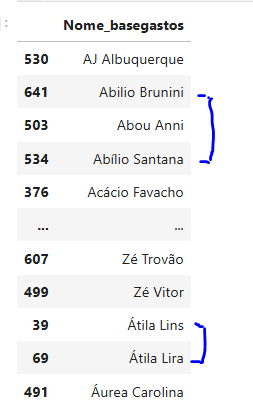

In [ ]:
# Criando o DataFrame sem duplicatas com o trio 
df_trio= df[['nuLegislatura', 'cpf', 'txNomeParlamentar', ]].drop_duplicates()

df_contagem = df_trio.groupby(['nuLegislatura', 'cpf']).size().reset_index(name='contagem')
df_contagem.head()

In [ ]:
df_contagem[df_contagem['contagem'] > 1]

In [ ]:
# PArecem nao existir duplicatas, ou seja, essa hipotese de inconsistencia nos dados, de 1 cpf conter mais de um registro de nome, nao existe.
# Teoricamente temos pares 'txNomeParlamentar' -  'cpf' únicos


In [101]:
#Vamos selecionar agora os deputados com nuLegislatura	=2023 e sem os nomes dos aglomerados

df_legisl_2023= df[df['nuLegislatura'] == 2023]
#df[df['nuLegislatura'] == 2023]['txNomeParlamentar'].unique()

df_legisl_2023_deput= df_legisl_2023[~df_legisl_2023['txNomeParlamentar'].isin(aglomerado)]

df_legisl_2023_deput['txNomeParlamentar'].unique()


array(['Danilo Forte', 'Julio Arcoverde', 'Fausto Pinato', 'Bacelar',
       'Felipe Carreras', 'Arlindo Chinaglia', 'Celso Russomanno',
       'Pompeo de Mattos', 'Ivan Valente', 'Alberto Fraga', 'Rui Falcão',
       'Osmar Terra', 'Benedita da Silva', 'Dilceu Sperafico',
       'Luiz Carlos Hauly', 'Ricardo Barros', 'Renildo Calheiros',
       'Roseana Sarney', 'Sérgio Brito', 'Perpétua Almeida', 'Luiz Couto',
       'Wellington Roberto', 'Wilson Santiago', 'Alice Portugal',
       'Daniel Almeida', 'Elcione Barbalho', 'José Priante',
       'Raimundo Santos', 'Átila Lins', 'Josias Gomes',
       'Leonardo Monteiro', 'Mário Heringer', 'Odair Cunha',
       'Patrus Ananias', 'Reginaldo Lopes', 'Chico Alencar',
       'Julio Lopes', 'Carlos Sampaio', 'Gilberto Nascimento',
       'Jefferson Campos', 'Vicentinho', 'Leônidas Cristino',
       'Júlio Cesar', 'Silas Câmara', 'Rubens Otoni', 'Geraldo Resende',
       'Vander Loubet', 'Giacobo', 'Maria do Rosário', 'Mendonça Filho',
       '

In [102]:
df_listadeputado_unic = pd.DataFrame(df_legisl_2023_deput['txNomeParlamentar'].unique(),
                                     columns=['Nome'])
#np.savetxt('deputados_base_gastos.csv', df_legisl_2023_deput['txNomeParlamentar'].unique(), delimiter=';')


In [103]:
df_legisl_2023_deput['txNomeParlamentar'].unique().size


617

In [104]:
df_legisl_2023 = df[df['nuLegislatura'] == 2023]

# Filtra os deputados excluindo os nomes presentes em 'aglomerado'
df_legisl_2023_deput = df_legisl_2023[~df_legisl_2023['txNomeParlamentar'].isin(aglomerado)]

# Cria um DataFrame temporário com 'sgUF' e 'txNomeParlamentar'
# Remove duplicatas baseadas no nome do parlamentar, mantendo a primeira ocorrência
# Isso garante que cada nome de deputado tenha uma UF associada
df_temp = df_legisl_2023_deput[['sgUF', 'txNomeParlamentar','sgPartido']].drop_duplicates(subset=['txNomeParlamentar'])

# Renomeia a coluna 'txNomeParlamentar' para 'Nome' para o DataFrame final
df_listadeputado_unic = df_temp.rename(columns={'txNomeParlamentar': 'Nome'})

# Reorganiza as colunas para que 'sgUF' seja a primeira
df_listadeputado_unic = df_listadeputado_unic[['sgUF', 'Nome', 'sgPartido']]

# Opcional: Para verificar os nomes únicos (já feito implicitamente pela remoção de duplicatas)
# print(df_listadeputado_unic['Nome'].unique())

print(df_listadeputado_unic.head())

     sgUF             Nome sgPartido
907    CE     Danilo Forte     UNIÃO
1437   PI  Julio Arcoverde        PP
1838   SP    Fausto Pinato        PP
2210   BA          Bacelar        PV
2495   PE  Felipe Carreras       PSB


### 1.4.3 - verificaçao de consistencia de numero de deputados

In [66]:
import locale

# Configurando locale para português do Brasil
locale.setlocale(locale.LC_ALL, 'pt_BR.UTF-8')

'pt_BR.UTF-8'

In [67]:
# Filtrando deputados com registros em 202301
deputados_202301 = df[df['numAnoMes_compet'] == 202301]['txNomeParlamentar'].unique()
# Filtrando deputados com registros a partir de 202306  (para passar pelo menos 90 dias 
deputados_apos_202306 = df[df['numAnoMes_compet'] >= 202306]['txNomeParlamentar'].unique()

In [79]:
# Encontrando os deputados que aparecem nas duas listas
deputados_filtrados =sorted( list(set(deputados_202301) & set(deputados_apos_202306)) )
deputados_filtrados =sorted( deputados_filtrados, key=locale.strxfrm)

deputados_filtrados = [deputado for deputado in deputados_filtrados if deputado not in aglomerado]
for item in sorted(deputados_filtrados):
    print(item)

AJ Albuquerque
Acácio Favacho
Adolfo Viana
Adriana Ventura
Adriano do Baldy
Afonso Florence
Afonso Hamm
Afonso Motta
Aguinaldo Ribeiro
Airton Faleiro
Alceu Moreira
Alencar Santana
Alex Manente
Alex Santana
Alexandre Leite
Alfredinho
Alice Portugal
Aliel Machado
Aline Gurgel
Altineu Côrtes
Aluisio Mendes
Amaro Neto
André Ferreira
André Figueiredo
André Fufuca
André Janones
Antonio Brito
Arlindo Chinaglia
Arnaldo Jardim
Arthur Lira
Arthur Oliveira Maia
Augusto Coutinho
Augusto Puppio
Aureo Ribeiro
Aécio Neves
Bacelar
Baleia Rossi
Benedita da Silva
Benes Leocádio
Beto Pereira
Bia Kicis
Bibo Nunes
Bohn Gass
Bosco Costa
Capitão Alberto Neto
Capitão Augusto
Carla Zambelli
Carlos Chiodini
Carlos Gomes
Carlos Henrique Gaguim
Carlos Jordy
Carlos Sampaio
Carlos Veras
Carlos Zarattini
Carmen Zanotto
Caroline de Toni
Celso Russomanno
Celso Sabino
Cezinha de Madureira
Charles Fernandes
Chiquinho Brazão
Chris Tonietto
Christiane de Souza Yared
Claudio Cajado
Cleber Verde
Coronel Armando
Coronel Chri

In [80]:
len(deputados_filtrados)

331

In [299]:
#Temos 331 nomes de deputados que gastaram tanto em jan/23 quanto após junho/23, mas temos do site oficila da câmara, que 294 deputados foram reeleitos.
#Site ref.: https://www.camara.leg.br/noticias/912220-reeleicao-na-camara-alcanca-57-veja-quais-deputados-foram-reeleitos/

In [82]:
df_avaliacao_registros = df[['nuLegislatura','txNomeParlamentar','nuDeputadoId', 'cpf','numAnoMes_compet']].drop_duplicates().\
sort_values(by=['nuLegislatura','txNomeParlamentar','nuDeputadoId', 'cpf','numAnoMes_compet'])



df_avaliacao_registros[df_avaliacao_registros['nuLegislatura']==2019]

,nuLegislatura,txNomeParlamentar,nuDeputadoId,cpf,numAnoMes_compet
144548,2019,AJ Albuquerque,3216,9.750606e+10,202301
139010,2019,Abou Anni,3413,8.496583e+09,202301
145134,2019,Abílio Santana,3282,3.660761e+10,202301
107998,2019,Acácio Favacho,3308,7.428703e+10,202301
146040,2019,Adolfo Viana,3326,8.012385e+10,202301
...,...,...,...,...,...
66041,2019,Zé Silva,2231,4.342278e+10,202301
137618,2019,Zé Vitor,3279,7.284045e+09,202301
10889,2019,Átila Lins,583,6.945842e+08,202301
21230,2019,Átila Lira,74,1.302359e+10,202301


In [87]:
df_avaliacao_registros[df_avaliacao_registros['nuLegislatura']==2019]['numAnoMes_compet'].unique()

array([202301])

In [88]:
#Para deputados com legsliatura em #todos os candidatos da legislatura anterior tiveram gastos apemnas no anomes de jan/2023, 
# entao parece não haver anomlaias quanto aos

In [89]:
df_avaliacao_registros[df_avaliacao_registros['nuLegislatura']==2023]['nuDeputadoId'].drop_duplicates().count()

629

In [91]:
df_avaliacao_registros[df_avaliacao_registros['nuLegislatura']==2023]['cpf'].drop_duplicates().count()

606

In [305]:
#Para a legislatura de 2023, Foram registrados 629 ids 

In [93]:
# Ainda mteos muito mais deputados na legislatura #vamos usar a base oficial histórica de deputados, disponivel abertamebente no site oficial da câmara de deputados
# https://dadosabertos.camara.leg.br/swagger/api.html?tab=staticfile

df_deputados_oficial = pd.read_csv(r"deputados.csv", sep=';',low_memory=False)
df_deputados_oficial.head()

,uri,nome,idLegislaturaInicial,idLegislaturaFinal,nomeCivil,cpf,siglaSexo,urlRedeSocial,urlWebsite,dataNascimento,dataFalecimento,ufNascimento,municipioNascimento
0,https://dadosabertos.camara.leg.br/api/v2/depu...,Abilio Brunini,57,57,ABILIO JACQUES BRUNINI MOUMER,NaN,M,NaN,NaN,1984-01-31,NaN,MT,Cuiabá
1,https://dadosabertos.camara.leg.br/api/v2/depu...,Acácio Favacho,56,57,ACÁCIO DA SILVA FAVACHO NETO,NaN,M,"https://twitter.com/acaciofavacho, https://www...",NaN,1983-09-28,NaN,AP,Macapá
2,https://dadosabertos.camara.leg.br/api/v2/depu...,Adail Filho,57,57,ADAIL JOSÉ FIGUEIREDO PINHEIRO,NaN,M,"https://www.instagram.com/adailfilho/, https:/...",NaN,1992-02-16,NaN,AM,Manaus
3,https://dadosabertos.camara.leg.br/api/v2/depu...,Adilson Barroso,57,57,ADILSON BARROSO OLIVEIRA,NaN,M,NaN,NaN,1964-06-14,NaN,MG,Minas Novas
4,https://dadosabertos.camara.leg.br/api/v2/depu...,Adolfo Viana,56,57,ADOLFO VIANA DE CASTRO NETO,NaN,M,NaN,NaN,1981-02-02,NaN,BA,Salvador


In [95]:
df_deputados_oficial[df_deputados_oficial['idLegislaturaFinal']==57].drop_duplicates().count()

uri                     610
nome                    610
idLegislaturaInicial    610
idLegislaturaFinal      610
nomeCivil               610
cpf                       0
siglaSexo               610
urlRedeSocial           354
urlWebsite               20
dataNascimento          610
dataFalecimento           1
ufNascimento            609
municipioNascimento     610
dtype: int64

In [ ]:
# apesar de termos 513 deputados oficialmente eleitos, apósminicio de mandato podem temporariamente assumir deputados suplentes. 
#Pode ainda ter ocorrido desistências (assume alguma rpefeitura, como na eleiçao de 2024, assumindo em 2025,

<div style="background-color:lightblue; padding: 20px;">
  <span style="font-size:14px; font-weight:bold;">1.5 Criaçao de novas colunas: INCLUSAO DO FLAG DE REELEICAO  </span>
</div>


In [ ]:
"""
Parte 1: pegar a base de deputados reeleitos
Disponível em 
<https://www.camara.leg.br/noticias/912220-reeleicao-na-camara-alcanca-57-veja-quais-deputados-foram-reeleitos/>
"""

In [96]:

df_deputados_reeleitos = pd.read_csv(r"C:\Users\Dalciana\Python_DBW_files\2000-mba dsa TCC-Dalciana\deputados_reeleitos.csv", sep=',',low_memory=False)
df_deputados_reeleitos.head()


,UF,Nome,Partido
0,AC,ANTÔNIA LUCIA,REPUBLICANOS
1,AL,ARTHUR LIRA,PP
2,AL,ISNALDO BULHÕES JR,MDB
3,AL,MARX BELTRÃO,PP
4,AL,PAULÃO,PT


In [97]:
df_deputados_reeleitos.shape

(294, 3)

3temos 294 deputados registrados como eleitos 

In [ ]:
"""
Pegar o dataframe df_deputados_reeleitos e criar uma coluna nova "Nome_dep_reeleito_simplificado"
em que : 
- transformamos a coluna "Nome"colocando todas as letras em minúsculo
- depois substituiremos todas as vogais com acentuaçao, da lingua portuguesa, pellas vogais sem acentuação, ex.:  á ou ã ou â é substituído por a; ó ou ó ou õ é subsituído por o,  é ou ê substituir por e etc.  

"""

In [98]:
import unicodedata

def simplificar_nome(nome):
    if pd.isna(nome): # Lidar com valores NaN (Not a Number)
        return nome
    nome = str(nome) # Garantir que é uma string
    # 1. Converter para minúsculas
    nome_minusculo = nome.lower()
    # 2. Remover acentos usando unicodedata
    nfkd_form = unicodedata.normalize('NFKD', nome_minusculo)
    only_ascii = "".join([char for char in nfkd_form if not unicodedata.combining(char)])

    # 3. Substituir "jr." por "jr"
    nome_minusculo = only_ascii.replace("jr.", "jr")
    
    return nome_minusculo

# Aplicar a função para criar a nova coluna
df_deputados_reeleitos['Nome_dep_reeleito_simplificado'] = df_deputados_reeleitos['Nome'].apply(simplificar_nome)
df_deputados_reeleitos.head(20)

,UF,Nome,Partido,Nome_dep_reeleito_simplificado
0,AC,ANTÔNIA LUCIA,REPUBLICANOS,antonia lucia
1,AL,ARTHUR LIRA,PP,arthur lira
2,AL,ISNALDO BULHÕES JR,MDB,isnaldo bulhoes jr
3,AL,MARX BELTRÃO,PP,marx beltrao
4,AL,PAULÃO,PT,paulao
5,AM,ATILA LINS,PSD,atila lins
6,AM,CAPITÃO ALBERTO NETO,PL,capitao alberto neto
7,AM,SIDNEY LEITE,PSD,sidney leite
8,AM,SILAS CÂMARA,REPUBLICANOS,silas camara
9,AP,ACÁCIO FAVACHO,MDB,acacio favacho


In [ ]:
"""
PARTE 2 - PEGAR A BASE DE NOMES UNICOS d de deputados encontrados na base de gastos e aplicar transformaçao para simplificar os nomes
"""

In [105]:
df_listadeputado_unic['Nome_dep_simplificado'] = df_listadeputado_unic['Nome'].apply(simplificar_nome)
df_listadeputado_unic.head(20)

,sgUF,Nome,sgPartido,Nome_dep_simplificado
907,CE,Danilo Forte,UNIÃO,danilo forte
1437,PI,Julio Arcoverde,PP,julio arcoverde
1838,SP,Fausto Pinato,PP,fausto pinato
2210,BA,Bacelar,PV,bacelar
2495,PE,Felipe Carreras,PSB,felipe carreras
2904,SP,Arlindo Chinaglia,PT,arlindo chinaglia
3213,SP,Celso Russomanno,REPUBLICANOS,celso russomanno
3980,RS,Pompeo de Mattos,PDT,pompeo de mattos
4712,SP,Ivan Valente,PSOL,ivan valente
5061,DF,Alberto Fraga,PL,alberto fraga


In [106]:
"""
Vamos fazer uma comparaçao de colunas para ver quais dos deputados das bases foram releitos ou nao

"""

'\nVamos fazer uma comparaçao de colunas para ver quais dos deputados das bases foram releitos ou nao\n\n'

In [107]:
df_listadeputado_unic_1 = df_listadeputado_unic.copy()

In [108]:
from fuzzywuzzy import process
import unicodedata
# --- Processamento ---

# Convertendo a coluna de reeleitos para um conjunto/lista para busca eficiente
# É importante ter os nomes de reeleitos em um formato que o fuzzywuzzy possa iterar
nomes_reeleitos_set = df_deputados_reeleitos['Nome_dep_reeleito_simplificado'].tolist()

# Criar a coluna 'flag_reeleito'
df_listadeputado_unic_1['flag_reeleito'] = 'Não' # Inicializa todos como 'Não'

# Definir um limite de similaridade (ex: 90 para alta similaridade)
# Este valor pode ser ajustado dependendo da precisão que você precisa
SIMILARITY_THRESHOLD = 90

# Iterar sobre cada nome no df_listadeputado_unic e verificar similaridade
for index, row in df_listadeputado_unic.iterrows():
    nome_para_comparar = row['Nome_dep_simplificado']

    # Usa process.extractOne para encontrar a melhor correspondência e sua pontuação
    # Retorna (melhor_match, score, indice_no_conjunto_de_busca)
    best_match = process.extractOne(nome_para_comparar, nomes_reeleitos_set)

    if best_match and best_match[1] >= SIMILARITY_THRESHOLD:
        df_listadeputado_unic_1.loc[index, 'flag_reeleito'] = 'Sim'


In [ ]:
 df_listadeputado_unic_1.head(10)

In [ ]:
df_listadeputado_unic_1['flag_reeleito'].value_counts()

In [ ]:
#Visto que so encontramos 288 nomes a prior indentifcados como reeleitos, menos que os 294 oficiais, entao vamos adaptar o algoritmo de busca por similaridade

In [ ]:
#df_listadeputado_unic_1.to_csv('df_listadeputado_unic.csv', sep=';', index=False)

In [109]:
"""
Parte 2.2 )   CODIGO 2 
Visto que o codigo 1 só identificou 288 dos 294 deputados reeleitos, vamos tentar outra abordagem de copdigo

Usando IA para gerar codigo


Prompt:
 Escrever codigo para 

1) criar uma coluna string "flag_reeleito" no dataframe df_listadeputado_unic


Essa coluna "flag_reeleito" recebe o valor "Sim" se os elementos de df_listadeputado_unic['Nome_dep_simplificado']

estao contidos no conjunto da coluna df_deputados_reeleitos['Nome_dep_reeleito_simplificado'].


Fazer essa comparaçao de df_listadeputado_unic['Nome_dep_simplificado'] e df_deputados_reeleitos['Nome_dep_reeleito_simplificado'] por similaridade semantica. 
Considerar que muitas pessoas tem 2 sobrenomes, mas pode ser que apenas 1 deles tenha sido mencionado tanto na df_listadeputado_unic['Nome_dep_simplificado'] ou na df_deputados_reeleitos['Nome_dep_reeleito_simplificado'] . Quando a pessoa tiver 2 sobrenomes, pode omitir o do meio para fins de comparaçao de similaridade (Ex.: "joao da silva domes, pode ser considerado como  "joao gomes")
Também desocnsiderar termos como ("da", "de", "e").
Alguns títulos como doutor podem estar abreviados como "dr." ou "dr", pastor, como "pr". ou "pr", padre como "pe." ou "pe.", professor como "prof."ou "prof" ou vice versa. Considerar que essas trocas nao afetam a similaridade.

2)   incluir uma nova coluna em df_listadeputado_unic que é a coluna df_deputados_reeleitos['Nome_dep_reeleito_simplificado'] com a qual comparou anteriorimente

"""


'\nParte 2.2 )   CODIGO 2 \nVisto que o codigo 1 só identificou 288 dos 294 deputados reeleitos, vamos tentar outra abordagem de copdigo\n\nUsando IA para gerar codigo\n\n\nPrompt:\n\xa0Escrever codigo para\xa0\n\n1) criar uma coluna string "flag_reeleito" no dataframe df_listadeputado_unic\n\n\nEssa coluna "flag_reeleito" recebe o valor "Sim" se os elementos de df_listadeputado_unic[\'Nome_dep_simplificado\']\n\nestao contidos no conjunto da coluna df_deputados_reeleitos[\'Nome_dep_reeleito_simplificado\'].\n\n\nFazer essa comparaçao de df_listadeputado_unic[\'Nome_dep_simplificado\'] e df_deputados_reeleitos[\'Nome_dep_reeleito_simplificado\'] por similaridade semantica.\xa0\nConsiderar que muitas pessoas tem 2 sobrenomes, mas pode ser que apenas 1 deles tenha sido mencionado tanto na df_listadeputado_unic[\'Nome_dep_simplificado\'] ou na df_deputados_reeleitos[\'Nome_dep_reeleito_simplificado\'] . Quando a pessoa tiver 2 sobrenomes, pode omitir o do meio para fins de comparaçao de s

In [110]:

import pandas as pd
from fuzzywuzzy import fuzz
from fuzzywuzzy import process
import re

df_listadeputado_unic_2 = df_listadeputado_unic.copy()

def preprocess_name(name):
    """
    Normaliza o nome para comparação, removendo termos irrelevantes, abreviações de títulos
    e simplificando sobrenomes compostos.
    """
    if pd.isna(name):
        return ""
    name = str(name).lower()

    # Remover termos como "da", "de", "e"
    name = re.sub(r'\b(da|de|do|das|dos|e)\b', '', name)

    # Lidar com abreviações de títulos
    name = re.sub(r'\b(dr|dra|pr|pa|prof|pe)\.?\b', '', name)

    # Remover múltiplos espaços e espaços nas extremidades
    name = re.sub(r'\s+', ' ', name).strip()

    # Simplificar nomes com múltiplos sobrenomes (ex: "joao da silva gomes" para "joao gomes")
    parts = name.split()
    if len(parts) > 2:
        # Tenta pegar o primeiro nome e o último sobrenome
        # Isso é uma heurística e pode não ser perfeito para todos os casos
        name = f"{parts[0]} {parts[-1]}"
    return name

def find_best_match(name, reelected_names_set, threshold=80):
    """
    Encontra o melhor casamento para um nome na lista de reeleitos usando similaridade semântica.
    Retorna o nome reeleito correspondente se a similaridade for maior que o threshold, senão None.
    """
    processed_name = preprocess_name(name)
    if not processed_name:
        return None, 0

    best_match = None
    best_score = 0

    # Usar process.extractOne para encontrar o melhor casamento com fuzzywuzzy
    # Ele compara a string com todas as strings na lista e retorna a melhor.
    if reelected_names_set: # Garante que o conjunto não está vazio
        match = process.extractOne(processed_name, list(reelected_names_set), scorer=fuzz.token_set_ratio)
        if match and match[1] >= threshold:
            best_match = match[0] # Retorna o nome original do reeleito que deu match
            best_score = match[1]
    return best_match, best_score


In [111]:
# --- INÍCIO DO CÓDIGO PARA CRIAR AS COLUNAS ---

# 1. Pré-processar os nomes dos deputados reeleitos para facilitar a comparação
# Criamos um set dos nomes pré-processados para busca rápida
# Mapeamos o nome pré-processado de volta para o nome original
processed_reelected_names_map = {}

for name in df_deputados_reeleitos['Nome_dep_reeleito_simplificado'].unique():
    processed_name = preprocess_name(name)
    if processed_name: # Garante que o nome pré-processado não é vazio
        # Se houver duplicidade de nomes pré-processados, o último será mantido.
        # Isso é uma consideração importante se os nomes originais podem ser diferentes
        # mas resultam no mesmo nome pré-processado.
        processed_reelected_names_map[processed_name] = name

reelected_names_set = set(processed_reelected_names_map.keys())


# 2. Criar as novas colunas no df_listadeputado_unic
df_listadeputado_unic_2['flag_reeleito'] = 'Nao' # Valor padrão
df_listadeputado_unic_2['Nome_dep_reeleito_comparado'] = None # Coluna para o nome que deu match

for index, row in df_listadeputado_unic_2.iterrows():
    dep_name = row['Nome_dep_simplificado']
    best_match_processed, score = find_best_match(dep_name, reelected_names_set, threshold=85) # Aumentar o threshold pode tornar a comparação mais rigorosa

    if best_match_processed:
        df_listadeputado_unic_2.at[index, 'flag_reeleito'] = 'Sim'
        # Usar o mapeamento para obter o nome original reeleito
        df_listadeputado_unic_2.at[index, 'Nome_dep_reeleito_comparado'] = processed_reelected_names_map[best_match_processed]

print("DataFrame df_listadeputado_unic_2 atualizado:")

DataFrame df_listadeputado_unic_2 atualizado:


In [112]:
df_listadeputado_unic_2.head()

,sgUF,Nome,sgPartido,Nome_dep_simplificado,flag_reeleito,Nome_dep_reeleito_comparado
907,CE,Danilo Forte,UNIÃO,danilo forte,Sim,danilo forte
1437,PI,Julio Arcoverde,PP,julio arcoverde,Nao,None
1838,SP,Fausto Pinato,PP,fausto pinato,Sim,fausto pinato
2210,BA,Bacelar,PV,bacelar,Sim,joao carlos bacelar
2495,PE,Felipe Carreras,PSB,felipe carreras,Sim,felipe carreras


In [113]:
df_listadeputado_unic_2 = df_listadeputado_unic_2.sort_values(by='Nome')
df_listadeputado_unic_2.to_csv('df_listadeputado_unic_2.csv', sep=';', index=False)

In [114]:
df_listadeputado_unic_2['flag_reeleito'].value_counts()

flag_reeleito
Nao    319
Sim    298
Name: count, dtype: int64

In [ ]:
#Nesse caso encontramos 298 nomes releitos em vez dos 294 previstos. 
#PRecisamos de mais uma etapa de verificaçao, na Parte 3



In [ ]:
"""
Parte 3  - verificaçao dos campos [flags_reeleito] entre a base df_listadeputado_unic_1 e df_listadeputado_unic_2
Se fosse diferentes entre si , eram checados no dataframe oficial 
Nessa etapa de verificaçao, feita em software de planilha eletronica
""" 

In [115]:
df_listadeputado_unic_flag_reeleitos_verificada = pd.read_csv(r"df_listadeputado_unic_flag_reeleitos_verificada.csv", sep=';',low_memory=False)
df_listadeputado_unic_flag_reeleitos_verificada.head(10)

,sgUF,Nome,sgPartido,Nome_dep_simplificado,flag_reeleito_final
0,MT,Abilio Brunini,PL,abilio brunini,Nao
1,AP,Acácio Favacho,MDB,acacio favacho,Sim
2,AM,Adail Filho,REPUBLICANOS,adail filho,Nao
3,SP,Adilson Barroso,PL,adilson barroso,Nao
4,BA,Adolfo Viana,PSDB,adolfo viana,Sim
5,SP,Adriana Ventura,NOVO,adriana ventura,Sim
6,GO,Adriano do Baldy,PP,adriano do baldy,Sim
7,MG,Aécio Neves,PSDB,aecio neves,Sim
8,BA,Afonso Florence,PT,afonso florence,Sim
9,RS,Afonso Hamm,PP,afonso hamm,Sim


In [ ]:
"""
amos incluir a nova coluna flag_reeleito no seu DataFrame df
baseando-se nos nomes dos parlamentares presentes em df_listadeputado_unic_flag_reeleitos_verificada
""" 

In [116]:
mapeamento_reeleicao = df_listadeputado_unic_flag_reeleitos_verificada.set_index('Nome')['flag_reeleito_final']

mapeamento_reeleicao

Nome
Abilio Brunini     Nao
Acácio Favacho     Sim
Adail Filho        Nao
Adilson Barroso    Nao
Adolfo Viana       Sim
                  ... 
Zé Trovão          Nao
Zé Vitor           Sim
Zeca Dirceu        Sim
Zezinho Barbary    Nao
Zucco              Nao
Name: flag_reeleito_final, Length: 617, dtype: object

In [117]:
# Use o método .map() para criar a nova coluna no DataFrame df
# Se um nome em df['txNomeParlamentar'] não for encontrado no dicionário,
# o valor correspondente em 'flag_reeleito' será NaN (Not a Number).

df['flag_reeleito'] = df['txNomeParlamentar'].map(mapeamento_reeleicao)

# no caso dos nomes dos aglomerados ( Ex,
df['flag_reeleito'] = df['flag_reeleito'].fillna("Nao aplicavel")

In [118]:
df.head()

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,nuDeputadoId,ideDocumento,urlDocumento,datEmissao_AAAAMM,numAnoMes_compet,TipoDocumento,desc_Subcota_Espec,macro_categoria,flag_lid,flag_reeleito
0,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,2812,7503781,https://www.camara.leg.br/cota-parlamentar/doc...,202302,202302,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,1,Nao aplicavel
1,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,2812,7570656,https://www.camara.leg.br/cota-parlamentar/doc...,202306,202306,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,1,Nao aplicavel
2,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,2812,7580960,https://www.camara.leg.br/cota-parlamentar/doc...,202307,202307,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,1,Nao aplicavel
3,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,2812,7599444,https://www.camara.leg.br/cota-parlamentar/doc...,202308,202308,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,1,Nao aplicavel
4,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,2812,7620412,https://www.camara.leg.br/cota-parlamentar/doc...,202309,202309,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,1,Nao aplicavel


In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 539729 entries, 0 to 539728
Data columns (total 39 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   txNomeParlamentar          539729 non-null  object        
 1   cpf                        537574 non-null  float64       
 2   ideCadastro                537623 non-null  float64       
 3   nuCarteiraParlamentar      537623 non-null  float64       
 4   nuLegislatura              539729 non-null  int64         
 5   sgUF                       537623 non-null  object        
 6   sgPartido                  537623 non-null  object        
 7   codLegislatura             539729 non-null  int64         
 8   numSubCota                 539729 non-null  int64         
 9   txtDescricao               539729 non-null  object        
 10  numEspecificacaoSubCota    539729 non-null  int64         
 11  txtDescricaoEspecificacao  169267 non-null  object  


 <div style="background-color:lightcoral; padding: 20px;">
  <span style="font-size:20px; font-weight:bold;">2. Análise exploratória dos dados</span>
</div>

In [ ]:
df.info()

In [ ]:
df.columns

In [ ]:
df['txNomeParlamentar'].head()

In [122]:
#Selecionando apenas os dados entre fev/23 e abril de 25
df=df[df['numAnoMes_compet']<=202504]
df=df[df['numAnoMes_compet']>=202302]

In [123]:
df.describe()

,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,codLegislatura,numSubCota,numEspecificacaoSubCota,indTipoDocumento,datEmissao,vlrDocumento,...,numAno,numParcela,numLote,numRessarcimento,vlrRestituicao,nuDeputadoId,ideDocumento,datEmissao_AAAAMM,numAnoMes_compet,flag_lid
count,5.133150e+05,513346.000000,513346.000000,515395.0,515395.0,515395.000000,515395.000000,515395.000000,499777,515395.000000,...,515395.000000,515395.000000,5.153950e+05,146056.0,147.000000,515395.000000,5.153950e+05,499777.0,515395.000000,515395.000000
mean,3.188496e+10,180540.776562,303.135581,2023.0,57.0,264.339968,0.317382,1.276970,2024-03-10 01:47:49.717558272,1094.030033,...,2023.703459,0.000415,1.449463e+06,0.0,2283.694490,3018.123725,5.587080e+06,202377.137775,202376.639327,0.003976
min,1.608657e+06,62881.000000,1.000000,2023.0,57.0,1.000000,0.000000,0.000000,2002-06-25 00:00:00,-6683.440000,...,2023.000000,0.000000,0.000000e+00,0.0,1.470000,161.000000,0.000000e+00,200206.0,202302.000000,0.000000
25%,5.967751e+09,160556.000000,173.000000,2023.0,57.0,3.000000,0.000000,0.000000,2023-08-25 00:00:00,95.420000,...,2023.000000,0.000000,0.000000e+00,0.0,94.995000,2439.000000,3.012885e+05,202308.0,202308.000000,0.000000
50%,2.227515e+10,204426.000000,302.000000,2023.0,57.0,10.000000,0.000000,0.000000,2024-03-10 12:00:00,247.870000,...,2024.000000,0.000000,1.977842e+06,0.0,1366.370000,3331.000000,7.624820e+06,202403.0,202403.000000,0.000000
75%,5.143425e+10,220583.000000,451.000000,2023.0,57.0,122.000000,1.000000,4.000000,2024-09-17 00:00:00,1051.910000,...,2024.000000,0.000000,2.057506e+06,0.0,3076.040000,3597.000000,7.769808e+06,202409.0,202409.000000,0.000000
max,9.989866e+10,231911.000000,615.000000,2023.0,57.0,999.000000,4.000000,4.000000,2025-06-02 00:00:00,209948.000000,...,2025.000000,1.000000,2.140687e+06,0.0,30000.000000,3792.000000,7.924668e+06,202506.0,202504.000000,1.000000
std,2.914499e+10,49013.469070,158.525817,0.0,0.0,420.490465,0.483118,1.736934,NaN,3121.742781,...,0.681254,0.020373,9.131630e+05,0.0,3476.560784,791.725407,3.374342e+06,67.496171,66.927449,0.062927


In [124]:
colunas = ['txNomeParlamentar', 'sgUF', 'sgPartido','txtDescricao', 'vlrLiquido', 'numMes', 'numAno']

<div style="background-color:lightblue; padding: 20px;">
  <span style="font-size:14px; font-weight:bold;">2.1. Verificaçao:  nro de deputados eleitos e encontrados na base de gastos de cotas + Cota mensal    </span>
</div>

In [58]:
cota_parlamentar_uf = {
    "AC": 50426.26, "DF": 36582.46, "MT": 45221.83, "RJ": 41553.77, "SE": 45933.06,
    "AL": 46737.90, "ES": 43217.71, "PA": 48021.25, "RN": 48525.79, "SP": 42837.33,
    "AM": 49363.92, "GO": 41300.86, "PB": 47826.36, "RO": 49466.29, "TO": 45297.41,
    "AP": 49168.58, "MA": 47945.49, "PE": 47470.60, "RR": 51406.33,
    "BA": 44804.65, "MG": 41886.51, "PI": 46765.57, "RS": 46669.70,
    "CE": 48245.57, "MS": 46336.64, "PR": 44665.66, "SC": 45671.58
}

# Criando o DataFrame
df_cota_parlamentar_mensal_uf = pd.DataFrame(list(cota_parlamentar_uf.items()), columns=['UF', 'Cota_Mensal'])

df_cota_parlamentar_mensal_uf.sort_values(by=['Cota_Mensal'],ascending=False)

,UF,Cota_Mensal
18,RR,51406.33
0,AC,50426.26
13,RO,49466.29
10,AM,49363.92
15,AP,49168.58
8,RN,48525.79
23,CE,48245.57
7,PA,48021.25
16,MA,47945.49
12,PB,47826.36


Limites mensais inacumuláveis:
- "LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES" <= 12713.00  
- "SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO" <= 2700.00  
- "COMBUSTÍVEIS E LUBRIFICANTES."<=9392   
- "SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA"<=8.700.00   
- "PARTICIPAÇÃO EM CURSO, PALESTRA OU EVENTO SIMILAR' <=7697.17   
- complementação de auxílio-moradia<=  4.148,80    
Obs.: o complemento de auxilio moradia não aparece nas categorias de gastos aqui...       
Falta transparência quanto a esse gasto. N!AO PRECISA APRESENTAR COMPROVANTE ?


In [345]:
# Dados da cota parlamentar por estado
dados_cota = {
    "sgUF": ["AC", "DF", "MT", "RJ", "SE", "AL", "ES", "PA", "RN", "SP",
             "AM", "GO", "PB", "RO", "TO", "AP", "MA", "PE", "RR", "BA",
             "MG", "PI", "RS", "CE", "MS", "PR", "SC"],
    "Cota_Parlamentar_Mensal_BRL": [50426.26, 36582.46, 45221.83, 41553.77, 45933.06,
                             46737.90, 43217.71, 48021.25, 48525.79, 42837.33,
                             49363.92, 41300.86, 47826.36, 49466.29, 45297.41,
                             49168.58, 47945.49, 47470.60, 51406.33, 44804.65,
                             41886.51, 46765.57, 46669.70, 48245.57, 46336.64,
                             44665.66, 45671.58]
}

# Criando DataFrame com os valores da cota parlamentar
df_cotas = pd.DataFrame(dados_cota)

# Obtendo o número de deputados por estado
df_deputados = df.groupby("sgUF")["txNomeParlamentar"].nunique().reset_index()
df_deputados.rename(columns={"txNomeParlamentar": "Numero_Deputados"}, inplace=True)

# Mesclando os dois DataFrames
df_deputfinal = pd.merge(df_deputados, df_cotas, on="sgUF")

# Exibindo o DataFrame final
df_final.sort_values(by='Cota_Parlamentar_Mensal_BRL', ascending=False)

,sgUF,Numero_Deputados,Cota_Parlamentar_Mensal_BRL
21,RR,9,51406.33
0,AC,11,50426.26
20,RO,8,49466.29
2,AM,10,49363.92
3,AP,9,49168.58
19,RN,9,48525.79
5,CE,29,48245.57
13,PA,19,48021.25
9,MA,32,47945.49
14,PB,15,47826.36


In [346]:
df_final.sort_values(by='Numero_Deputados', ascending=False)

,sgUF,Numero_Deputados,Cota_Parlamentar_Mensal_BRL
25,SP,84,42837.33
10,MG,60,41886.51
18,RJ,57,41553.77
4,BA,42,44804.65
17,PR,40,44665.66
22,RS,34,46669.70
9,MA,32,47945.49
5,CE,29,48245.57
15,PE,27,47470.60
23,SC,21,45671.58


In [362]:
# avaliando a base de deputados efetivamente eleitos

#Disponivel em https://www.camara.leg.br/internet/agencia/infograficos-html5/tabelasEleicoes/deputados-eleitos-estado/index.html
df_deputados_eleitos = pd.read_csv("deputados_federais_eleitos_2023_a_2026.csv", sep=";",encoding="utf-8")
df_deputados_eleitos 

,UF,Nome,Partido
0,MT,ABÍLIO,PL
1,AP,ACÁCIO FAVACHO,MDB
2,AM,ADAIL FILHO,REPUBLICANOS
3,BA,ADOLFO VIANA,PSDB
4,SP,ADRIANA VENTURA,NOVO
...,...,...,...
508,MG,ZÉ SILVA,SOLIDARIEDADE
509,SC,ZÉ TROVÃO,PL
510,MG,ZÉ VITOR,PL
511,PR,ZECA DIRCEU,PT


In [377]:
df_deputados_eleitos_group =  df_deputados_eleitos["UF"].value_counts().reset_index()  
df_deputados_eleitos_group

,UF,count
0,SP,70
1,MG,53
2,RJ,46
3,BA,39
4,RS,31
5,PR,30
6,PE,25
7,CE,22
8,MA,18
9,PA,17


In [364]:
df_deputados_eleitos.value_counts().reset_index()  

,UF,Nome,Partido,count
0,AC,ANTÔNIA LUCIA,REPUBLICANOS,1
1,PE,GUILHERME UCHOA JUNIOR,PSB,1
2,RJ,SORAYA SANTOS,PL,1
3,RJ,SARGENTO PORTUGAL,PODE,1
4,RJ,ROSANGELA GOMES,REPUBLICANOS,1
...,...,...,...,...
508,MG,GILBERTO ABRAMO,REPUBLICANOS,1
509,MG,FRED COSTA,PATRIOTA,1
510,MG,EUCLYDES PETTERSEN,PSC,1
511,MG,EROS BIONDINI,PL,1


In [386]:


# Passo 1: Criar o primeiro DataFrame com o número de deputados por estado e a cota parlamentar disponível
dados_cota = {
    "sgUF": ["AC", "DF", "MT", "RJ", "SE", "AL", "ES", "PA", "RN", "SP",
             "AM", "GO", "PB", "RO", "TO", "AP", "MA", "PE", "RR", "BA",
             "MG", "PI", "RS", "CE", "MS", "PR", "SC"],
    "Cota_Parlamentar_R$": [50426.26, 36582.46, 45221.83, 41553.77, 45933.06,
                             46737.90, 43217.71, 48021.25, 48525.79, 42837.33,
                             49363.92, 41300.86, 47826.36, 49466.29, 45297.41,
                             49168.58, 47945.49, 47470.60, 51406.33, 44804.65,
                             41886.51, 46765.57, 46669.70, 48245.57, 46336.64,
                             44665.66, 45671.58]
}

df_cotas = pd.DataFrame(dados_cota)

# Obtendo o número de deputados por estado presentes nos gastos
df_deputados_gastos = df.groupby("sgUF")["txNomeParlamentar"].nunique().reset_index()
df_deputados_gastos.rename(columns={"txNomeParlamentar": "Numero_Deputados_Gastos"}, inplace=True)

# Mesclando com a cota parlamentar
df_cotas = pd.merge(df_cotas, df_deputados_gastos, on="sgUF")



In [374]:
# Passo 2: Criar o segundo DataFrame com os deputados eleitos por estado
df_deputados_eleitos_group = df_deputados_eleitos.groupby("UF")["Nome"].apply(list).reset_index()
df_deputados_eleitos_group.rename(columns={"Nome": "Deputados_Eleitos"}, inplace=True)

# Passo 3: Juntar os dois DataFrames pelo estado (UF)
df_final_ = pd.merge(df_cotas, df_deputados_eleitos_group, left_on="sgUF", right_on="UF")

# Exibindo o DataFrame final
print(df_final_)


   sgUF  Cota_Parlamentar_R$  Numero_Deputados_Gastos  UF  \
0    AC             50426.26                       11  AC   
1    DF             36582.46                        9  DF   
2    MT             45221.83                       13  MT   
3    RJ             41553.77                       57  RJ   
4    SE             45933.06                       12  SE   
5    AL             46737.90                        9  AL   
6    ES             43217.71                       10  ES   
7    PA             48021.25                       19  PA   
8    RN             48525.79                        9  RN   
9    SP             42837.33                       84  SP   
10   AM             49363.92                       10  AM   
11   GO             41300.86                       19  GO   
12   PB             47826.36                       15  PB   
13   RO             49466.29                        8  RO   
14   TO             45297.41                       11  TO   
15   AP             4916

In [387]:
df_count_uf_merge = pd.merge(df_cotas, df_deputados_eleitos_group, left_on="sgUF", right_on="UF")
df_count_uf_merge

,sgUF,Cota_Parlamentar_R$,Numero_Deputados_Gastos,UF,count
0,AC,50426.26,11,AC,8
1,DF,36582.46,9,DF,8
2,MT,45221.83,13,MT,8
3,RJ,41553.77,57,RJ,46
4,SE,45933.06,12,SE,8
5,AL,46737.90,9,AL,9
6,ES,43217.71,10,ES,10
7,PA,48021.25,19,PA,17
8,RN,48525.79,9,RN,8
9,SP,42837.33,84,SP,70


In [388]:
df_count_uf_merge= df_count_uf_merge.drop(columns=["UF"])

In [394]:

df_count_uf_merge=df_count_uf_merge.rename(columns={"count": "Numero deputados eleitos"}) 
df_count_uf_merge=df_count_uf_merge.rename(columns={"Cota_Parlamentar_R$": "Cota_Parlamentar_Mensal_BRL"}) 
df_count_uf_merge.sort_values(by='Cota_Parlamentar_Mensal_BRL', ascending=False)
#Calcular proporçao de deputados a mais presentes na base de gastos em relaçao aos efetivamente eleitos ( por subsituiçao, suplentes, desistêca ao longo do mandato etc, etc) 
df_count_uf_merge['Prop_diff_Deput']=(df_count_uf_merge['Numero_Deputados_Gastos'] / df_count_uf_merge['Numero deputados eleitos']) 
df_count_uf_merge['Pc_diff_Deput']=   (df_count_uf_merge['Prop_diff_Deput']-1 ) *100


In [396]:
# Ordenando pelos  estados com maior valor de cota parlamentar mensal

df_count_uf_merge.sort_values(by='Cota_Parlamentar_Mensal_BRL', ascending=False)

,sgUF,Cota_Parlamentar_Mensal_BRL,Numero_Deputados_Gastos,Numero deputados eleitos,Pc_Deput,Prop_diff_Deput,Pc_diff_Deput
18,RR,51406.33,9,8,1.125000,1.125000,12.500000
0,AC,50426.26,11,8,1.375000,1.375000,37.500000
13,RO,49466.29,8,8,1.000000,1.000000,0.000000
10,AM,49363.92,10,8,1.250000,1.250000,25.000000
15,AP,49168.58,9,8,1.125000,1.125000,12.500000
8,RN,48525.79,9,8,1.125000,1.125000,12.500000
23,CE,48245.57,29,22,1.318182,1.318182,31.818182
7,PA,48021.25,19,17,1.117647,1.117647,11.764706
16,MA,47945.49,32,18,1.777778,1.777778,77.777778
12,PB,47826.36,15,12,1.250000,1.250000,25.000000


In [397]:
# Ordenando pelos  estados com maior porcentagem de variaçao de estados que tiveram mais deputados dentro do quadro de gastos x numero efetivamente eleito
# Motivos: suplentes por licença médica, desistência ao longo do mandato etc


df_count_uf_merge.sort_values(by='Pc_diff_Deput', ascending=False)

,sgUF,Cota_Parlamentar_Mensal_BRL,Numero_Deputados_Gastos,Numero deputados eleitos,Pc_Deput,Prop_diff_Deput,Pc_diff_Deput
16,MA,47945.49,32,18,1.777778,1.777778,77.777778
2,MT,45221.83,13,8,1.625000,1.625000,62.500000
4,SE,45933.06,12,8,1.500000,1.500000,50.000000
0,AC,50426.26,11,8,1.375000,1.375000,37.500000
14,TO,45297.41,11,8,1.375000,1.375000,37.500000
25,PR,44665.66,40,30,1.333333,1.333333,33.333333
23,CE,48245.57,29,22,1.318182,1.318182,31.818182
26,SC,45671.58,21,16,1.312500,1.312500,31.250000
10,AM,49363.92,10,8,1.250000,1.250000,25.000000
12,PB,47826.36,15,12,1.250000,1.250000,25.000000


## 2.1 Gastos dos deputados ao longo do tempo, desde o início do atual mandato, em fev/2023 até abril/2025

In [ ]:
df['numAnoMes_compet']. drop_duplicates().sort_values(ascending=True)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# Agrupando por 'numAnoMes_compet' e somando 'vlrLiquido'
df_agrupado = df.groupby('numAnoMes_compet')['vlrLiquido'].sum().reset_index()

# Convertendo 'numAnoMes_compet' para um formato de data válido (AAAAMM → AAAA-MM-01)
df_agrupado['Data'] = pd.to_datetime(df_agrupado['numAnoMes_compet'].astype(str) + '01', format='%Y%m%d')

# Ordenando pela nova coluna de data
df_agrupado = df_agrupado.sort_values(by='Data')

# Criando o gráfico de linha
plt.figure(figsize=(12, 6))
plt.plot(df_agrupado['Data'], df_agrupado['vlrLiquido'] / 1e6, marker='o', linestyle='-', color='b')

# Adicionando linhas verticais pontilhadas vermelhas nos meses de dezembro de 2023 e dezembro de 2024
plt.axvline(pd.to_datetime("2023-12-01"), color='red', linestyle='dashed', linewidth=2)
plt.axvline(pd.to_datetime("2024-12-01"), color='red', linestyle='dashed', linewidth=2)

# Adicionando um marcador para fevereiro de 2023 (início da 57ª Legislatura)
plt.scatter(pd.to_datetime("2023-02-01"), df_agrupado[df_agrupado['Data'] == pd.to_datetime("2023-02-01")]['vlrLiquido'] / 1e6,
            color='green', s=100)

plt.annotate("Início da 57ª Legislatura", xy=(pd.to_datetime("2023-02-01"), 
            df_agrupado[df_agrupado['Data'] == pd.to_datetime("2023-02-01")]['vlrLiquido'].values[0] / 1e6),
            xytext=(-30, 30), textcoords='offset points',
            arrowprops=dict(arrowstyle="->", color='green'), fontsize=12, color='green')

# Configurações do gráfico
plt.xlabel("")  # Omitindo o nome do eixo X
plt.ylabel("Gastos da cota (R$ milhões)")
plt.xticks(rotation=45)  # Mantendo os labels do eixo X inclinados para melhor leitura
plt.grid(True, linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

## 2.2 Gastos por UF

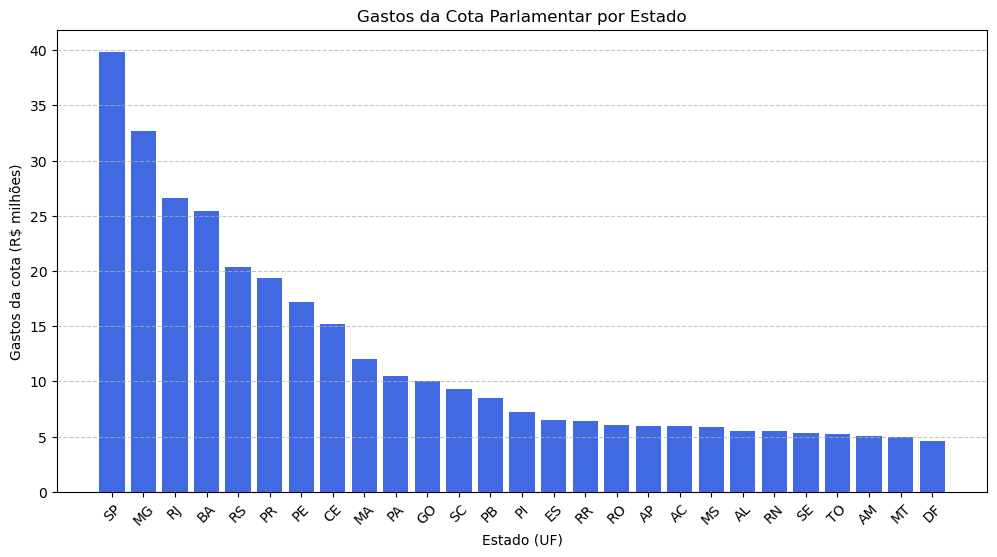

In [254]:
import pandas as pd
import matplotlib.pyplot as plt

# Agrupando os dados por estado (UF) e somando o valor líquido
df_agrupado = df.groupby('sgUF')['vlrLiquido'].sum().reset_index()

# Convertendo para milhões de reais
df_agrupado['vlrLiquido'] = df_agrupado['vlrLiquido'] / 1e6

# Ordenando do maior para o menor valor
df_agrupado = df_agrupado.sort_values(by='vlrLiquido', ascending=False)

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(df_agrupado['sgUF'], df_agrupado['vlrLiquido'], color='royalblue')

# Configurações do gráfico
plt.xlabel("Estado (UF)")
plt.ylabel("Gastos da cota (R$ milhões)")
plt.title("Gastos da Cota Parlamentar por Estado")
plt.xticks(rotation=45)  # Rotacionando os estados para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

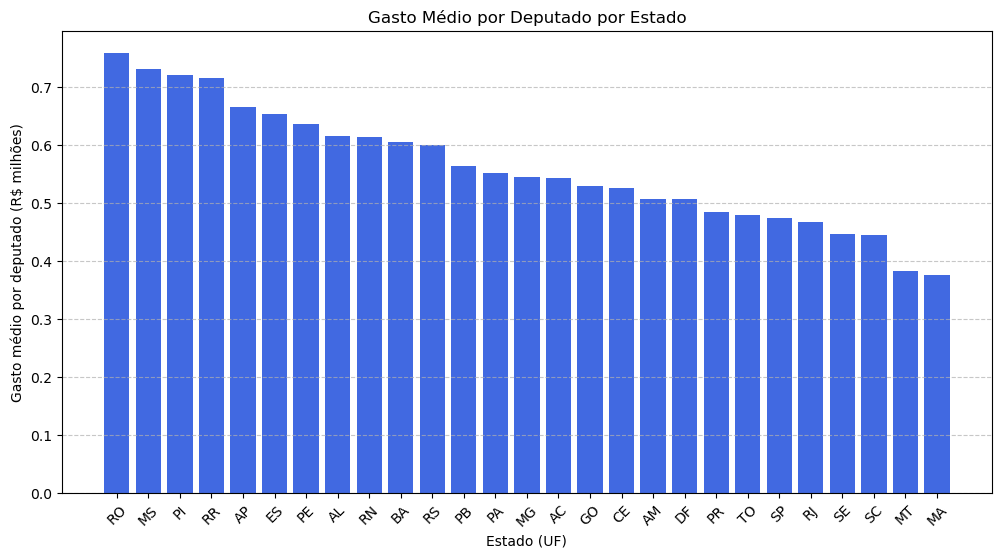

In [256]:
"""
GASTO MEDIO POR DEPUTADO - MÉDIA SIMPLES
"""
# Agrupando os dados para obter a soma dos gastos por estado (UF)
df_gastos = df.groupby('sgUF')['vlrLiquido'].sum().reset_index()

# Contando o número de deputados por estado
df_deputados = df.groupby('sgUF')['txNomeParlamentar'].nunique().reset_index()

# Juntando os dados de gastos e número de deputados
df_analise = pd.merge(df_gastos, df_deputados, on='sgUF')

# Calculando o gasto médio por deputado em cada estado
df_analise['Gasto_por_Deputado'] = df_analise['vlrLiquido'] / df_analise['txNomeParlamentar']

# Convertendo para milhões de reais
df_analise['Gasto_por_Deputado'] = df_analise['Gasto_por_Deputado'] / 1e6

# Ordenando do maior para o menor gasto médio
df_analise = df_analise.sort_values(by='Gasto_por_Deputado', ascending=False)

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(df_analise['sgUF'], df_analise['Gasto_por_Deputado'], color='royalblue')

# Configurações do gráfico
plt.xlabel("Estado (UF)")
plt.ylabel("Gasto médio por deputado (R$ milhões)")
plt.title("Gasto Médio por Deputado por Estado")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

In [398]:
"""
GASTO MEDIO POR DEPUTADO - MÉDIA PONDERADA PELO NRO DE MESES QUE DEPUTADO ESTEVE PRESENTE (JA QUE HÁ MUITOS SUPLENTES OU SUBSTITUTOS
"""

# PARTE 1


# 1) Selecionar apenas os itens em que flag_lid = 0
df_nao_lideres = df[df['flag_lid'] == 0].copy()

# 2) Agrupar os dados e calcular as colunas solicitadas
# O agrupamento é feito por Deputado, Partido e UF para obter os totais
df_final_agrup= df_nao_lideres.groupby(['sgUF', 'sgPartido', 'txNomeParlamentar']).agg(
    gasto_total_deputado=('vlrLiquido', 'sum'),
    nro_meses_gastos=('numAnoMes_compet', pd.Series.nunique),
    flag_lid=('flag_lid', 'first')
).reset_index()

# 3) Adicionar a nova coluna e ordenar o DataFrame
# Criar a coluna que é o produto de 'gasto_total_deputado' por 'nro_meses_gastos'
df_final_agrup['multiplicacao_gastos_meses'] = df_final_agrup['gasto_total_deputado'] * df_final_agrup['nro_meses_gastos']

# Ordenar o DataFrame por 'sgUF'
df_final_agrup = df_final_agrup.sort_values(by='sgUF')

# Reordenar as colunas para a visualização final
df_final_agrup = df_final_agrup[[
    'flag_lid', 'sgUF', 'sgPartido', 'txNomeParlamentar', 
    'gasto_total_deputado', 'nro_meses_gastos', 'multiplicacao_gastos_meses'
]]

# 4) Verificar que temos apenas 1 registro por deputado nessa base
print("\n--- Verificação de Registros Únicos ---")
registros_unicos_por_deputado = df_final_agrup['txNomeParlamentar'].value_counts()
print("Número de registros por Deputado:\n", registros_unicos_por_deputado)

# Se todos os valores forem 1, a verificação está correta.
if all(registros_unicos_por_deputado == 1):
    print("\nA verificação confirma que há exatamente um registro por deputado.")
else:
    print("\nA verificação mostra que alguns deputados têm mais de um registro.")
print("-" * 50)
df_final_agrup


--- Verificação de Registros Únicos ---
Número de registros por Deputado:
 txNomeParlamentar
Perpétua Almeida          1
Chris Tonietto            1
Enfermeira Rejane         1
Jandira Feghali           1
Marcos Tavares            1
                         ..
Patrus Ananias            1
Diego Andrade             1
Zé Silva                  1
Fred Costa                1
Carlos Henrique Gaguim    1
Name: count, Length: 617, dtype: int64

A verificação confirma que há exatamente um registro por deputado.
--------------------------------------------------


,flag_lid,sgUF,sgPartido,txNomeParlamentar,gasto_total_deputado,nro_meses_gastos,multiplicacao_gastos_meses
0,0,AC,PCdoB,Perpétua Almeida,0.00,1,0.00
1,0,AC,PP,Gerlen Diniz,559119.90,23,12859757.70
2,0,AC,PP,Socorro Neri,710223.67,27,19176039.09
3,0,AC,PP,Zezinho Barbary,695482.97,27,18778040.19
4,0,AC,PP,Zé Adriano,117317.29,4,469269.16
...,...,...,...,...,...,...,...
608,0,TO,PL,Filipe Martins,694969.27,27,18764170.29
607,0,TO,PL,Eli Borges,492378.39,24,11817081.36
615,0,TO,REPUBLICANOS,Ricardo Ayres,656109.24,27,17714949.48
610,0,TO,PP,Júlio Oliveira,136758.01,6,820548.06


In [399]:
#PARTE 2
#opçao 1 de codigo

df_final_agrup['termo_numerador'] = df_final_agrup['gasto_total_deputado'] * df_final_agrup['nro_meses_gastos']

# Agrupar por 'sgUF' e calcular o numerador e o denominador da média ponderada
df_media_ponderada_uf = df_final_agrup.groupby('sgUF').agg(
    soma_numerador=('termo_numerador', 'sum'),
    soma_denominador=('nro_meses_gastos', 'sum')
).reset_index()

# Calcular a média ponderada e armazená-la em uma nova coluna
df_media_ponderada_uf['gasto_med_pond'] = df_media_ponderada_uf['soma_numerador'] / df_media_ponderada_uf['soma_denominador']

# Selecionar e ordenar as colunas finais
df_media_ponderada_uf = df_media_ponderada_uf[['sgUF', 'gasto_med_pond']]

# Visualizar o resultado
df_media_ponderada_uf

,sgUF,gasto_med_pond
0,AC,688322.066941
1,AL,615931.080000
2,AM,573205.521826
3,AP,745115.195115
4,BA,640099.192160
5,CE,627405.172213
6,DF,541627.625804
7,ES,652856.200000
8,GO,571525.947300
9,MA,516301.632907


In [400]:
#PARTE 2
#opçao 2 de codigo

# 1. Calcular o numerador e o denominador para cada UF
# O numerador é a soma de ('gasto_total_deputado' * 'nro_meses_gastos')
# O denominador é a soma de 'nro_meses_gastos'
df_media_uf = df_final_uf.groupby('sgUF').apply(
    lambda x: (x['gasto_total_deputado'] * x['nro_meses_gastos']).sum() / x['nro_meses_gastos'].sum()
).reset_index()

# 2. Renomear as colunas para o formato desejado
df_media_uf.columns = ['sgUF', 'gasto_med_pond']

# Visualizar o resultado
df_media_uf

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_12220\791716163.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_media_uf = df_final_uf.groupby('sgUF').apply(


,sgUF,gasto_med_pond
0,AC,688322.066941
1,AL,615931.080000
2,AM,573205.521826
3,AP,745115.195115
4,BA,640099.192160
5,CE,627405.172213
6,DF,541627.625804
7,ES,652856.200000
8,GO,571525.947300
9,MA,516301.632907


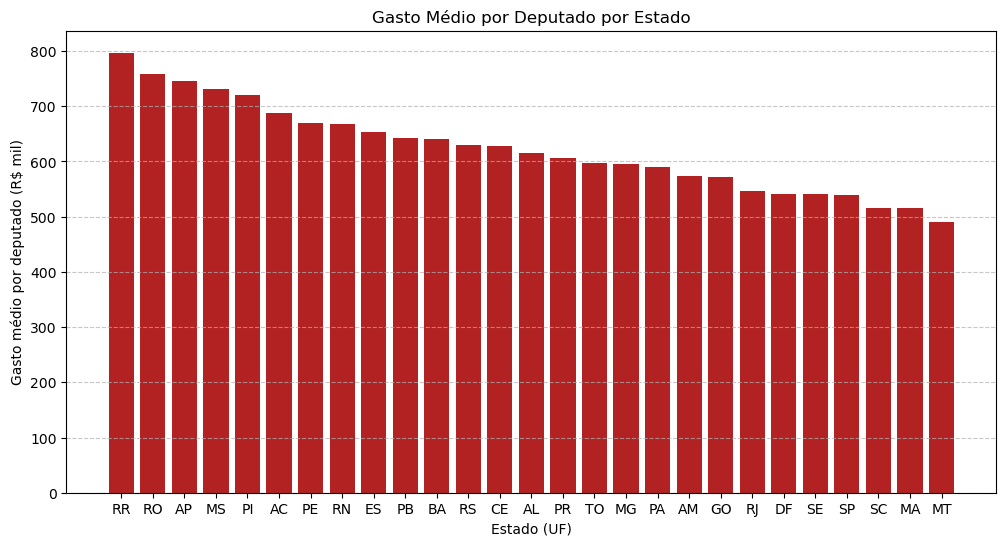

In [408]:
df_media_uf['df_media_por_deput_mil_uf'] = df_media_uf['gasto_med_pond'] / 1e3
df_media_uf = df_media_uf.sort_values(by='gasto_med_pond', ascending=False)  ## <<<--------------

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(df_media_uf['sgUF'], df_media_uf['df_media_por_deput_mil_uf'], color='firebrick')

# Configurações do gráfico
plt.xlabel("Estado (UF)")
plt.ylabel("Gasto médio por deputado (R$ mil)")
plt.title("Gasto Médio por Deputado por Estado")
plt.xticks(rotation=0, ha='center')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

## 2.3 Gastos por partido politico

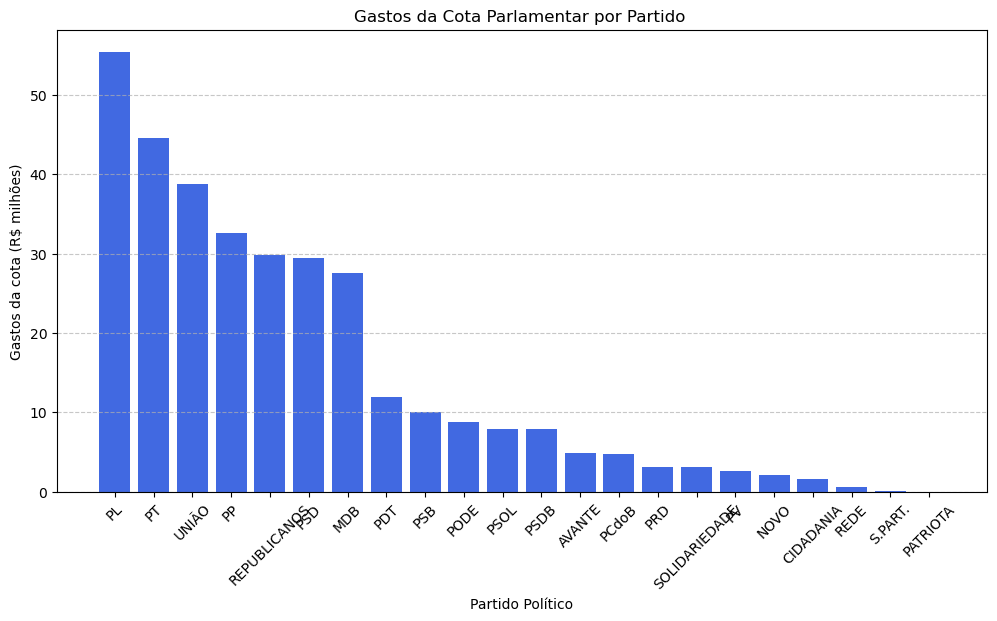

In [257]:
# Gastos totais por partido 

# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Agrupando os dados para obter a soma dos gastos por partido
df_gastos = df_filtrado.groupby('sgPartido')['vlrLiquido'].sum().reset_index()

# Convertendo para milhões de reais
df_gastos['vlrLiquido'] = df_gastos['vlrLiquido'] / 1e6

# Ordenando do maior para o menor gasto líquido
df_gastos = df_gastos.sort_values(by='vlrLiquido', ascending=False)

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(df_gastos['sgPartido'], df_gastos['vlrLiquido'], color='royalblue')

# Configurações do gráfico
plt.xlabel("Partido Político")
plt.ylabel("Gastos da cota (R$ milhões)")
plt.title("Gastos da Cota Parlamentar por Partido ")
plt.xticks(rotation=45)  # Rotacionando os partidos para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

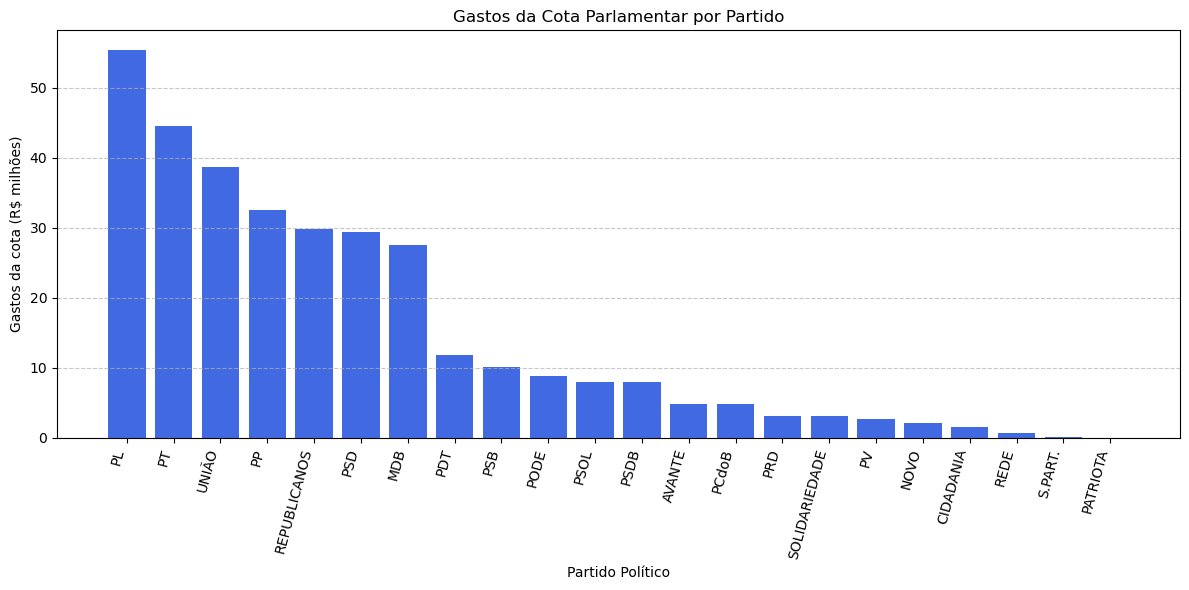

In [258]:
"""
Média simplificada
""" 

# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Agrupando os dados para obter a soma dos gastos por partido
df_gastos = df_filtrado.groupby('sgPartido')['vlrLiquido'].sum().reset_index()

# Convertendo para milhões de reais
df_gastos['vlrLiquido'] = df_gastos['vlrLiquido'] / 1e6

# Ordenando do maior para o menor gasto líquido
df_gastos = df_gastos.sort_values(by='vlrLiquido', ascending=False)

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))  # Aumentando o tamanho do gráfico
bars = plt.bar(df_gastos['sgPartido'], df_gastos['vlrLiquido'], color='royalblue')

# Configurações do gráfico
plt.xlabel("Partido Político")
plt.ylabel("Gastos da cota (R$ milhões)")
plt.title("Gastos da Cota Parlamentar por Partido")

# Ajustando os rótulos do eixo X para evitar sobreposição
plt.xticks(rotation=75, ha='right')  # Rotacionando e alinhando à direita

# Ajustando espaçamento entre os elementos do gráfico
plt.tight_layout()

# Adicionando linha de grade para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

In [422]:
df['numAnoMes_compet'].unique()

array([202302, 202306, 202307, 202308, 202309, 202310, 202303, 202304,
       202305, 202311, 202312, 202402, 202403, 202404, 202405, 202406,
       202407, 202408, 202409, 202410, 202411, 202412, 202401, 202502,
       202503, 202504, 202501])

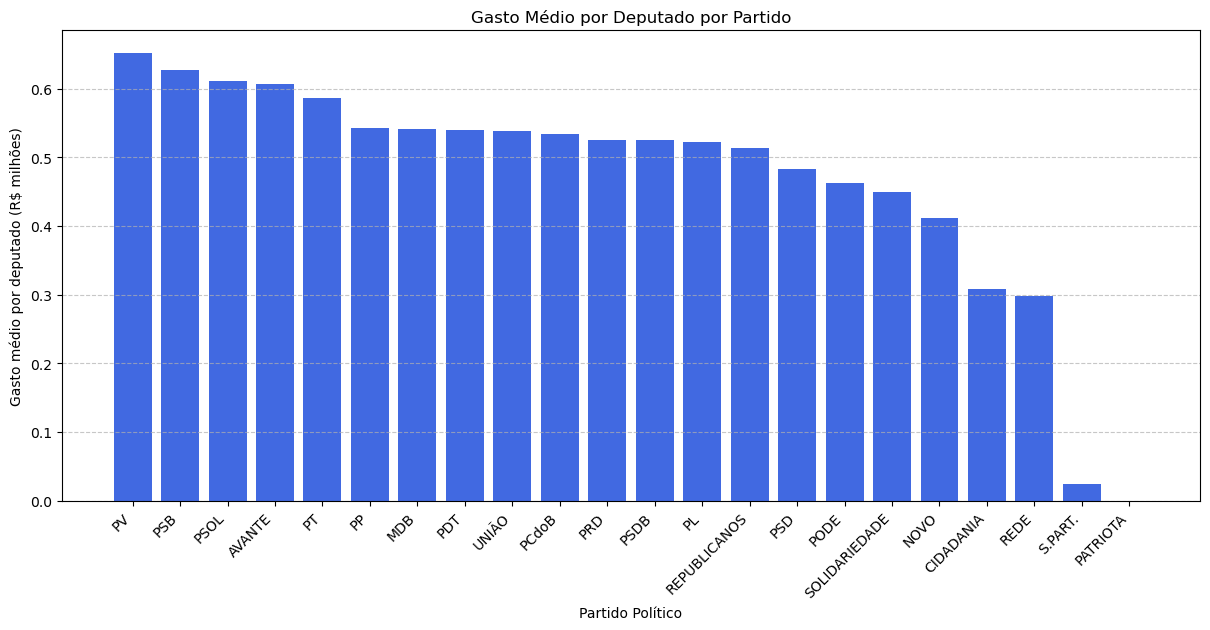

In [259]:

# gastos por deputado
# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Agrupando os dados para obter a soma dos gastos por partido
df_gastos = df_filtrado.groupby('sgPartido')['vlrLiquido'].sum().reset_index()

# Contando o número de deputados por partido
df_deputados = df_filtrado.groupby('sgPartido')['txNomeParlamentar'].nunique().reset_index()

# Juntando os dados de gastos e número de deputados
df_analise = pd.merge(df_gastos, df_deputados, on='sgPartido')

# Calculando o gasto médio por deputado em cada partido
df_analise['Gasto_por_Deputado'] = df_analise['vlrLiquido'] / df_analise['txNomeParlamentar']

# Convertendo para milhões de reais
df_analise['Gasto_por_Deputado'] = df_analise['Gasto_por_Deputado'] / 1e6

# Ordenando do maior para o menor gasto médio
df_analise = df_analise.sort_values(by='Gasto_por_Deputado', ascending=False)

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(df_analise['sgPartido'], df_analise['Gasto_por_Deputado'], color='royalblue')
plt.xticks(rotation=45, ha='right')  # Rotaciona os labels e alinha à direita
plt.tight_layout()  # Ajusta o layout automaticamente para evitar sobreposição
# Configurações do gráfico
plt.xlabel("Partido Político")
plt.ylabel("Gasto médio por deputado (R$ milhões)")
plt.title("Gasto Médio por Deputado por Partido")
plt.xticks(rotation=45)  # Rotacionando os partidos para melhor visualização
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

In [292]:
"""
Média ponderada 


"""
# Agrupar por 'sgPartido' e calcular o numerador e o denominador da média ponderada
df_media_ponderada_partido = df_final_agrup.groupby('sgPartido').agg(
    soma_numerador=('termo_numerador', 'sum'),
    soma_denominador=('nro_meses_gastos', 'sum')
).reset_index()

# Calcular a média ponderada e armazená-la em uma nova coluna
df_media_ponderada_partido['gasto_med_pond_part'] = df_media_ponderada_partido['soma_numerador'] / df_media_ponderada_partido['soma_denominador']

# Selecionar as colunas finais
df_media_ponderada_partido = df_media_ponderada_partido[['sgPartido', 'gasto_med_pond_part']]

# Visualizar o resultado
df_media_ponderada_partido

,sgPartido,gasto_med_pond_part
0,AVANTE,606476.691250
1,CIDADANIA,344331.066522
2,MDB,595328.880033
3,NOVO,411670.510000
4,PATRIOTA,0.000000
5,PCdoB,662191.925670
6,PDT,607442.527282
7,PL,583818.275073
8,PODE,558754.151083
9,PP,616987.496136


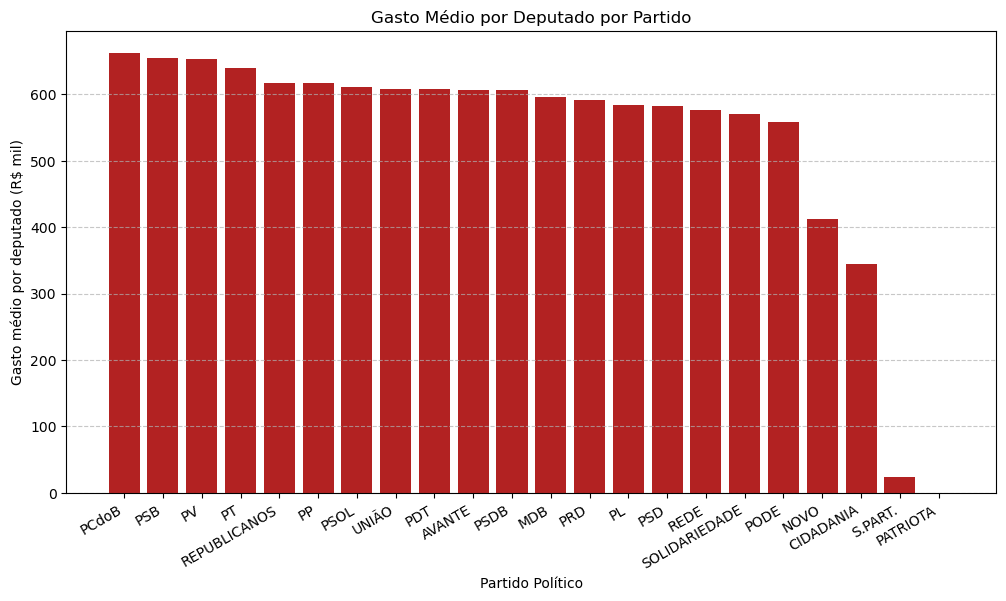

In [405]:
df_media_ponderada_partido['media_por_deput_mil_part'] = df_media_ponderada_partido['gasto_med_pond_part'] / 1e3
df_media_ponderada_partido= df_media_ponderada_partido.sort_values(by='gasto_med_pond_part', ascending=False)  ## <<<--------------

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(df_media_ponderada_partido['sgPartido'],
        df_media_ponderada_partido['media_por_deput_mil_part'], color='firebrick')

# Configurações do gráfico
plt.xlabel("Partido Político")
plt.ylabel("Gasto médio por deputado (R$ mil)")
plt.title("Gasto Médio por Deputado por Partido")
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

In [262]:
df.groupby(['sgPartido', 'numAnoMes_compet'])['txNomeParlamentar'].nunique().reset_index()

,sgPartido,numAnoMes_compet,txNomeParlamentar
0,AVANTE,202302,8
1,AVANTE,202303,8
2,AVANTE,202304,8
3,AVANTE,202305,8
4,AVANTE,202306,8
...,...,...,...
557,UNIÃO,202412,63
558,UNIÃO,202501,59
559,UNIÃO,202502,60
560,UNIÃO,202503,59


## 2.4 Gastos por Categoria 

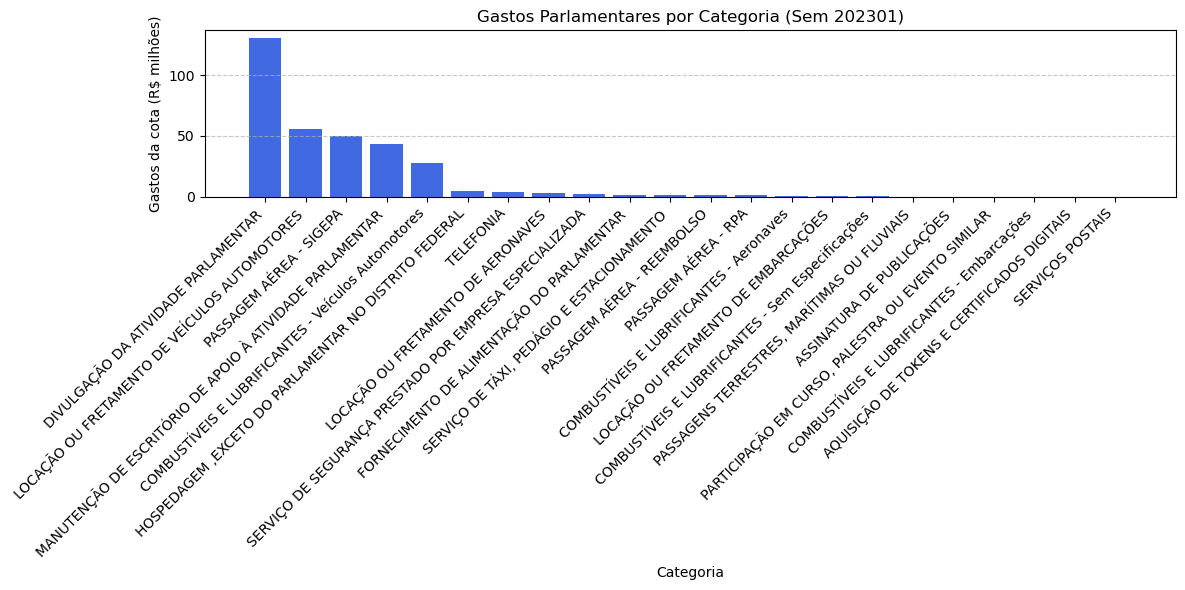

In [409]:

# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Agrupando os dados para obter a soma dos gastos por categoria
df_gastos = df_filtrado.groupby('desc_Subcota_Espec')['vlrLiquido'].sum().reset_index()

# Convertendo para milhões de reais
df_gastos['vlrLiquido'] = df_gastos['vlrLiquido'] / 1e6

# Ordenando do maior para o menor gasto
df_gastos = df_gastos.sort_values(by='vlrLiquido', ascending=False)

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(df_gastos['desc_Subcota_Espec'], df_gastos['vlrLiquido'], color='royalblue')

# Configurações do gráfico
plt.xlabel("Categoria")
plt.ylabel("Gastos da cota (R$ milhões)")
plt.title("Gastos Parlamentares por Categoria (Sem 202301)")
plt.xticks(rotation=45, ha='right')  # Rotacionando os labels para melhor visualização
plt.tight_layout()  # Ajustando o layout para evitar sobreposição
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

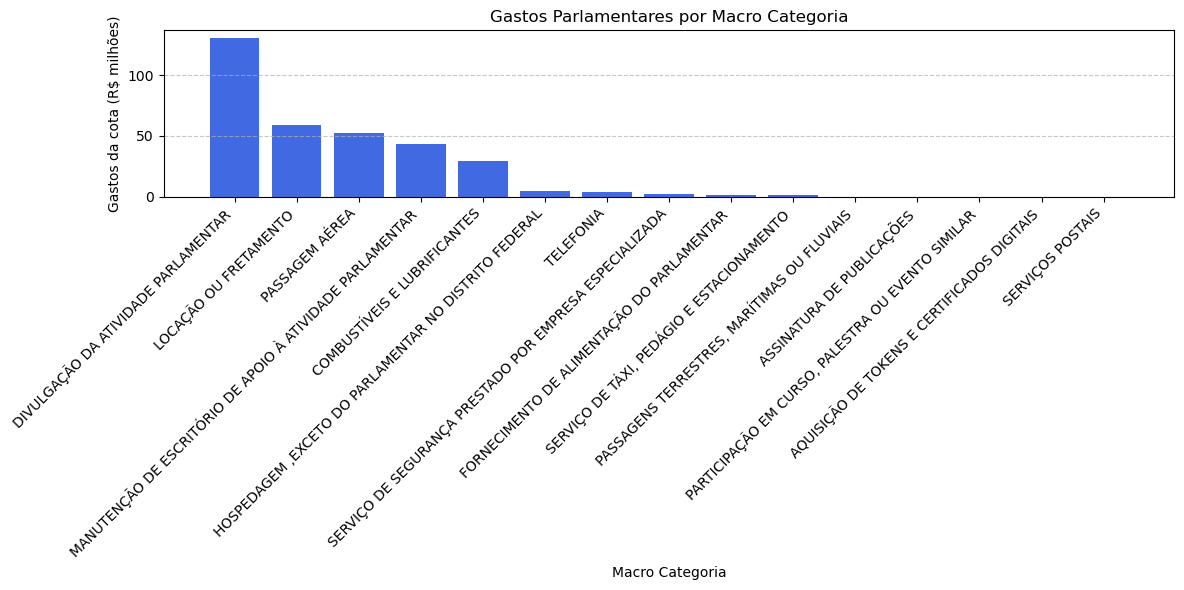

In [414]:
# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Agrupando os dados para obter a soma dos gastos por macro categoria
df_gastos = df_filtrado.groupby('macro_categoria')['vlrLiquido'].sum().reset_index()

# Convertendo para milhões de reais
df_gastos['vlrLiquido'] = df_gastos['vlrLiquido'] / 1e6

# Ordenando do maior para o menor gasto
df_gastos = df_gastos.sort_values(by='vlrLiquido', ascending=False)

# Criando o gráfico de barras
plt.figure(figsize=(12, 6))
plt.bar(df_gastos['macro_categoria'], df_gastos['vlrLiquido'], color='royalblue')

# Configurações do gráfico
plt.xlabel("Macro Categoria")
plt.ylabel("Gastos da cota (R$ milhões)")
plt.title("Gastos Parlamentares por Macro Categoria")
plt.xticks(rotation=45, ha='right')  # Rotacionando os labels para melhor visualização
plt.tight_layout()  # Ajustando o layout para evitar sobreposição
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

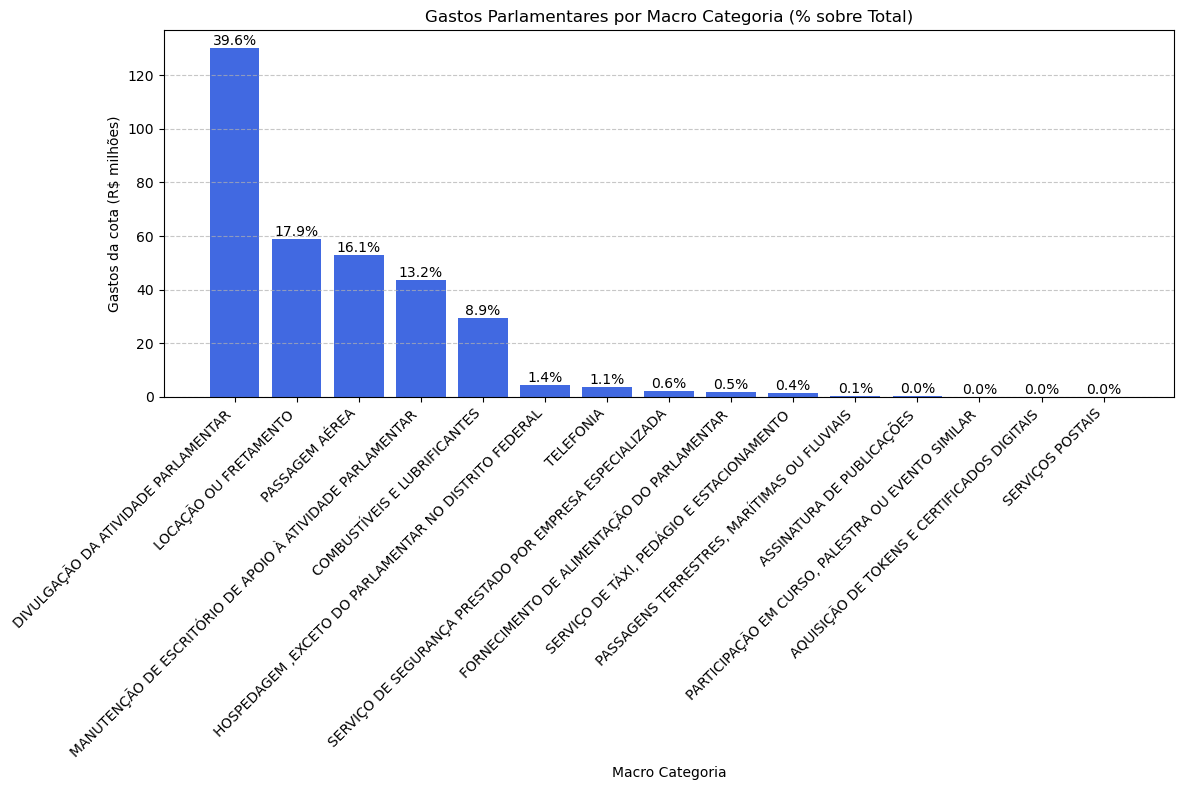

In [438]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Agrupando os dados para obter a soma dos gastos por macro categoria
df_gastos = df_filtrado.groupby('macro_categoria')['vlrLiquido'].sum().reset_index()

# Convertendo para milhões de reais
df_gastos['vlrLiquido'] = df_gastos['vlrLiquido'] / 1e6

# Calculando a porcentagem de cada categoria em relação ao total
df_gastos['Porcentagem'] = (df_gastos['vlrLiquido'] / df_gastos['vlrLiquido'].sum()) * 100

# Ordenando do maior para o menor gasto
df_gastos = df_gastos.sort_values(by='vlrLiquido', ascending=False)

# Criando o gráfico de barras
plt.figure(figsize=(12, 8))
bars = plt.bar(df_gastos['macro_categoria'], df_gastos['vlrLiquido'], color='royalblue')

#------------------------------------------
# Cria a lista de rótulos formatados em 2 linhas
#labels_wrapped = df_gastos['macro_categoria'].str.wrap(width=50)

# Adicionando os valores de porcentagem em cada barra
for bar, pct in zip(bars, df_gastos['Porcentagem']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{pct:.1f}%", 
             ha='center', va='bottom', fontsize=10, color="black")

# Configurações do gráfico
plt.xlabel("Macro Categoria")
plt.ylabel("Gastos da cota (R$ milhões)")
plt.title("Gastos Parlamentares por Macro Categoria (% sobre Total)")

plt.xticks(rotation=45, ha='right')  # Melhorando a visualização dos labels
#plt.xticks(ticks=df_gastos['macro_categoria'], labels=labels_wrapped, rotation=60, ha='center')
# O parâmetro 'ticks' recebe os valores originais para as posições
# O parâmetro 'labels' recebe os novos textos com a quebra de linha

plt.tight_layout()  # Ajustando para evitar sobreposição
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

In [428]:
!pip install textwrap

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement textwrap (from versions: none)

[notice] A new release of pip is available: 25.1.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: No matching distribution found for textwrap


In [ ]:
# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Agrupando os dados por tempo (numAnoMes_compet) e Macro Categoria (TipoDocumento)
df_agrupado = df_filtrado.groupby(['numAnoMes_compet', 'macro_categoria'])['vlrLiquido'].sum().reset_index()

# Convertendo numAnoMes_compet para um formato de data válido (AAAAMM → AAAA-MM-01)
df_agrupado['Data'] = pd.to_datetime(df_agrupado['numAnoMes_compet'].astype(str) + '01', format='%Y%m%d')

# Convertendo os valores para milhões de reais
df_agrupado['vlrLiquido'] = df_agrupado['vlrLiquido'] / 1e6

# Criando o gráfico
plt.figure(figsize=(12, 6))

# Plotando uma linha para cada macro categoria
for categoria in df_agrupado['macro_categoria'].unique():
    dados_categoria = df_agrupado[df_agrupado['macro_categoria'] == categoria]
    plt.plot(dados_categoria['Data'], dados_categoria['vlrLiquido'], label=categoria)

# Configurações do gráfico
plt.xlabel("")  # Omitindo o nome do eixo X
plt.ylabel("Gastos da cota (R$ milhões)")
plt.title("Gastos ao Longo do Tempo por Macro Categoria (Sem 202301)")
plt.xticks(rotation=45)  # Melhorando a legibilidade das datas
plt.legend(title="Macro Categoria", bbox_to_anchor=(1.05, 1), loc='upper left')  # Adicionando legenda
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()  # Ajustando para evitar sobreposição

# Exibindo o gráfico
plt.show()

In [ ]:
plt

# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Agrupando os dados por tempo (numAnoMes_compet) e Macro Categoria (macro_categoria)
df_agrupado = df_filtrado.groupby(['numAnoMes_compet', 'macro_categoria'])['vlrLiquido'].sum().reset_index()

# Convertendo numAnoMes_compet para um formato de data válido (AAAAMM → AAAA-MM-01)
df_agrupado['Data'] = pd.to_datetime(df_agrupado['numAnoMes_compet'].astype(str) + '01', format='%Y%m%d')

# Convertendo os valores para milhões de reais
df_agrupado['vlrLiquido'] = df_agrupado['vlrLiquido'] / 1e6

# Ordenando categorias pela soma total dos gastos
categorias_ordenadas = df_agrupado.groupby('macro_categoria')['vlrLiquido'].sum().sort_values(ascending=False).index

# Criando o gráfico
plt.figure(figsize=(13, 10))

# Plotando uma linha para cada macro categoria, na ordem decrescente de gasto
for categoria in categorias_ordenadas:
    dados_categoria = df_agrupado[df_agrupado['macro_categoria'] == categoria]
    plt.plot(dados_categoria['Data'], dados_categoria['vlrLiquido'], label=categoria)

# Adicionando linhas verticais pontilhadas nos meses de dezembro de 2023 e dezembro de 2024
plt.axvline(pd.to_datetime("2023-12-01"), color='red', linestyle='dashed', linewidth=2)
plt.axvline(pd.to_datetime("2024-12-01"), color='red', linestyle='dashed', linewidth=2)

# Configurações do gráfico
plt.xlabel("")  # Omitindo o nome do eixo X
plt.ylabel("Gastos da cota (R$ milhões)")
plt.title("Gastos ao Longo do Tempo por Macro Categoria")
plt.xticks(rotation=45)  # Melhorando a legibilidade das datas
plt.grid(True, linestyle='--', alpha=0.7)

# Configurando a legenda abaixo do gráfico e ordenando por relevância

plt.legend(title="Macro Categoria", bbox_to_anchor=(0.5, -0.25), loc='upper center', ncol=2, fontsize=10)
# Ajustando layout
plt.tight_layout()

# Exibindo o gráfico
plt.show()

## 2.5 Exploraçao das categorias

### 2.5.1 divulgaçao de atividade parlamentar

In [ ]:
df[df['A'].isna()]

In [623]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 515395 entries, 0 to 539726
Data columns (total 41 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   txNomeParlamentar          515395 non-null  object        
 1   cpf                        513315 non-null  float64       
 2   ideCadastro                513346 non-null  float64       
 3   nuCarteiraParlamentar      513346 non-null  float64       
 4   nuLegislatura              515395 non-null  int64         
 5   sgUF                       513346 non-null  object        
 6   sgPartido                  513346 non-null  object        
 7   codLegislatura             515395 non-null  int64         
 8   numSubCota                 515395 non-null  int64         
 9   txtDescricao               515395 non-null  object        
 10  numEspecificacaoSubCota    515395 non-null  int64         
 11  txtDescricaoEspecificacao  161057 non-null  object       

In [624]:
df['macro_categoria'].unique()

array(['MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR',
       'COMBUSTÍVEIS E LUBRIFICANTES',
       'FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR',
       'LOCAÇÃO OU FRETAMENTO', 'DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR',
       'PASSAGEM AÉREA',
       'HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL',
       'SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO',
       'ASSINATURA DE PUBLICAÇÕES',
       'SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA',
       'TELEFONIA', 'PASSAGENS TERRESTRES, MARÍTIMAS OU FLUVIAIS',
       'SERVIÇOS POSTAIS', 'AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS',
       'PARTICIPAÇÃO EM CURSO, PALESTRA OU EVENTO SIMILAR'], dtype=object)

In [625]:
df_filtrado = df[df['macro_categoria'] == 'DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR']
colunas_selecionadas = [
    'txNomeParlamentar', 'sgPartido', 'sgUF', 'vlrLiquido', 'numAnoMes_compet', 'macro_categoria'
]
df_final = df_filtrado[colunas_selecionadas].copy()

# --- Adaptando o código para incluir as novas faixas ---

# 2) Criar a coluna 'vlrLiquid_faixa' com as novas faixas
# Define os novos limites das faixas e os rótulos
bins = [0, 5000, 10000, 20000, 30000, 40000, float('inf')]
labels = ['0 a 5000', '5001 a 10000', '10001 a 20000', '20001 a 30000', '30001 a 40000', 'Mais de 40000']

# Usa pd.cut para criar as faixas de valor
df_final['vlrLiquid_faixa'] = pd.cut(df_final['vlrLiquido'], bins=bins, labels=labels, right=True)
df_final

,txNomeParlamentar,sgPartido,sgUF,vlrLiquido,numAnoMes_compet,macro_categoria,vlrLiquid_faixa
238,LIDERANÇA DO PDT,NaN,NaN,NaN,202303,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,NaN
239,LIDERANÇA DO PDT,NaN,NaN,NaN,202306,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,NaN
240,LIDERANÇA DO PDT,NaN,NaN,NaN,202309,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,NaN
241,LIDERANÇA DO PDT,NaN,NaN,NaN,202311,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,NaN
242,LIDERANÇA DO PDT,NaN,NaN,NaN,202302,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,NaN
...,...,...,...,...,...,...,...
539529,João Cury,MDB,SP,10000.0,202503,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,5001 a 10000
539530,João Cury,MDB,SP,10000.0,202504,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,5001 a 10000
539531,João Cury,MDB,SP,18000.0,202502,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,10001 a 20000
539532,João Cury,MDB,SP,16150.0,202503,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,10001 a 20000


## 2.6 - Deputados que mais gastaram  os que menos gastaram

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Criando a coluna combinada "Partido - Deputado"
df_filtrado['Partido_Deputado'] = df_filtrado['sgPartido'] + " - " + df_filtrado['txNomeParlamentar']

# Agrupando os dados por "Partido - Deputado" e somando os gastos líquidos
df_gastos = df_filtrado.groupby('Partido_Deputado')['vlrLiquido'].sum().reset_index()

# Convertendo valores para milhões de reais
df_gastos['vlrLiquido'] = df_gastos['vlrLiquido'] / 1e6

# Ordenando do maior para o menor gasto
df_gastos = df_gastos.sort_values(by='vlrLiquido', ascending=False)

# Separando os 20 deputados que mais gastaram
df_mais_gastos = df_gastos.head(20)

# Separando os 20 deputados que menos gastaram
df_menos_gastos = df_gastos.tail(20)

# Criando os gráficos
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# Gráfico dos 20 deputados que mais gastaram
axes[0].bar(df_mais_gastos['Partido_Deputado'], df_mais_gastos['vlrLiquido'], color='royalblue')
axes[0].set_ylabel("Gastos da cota (R$ milhões)")
axes[0].set_title("Os 20 Deputados que Mais Gastaram (Sem 202301)")
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Gráfico dos 20 deputados que menos gastaram
axes[1].bar(df_menos_gastos['Partido_Deputado'], df_menos_gastos['vlrLiquido'], color='darkorange')
axes[1].set_ylabel("Gastos da cota (R$ milhões)")
axes[1].set_title("Os 20 Deputados que Menos Gastaram (Sem 202301)")
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

# Ajustando os rótulos do eixo X
plt.xticks(rotation=75, ha='right')

# Ajustando o layout para melhor visualização
plt.tight_layout()

# Exibindo os gráficos
plt.show()

In [ ]:
# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Criando a coluna combinada "Partido - Deputado"
df_filtrado['Partido_Deputado'] = df_filtrado['sgPartido'] + " - " + df_filtrado['txNomeParlamentar']

# Agrupando os dados por "Partido - Deputado" e somando os gastos líquidos
df_gastos = df_filtrado.groupby('Partido_Deputado')['vlrLiquido'].sum().reset_index()

# Convertendo valores para milhões de reais
df_gastos['vlrLiquido'] = df_gastos['vlrLiquido'] / 1e6

# Ordenando do maior para o menor gasto
df_gastos = df_gastos.sort_values(by='vlrLiquido', ascending=False)

# Pegando os 20 deputados que mais gastaram
df_mais_gastos = df_gastos.head(20)

# Criando o gráfico
plt.figure(figsize=(10, 6))
plt.bar(df_mais_gastos['Partido_Deputado'], df_mais_gastos['vlrLiquido'], color='red')

# Configurações do gráfico
plt.xlabel("Partido - Deputado")
plt.ylabel("Gastos da cota (R$ milhões)")
plt.title("Os 20 Deputados que Mais Gastaram")
plt.xticks(rotation=75, ha='right')  # Rotacionando os nomes para melhor leitura
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Exibindo o gráfico
plt.show()

In [ ]:
# Criando a coluna combinada "Partido - Nome - UF"
df_filtrado['Partido_Nome_UF'] = df_filtrado['sgPartido'] + " - " + df_filtrado['txNomeParlamentar'] + " - " + df_filtrado['sgUF']

# Agrupando os dados por "Partido - Nome - UF" e somando os gastos líquidos
df_gastos = df_filtrado.groupby('Partido_Nome_UF')['vlrLiquido'].sum().reset_index()

# Convertendo valores para milhões de reais
df_gastos['vlrLiquido'] = df_gastos['vlrLiquido'] / 1e6

# Ordenando do maior para o menor gasto e selecionando os 20 mais gastadores
df_gastos = df_gastos.sort_values(by='vlrLiquido', ascending=False).head(20)

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(df_gastos['Partido_Nome_UF'], df_gastos['vlrLiquido'], color='red')

# Configurações do gráfico
plt.xlabel("Partido - Nome - UF")
plt.ylabel("Gastos da cota (R$ milhões)")
plt.title("Os 20 Deputados que Mais Gastaram")

# Ajustando os rótulos do eixo X para melhor visualização
plt.xticks(rotation=75, ha='right')

# Ajustando espaçamento entre os elementos do gráfico
plt.tight_layout()

# Adicionando linha de grade para melhorar a leitura dos valores
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

In [ ]:
# Filtrando os dados para remover o ano-mês 202301
df_filtrado = df[df['numAnoMes_compet'] != 202301]

# Criando a coluna combinada "Partido - Deputado"
df_filtrado['Partido_Deputado'] = df_filtrado['sgPartido'] + " - " + df_filtrado['txNomeParlamentar']

# Agrupando os dados por "Partido - Deputado" e somando os gastos líquidos
df_gastos = df_filtrado.groupby('Partido_Deputado')['vlrLiquido'].sum().reset_index()

# Convertendo valores para milhões de reais
df_gastos['vlrLiquido'] = df_gastos['vlrLiquido'] / 1e3

# Ordenando do maior para o menor gasto
df_gastos = df_gastos.sort_values(by='vlrLiquido', ascending=False)

# Pegando os 20 deputados que menos gastaram
df_menos_gastos = df_gastos.tail(20)

# Criando o gráfico
plt.figure(figsize=(10, 6))
plt.bar(df_menos_gastos['Partido_Deputado'], df_menos_gastos['vlrLiquido'], color='green')

# Configurações do gráfico
plt.xlabel("Partido - Deputado")
plt.ylabel("Gastos da cota (R$ mil)")
plt.title("Os 20 Deputados que Menos Gastaram")
plt.xticks(rotation=75, ha='right')  # Rotacionando os nomes para melhor leitura
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Exibindo o gráfico
plt.show()

In [ ]:

# Criando a coluna combinada "Partido - Nome - UF"
df_filtrado['Partido_Nome_UF'] = df_filtrado['sgPartido'] + " - " + df_filtrado['txNomeParlamentar'] + " - " + df_filtrado['sgUF']

# Agrupando os dados por "Partido - Nome - UF" e somando os gastos líquidos
df_gastos = df_filtrado.groupby('Partido_Nome_UF')['vlrLiquido'].sum().reset_index()

# Convertendo valores para milhões de reais
df_gastos['vlrLiquido'] = df_gastos['vlrLiquido'] / 1e3

# Ordenando do menor para o maior gasto e selecionando os 20 deputados que menos gastaram
df_menos_gastos = df_gastos.sort_values(by='vlrLiquido', ascending=True).head(20)

# Criando o gráfico de barras
plt.figure(figsize=(10, 6))
plt.bar(df_menos_gastos['Partido_Nome_UF'], df_menos_gastos['vlrLiquido'], color='green')

# Configurações do gráfico
plt.xlabel("Partido - Nome - UF")
plt.ylabel("Gastos da cota (R$ mil)")
plt.title("Os 20 Deputados que Menos Gastaram")

# Ajustando os rótulos do eixo X para melhor visualização
plt.xticks(rotation=75, ha='right')

# Ajustando espaçamento entre os elementos do gráfico
plt.tight_layout()

# Adicionando linha de grade para melhorar a leitura dos valores
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Exibindo o gráfico
plt.show()

##

2.8  - Verificaçao de incosistencias

In [130]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 515395 entries, 0 to 539726
Data columns (total 40 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   txNomeParlamentar          515395 non-null  object        
 1   cpf                        513315 non-null  float64       
 2   ideCadastro                513346 non-null  float64       
 3   nuCarteiraParlamentar      513346 non-null  float64       
 4   nuLegislatura              515395 non-null  int64         
 5   sgUF                       513346 non-null  object        
 6   sgPartido                  513346 non-null  object        
 7   codLegislatura             515395 non-null  int64         
 8   numSubCota                 515395 non-null  int64         
 9   txtDescricao               515395 non-null  object        
 10  numEspecificacaoSubCota    515395 non-null  int64         
 11  txtDescricaoEspecificacao  161057 non-null  object       

In [ ]:
#.fillna(0)
df['datEmissao_AAAAMM'] = df['datEmissao_AAAAMM'].astype('Int64')
df['comparacao'] = df['datEmissao_AAAAMM'] < df['numAnoMes_compet']
total_iguais = df['comparacao'].sum()  # 'True' é tratado como 1 em somas
total_diferentes = len(df) - total_iguais
print(f"Total de valores iguais: {total_iguais}")
print(f"Total de valores diferentes: {total_diferentes}")

## 3. Avaliação de agrupamentos - técnicas exploratórias

In [439]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 515395 entries, 0 to 539726
Data columns (total 41 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   txNomeParlamentar          515395 non-null  object        
 1   cpf                        513315 non-null  float64       
 2   ideCadastro                513346 non-null  float64       
 3   nuCarteiraParlamentar      513346 non-null  float64       
 4   nuLegislatura              515395 non-null  int64         
 5   sgUF                       513346 non-null  object        
 6   sgPartido                  513346 non-null  object        
 7   codLegislatura             515395 non-null  int64         
 8   numSubCota                 515395 non-null  int64         
 9   txtDescricao               515395 non-null  object        
 10  numEspecificacaoSubCota    515395 non-null  int64         
 11  txtDescricaoEspecificacao  161057 non-null  object       

In [441]:
df.head()

,txNomeParlamentar,cpf,ideCadastro,nuCarteiraParlamentar,nuLegislatura,sgUF,sgPartido,codLegislatura,numSubCota,txtDescricao,...,urlDocumento,datEmissao_convert,datEmissao_AAAAMM,numAnoMes_compet,TipoDocumento,desc_Subcota_Espec,macro_categoria,flag_reeleito,comparacao,flag_lid
0,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,https://www.camara.leg.br/cota-parlamentar/doc...,2023-02-07,202302,202302,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,Nao aplicavel,False,1
1,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,https://www.camara.leg.br/cota-parlamentar/doc...,2023-06-06,202306,202306,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,Nao aplicavel,False,1
2,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,https://www.camara.leg.br/cota-parlamentar/doc...,2023-07-12,202307,202307,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,Nao aplicavel,False,1
3,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,https://www.camara.leg.br/cota-parlamentar/doc...,2023-08-03,202308,202308,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,Nao aplicavel,False,1
4,LID.GOV-CD,NaN,NaN,NaN,2023,NaN,NaN,57,1,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,...,https://www.camara.leg.br/cota-parlamentar/doc...,2023-09-12,202309,202309,NF,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,Nao aplicavel,False,1


In [ ]:
PAra aplciar clusterizaçao , temos apenas 1 variavel vamos agrupar a base acima vlr_quanti

In [ ]:
df_quali = df[['sgUF', 'sgPartido','flag_reeleito','flag_lid',
              'TipoDocumento','desc_Subcota_Espec', 'macro_categoria',
              'numAnoMes_compet']]

In [ ]:
from scipy.stats import zscore
import numpy as np

## 3.1  Clusterizaçao - com var metricas   ( Etapa 1) 


### 3.1.1 Clusterizaçao hierarquica

### 3.1.2 Kmeans

In [593]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
import scipy.stats as stats
from scipy.stats import zscore
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
import pingouin as pg
import plotly.express as px 
import plotly.io as pio
pio.renderers.default='browser'
import prince
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from sklearn.metrics import silhouette_score


In [451]:
df_categorias

,macro_categoria,numSubCota,txtDescricao,numEspecificacaoSubCota,txtDescricaoEspecificacao,desc_Subcota_Espec
52006,AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS,145,AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS,0,NaN,AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS
842,ASSINATURA DE PUBLICAÇÕES,12,ASSINATURA DE PUBLICAÇÕES,0,NaN,ASSINATURA DE PUBLICAÇÕES
22,COMBUSTÍVEIS E LUBRIFICANTES,3,COMBUSTÍVEIS E LUBRIFICANTES,1,Veículos Automotores,COMBUSTÍVEIS E LUBRIFICANTES - Veículos Automo...
4347,COMBUSTÍVEIS E LUBRIFICANTES,3,COMBUSTÍVEIS E LUBRIFICANTES,2,Embarcações,COMBUSTÍVEIS E LUBRIFICANTES - Embarcações
840,COMBUSTÍVEIS E LUBRIFICANTES,3,COMBUSTÍVEIS E LUBRIFICANTES,3,Aeronaves,COMBUSTÍVEIS E LUBRIFICANTES - Aeronaves
24681,COMBUSTÍVEIS E LUBRIFICANTES,3,COMBUSTÍVEIS E LUBRIFICANTES,4,Sem especificações,COMBUSTÍVEIS E LUBRIFICANTES - Sem Especificações
238,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,5,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,0,NaN,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR
185,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,13,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR,0,NaN,FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR
745,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...",14,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...",0,NaN,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ..."
10955,LOCAÇÃO OU FRETAMENTO,119,LOCAÇÃO OU FRETAMENTO DE AERONAVES,0,NaN,LOCAÇÃO OU FRETAMENTO DE AERONAVES


In [452]:
from scipy.stats import zscore
import numpy as np

In [454]:
# --- 1) e 2) Seleção de variáveis e agrupamento ---
# Agrupamos pelas colunas solicitadas e somamos o 'vlrliquido'
# Usamos 'reset_index()' para transformar as colunas do agrupamento em colunas normais novamente.


df_agrupado = df.groupby(['txNomeParlamentar', 'sgUF', 'sgPartido', 
                          'flag_reeleito', 'flag_lid', 'desc_Subcota_Espec'])['vlrLiquido'].sum().reset_index()
print("DataFrame após o agrupamento:")
print(df_agrupado.head())
print("-" * 50)



DataFrame após o agrupamento:
  txNomeParlamentar sgUF sgPartido flag_reeleito  flag_lid  \
0    AJ Albuquerque   CE        PP           Sim         0   
1    AJ Albuquerque   CE        PP           Sim         0   
2    AJ Albuquerque   CE        PP           Sim         0   
3    AJ Albuquerque   CE        PP           Sim         0   
4    AJ Albuquerque   CE        PP           Sim         0   

                                  desc_Subcota_Espec  vlrLiquido  
0  COMBUSTÍVEIS E LUBRIFICANTES - Veículos Automo...    61492.81  
1                DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR    77000.00  
2  HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...    40046.00  
3                 LOCAÇÃO OU FRETAMENTO DE AERONAVES    15000.00  
4      LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES   156000.00  
--------------------------------------------------


In [460]:
# --- ETAPA 3: Adicionar a nova coluna 'nome_var_categoria_espec' ---
# Mapeamento fornecido para criar a nova coluna
mapeamento_categorias = {
    'AQUISIÇÃO DE TOKENS E CERTIFICADOS DIGITAIS': 'vl_tokens',
    'ASSINATURA DE PUBLICAÇÕES': 'vl_assinaturas',
    'COMBUSTÍVEIS E LUBRIFICANTES - Veículos Automotores': 'vl_comb_autom',
    'COMBUSTÍVEIS E LUBRIFICANTES - Embarcações': 'vl_comb_embarc',
    'COMBUSTÍVEIS E LUBRIFICANTES - Aeronaves': 'vl_comb_aeronaves',
    'COMBUSTÍVEIS E LUBRIFICANTES - Sem Especificações': 'vl_comb_semespec',
    'DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR': 'vl_divulg_ativ',
    'FORNECIMENTO DE ALIMENTAÇÃO DO PARLAMENTAR': 'vl_alimentacao',
    'HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO FEDERAL': 'vl_hospedagem',
    'LOCAÇÃO OU FRETAMENTO DE AERONAVES': 'vl_locfret_aeronave',
    'LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES': 'vl_locfret_autom',
    'LOCAÇÃO OU FRETAMENTO DE EMBARCAÇÕES': 'vl_locfret_embarc',
    'MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE PARLAMENTAR': 'vl_manut_escritorio',
    'PARTICIPAÇÃO EM CURSO, PALESTRA OU EVENTO SIMILAR': 'vl_cursos_eventos',
    'PASSAGEM AÉREA - REEMBOLSO': 'vl_pass_aerea_reembolso',
    'PASSAGEM AÉREA - SIGEPA': 'vl_pass_aerea_sigepa',
    'PASSAGEM AÉREA - RPA': 'vl_pass_aerea_rpa',
    'PASSAGENS TERRESTRES, MARÍTIMAS OU FLUVIAIS': 'vl_pass_ter_mar_flu',
    'SERVIÇO DE SEGURANÇA PRESTADO POR EMPRESA ESPECIALIZADA': 'vl_servseguranca',
    'SERVIÇO DE TÁXI, PEDÁGIO E ESTACIONAMENTO': 'vl_taxi_ped_estac',
    'SERVIÇOS POSTAIS': 'vl_serv_postais',
    'TELEFONIA': 'vl_telefonia'
}

df_agrupado['nome_var_categoria_espec'] = df_agrupado['desc_Subcota_Espec'].map(mapeamento_categorias)

print("--- DataFrame com a nova coluna de categoria (Etapa 3) ---")
print(df_agrupado)
print("\n" + "="*50 + "\n")

--- DataFrame com a nova coluna de categoria (Etapa 3) ---
     txNomeParlamentar sgUF sgPartido flag_reeleito  flag_lid  \
0       AJ Albuquerque   CE        PP           Sim         0   
1       AJ Albuquerque   CE        PP           Sim         0   
2       AJ Albuquerque   CE        PP           Sim         0   
3       AJ Albuquerque   CE        PP           Sim         0   
4       AJ Albuquerque   CE        PP           Sim         0   
...                ...  ...       ...           ...       ...   
5467        Átila Lira   PI        PP           Nao         0   
5468        Átila Lira   PI        PP           Nao         0   
5469        Átila Lira   PI        PP           Nao         0   
5470        Átila Lira   PI        PP           Nao         0   
5471        Átila Lira   PI        PP           Nao         0   

                                     desc_Subcota_Espec    vlrLiquido  \
0     COMBUSTÍVEIS E LUBRIFICANTES - Veículos Automo...  6.149281e+04   
1             

In [461]:
df_agrupado[['desc_Subcota_Espec', 'nome_var_categoria_espec']].drop_duplicates()

,desc_Subcota_Espec,nome_var_categoria_espec
0,COMBUSTÍVEIS E LUBRIFICANTES - Veículos Automo...,vl_comb_autom
1,DIVULGAÇÃO DA ATIVIDADE PARLAMENTAR,vl_divulg_ativ
2,"HOSPEDAGEM ,EXCETO DO PARLAMENTAR NO DISTRITO ...",vl_hospedagem
3,LOCAÇÃO OU FRETAMENTO DE AERONAVES,vl_locfret_aeronave
4,LOCAÇÃO OU FRETAMENTO DE VEÍCULOS AUTOMOTORES,vl_locfret_autom
5,MANUTENÇÃO DE ESCRITÓRIO DE APOIO À ATIVIDADE ...,vl_manut_escritorio
6,PASSAGEM AÉREA - REEMBOLSO,vl_pass_aerea_reembolso
7,PASSAGEM AÉREA - SIGEPA,vl_pass_aerea_sigepa
8,TELEFONIA,vl_telefonia
9,COMBUSTÍVEIS E LUBRIFICANTES - Embarcações,vl_comb_embarc


In [470]:
# --- ETAPA 4: Pivotar a coluna 'nome_var_categoria_espec' ---
# Define o índice para o pivot
indices_pivot = [
    'txNomeParlamentar', 
    'sgUF', 
    'sgPartido', 
    'flag_reeleito', 
    'flag_lid'
]

# Pivota o dataframe. fillna(0) preenche os valores ausentes com 0.
df_quanti_preliminar = df_agrupado.pivot_table(
    index=indices_pivot, 
    columns='nome_var_categoria_espec', 
    values='vlrLiquido', 
    aggfunc='sum'
).reset_index().fillna(0)
df_quanti_preliminar

nome_var_categoria_espec,txNomeParlamentar,sgUF,sgPartido,flag_reeleito,flag_lid,vl_alimentacao,vl_assinaturas,vl_comb_aeronaves,vl_comb_autom,vl_comb_embarc,...,vl_manut_escritorio,vl_pass_aerea_reembolso,vl_pass_aerea_rpa,vl_pass_aerea_sigepa,vl_pass_ter_mar_flu,vl_serv_postais,vl_servseguranca,vl_taxi_ped_estac,vl_telefonia,vl_tokens
0,AJ Albuquerque,CE,PP,Sim,0,0.00,0.0,0.00,61492.81,0.00,...,12918.45,29291.60,0.000000e+00,81187.11,0.0,0.0,0.00,0.00,4532.09,0.0
1,Abilio Brunini,MT,PL,Nao,0,0.00,0.0,0.00,51148.78,780.80,...,110234.16,0.00,0.000000e+00,68795.75,0.0,0.0,0.00,0.00,569.33,0.0
2,Acácio Favacho,AP,MDB,Sim,0,0.00,0.0,0.00,78715.85,0.00,...,7873.50,19797.01,0.000000e+00,200208.03,0.0,0.0,0.00,0.00,8661.87,0.0
3,Adail Filho,AM,REPUBLICANOS,Nao,0,0.00,0.0,0.00,32435.25,11143.56,...,0.00,0.00,0.000000e+00,72600.96,0.0,0.0,0.00,0.00,1568.59,0.0
4,Adilson Barroso,SP,PL,Nao,0,6474.82,0.0,0.00,76702.90,0.00,...,83788.23,2823.90,2.004021e+04,61078.03,0.0,0.0,0.00,16908.15,3285.72,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,Zé Silva,MG,SOLIDARIEDADE,Sim,0,3016.50,0.0,35033.64,42942.90,1580.65,...,76002.30,0.00,0.000000e+00,56270.25,0.0,0.0,0.00,0.00,14689.55,0.0
613,Zé Trovão,SC,PL,Nao,0,4602.61,0.0,0.00,90483.88,0.00,...,304882.96,0.00,0.000000e+00,68044.30,0.0,0.0,11135.73,5982.31,8908.38,0.0
614,Zé Vitor,MG,PL,Sim,0,0.00,0.0,0.00,67697.84,0.00,...,1440.65,0.00,2.862450e+03,48568.73,0.0,0.0,0.00,772.86,81.10,0.0
615,Átila Lins,AM,PSD,Sim,0,0.00,0.0,0.00,0.00,0.00,...,5350.50,48380.04,1.159279e+05,37464.30,0.0,0.0,0.00,0.00,29395.53,0.0


In [475]:
df_quanti_preliminar.describe()

nome_var_categoria_espec,flag_lid,vl_alimentacao,vl_assinaturas,vl_comb_aeronaves,vl_comb_autom,vl_comb_embarc,vl_comb_semespec,vl_cursos_eventos,vl_divulg_ativ,vl_hospedagem,...,vl_manut_escritorio,vl_pass_aerea_reembolso,vl_pass_aerea_rpa,vl_pass_aerea_sigepa,vl_pass_ter_mar_flu,vl_serv_postais,vl_servseguranca,vl_taxi_ped_estac,vl_telefonia,vl_tokens
count,617.0,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,617.000000,...,617.000000,617.000000,617.000000,617.000000,617.000000,617.0,617.000000,617.000000,617.000000,617.000000
mean,0.0,1431.922123,176.103695,1596.177018,45358.759254,43.652642,326.726159,129.562350,210828.422188,7387.173728,...,70385.003809,2091.708995,1885.325073,81541.100746,272.917066,0.0,3250.517520,2380.315381,6121.666224,25.677780
std,0.0,3540.736855,784.854112,9542.483566,36871.218184,509.911607,5940.586703,1198.859773,148263.887732,11965.501664,...,72443.929664,6644.253059,7798.479765,62131.295893,1350.808037,0.0,16374.876272,5345.967365,7818.471919,349.224277
min,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,-1468.220000,-9100.360000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
25%,0.0,0.000000,0.000000,0.000000,13754.210000,0.000000,0.000000,0.000000,92940.000000,0.000000,...,4552.900000,0.000000,0.000000,32243.640000,0.000000,0.0,0.000000,0.000000,58.160000,0.000000
50%,0.0,0.000000,0.000000,0.000000,39658.950000,0.000000,0.000000,0.000000,197900.000000,2044.430000,...,54698.400000,0.000000,0.000000,74488.470000,0.000000,0.0,0.000000,0.000000,3436.310000,0.000000
75%,0.0,735.210000,0.000000,0.000000,69285.760000,0.000000,0.000000,0.000000,311499.550000,9944.860000,...,112486.760000,1108.770000,0.000000,120067.930000,0.000000,0.0,0.000000,1380.000000,8819.590000,0.000000
max,0.0,25599.500000,8436.000000,122904.230000,147662.700000,11143.560000,133172.990000,18345.610000,670900.000000,87232.570000,...,402666.670000,81639.700000,115927.870000,380277.700000,18227.860000,0.0,139200.000000,37083.000000,44234.510000,7500.000000


In [471]:
df_quanti_preliminar.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   txNomeParlamentar        617 non-null    object 
 1   sgUF                     617 non-null    object 
 2   sgPartido                617 non-null    object 
 3   flag_reeleito            617 non-null    object 
 4   flag_lid                 617 non-null    int32  
 5   vl_alimentacao           617 non-null    float64
 6   vl_assinaturas           617 non-null    float64
 7   vl_comb_aeronaves        617 non-null    float64
 8   vl_comb_autom            617 non-null    float64
 9   vl_comb_embarc           617 non-null    float64
 10  vl_comb_semespec         617 non-null    float64
 11  vl_cursos_eventos        617 non-null    float64
 12  vl_divulg_ativ           617 non-null    float64
 13  vl_hospedagem            617 non-null    float64
 14  vl_locfret_aeronave      6

In [474]:
df_quanti=df_quanti_preliminar[colunas_quantitativas]
df_quanti

nome_var_categoria_espec,vl_alimentacao,vl_assinaturas,vl_comb_aeronaves,vl_comb_autom,vl_comb_embarc,vl_comb_semespec,vl_cursos_eventos,vl_divulg_ativ,vl_hospedagem,vl_locfret_aeronave,...,vl_manut_escritorio,vl_pass_aerea_reembolso,vl_pass_aerea_rpa,vl_pass_aerea_sigepa,vl_pass_ter_mar_flu,vl_serv_postais,vl_servseguranca,vl_taxi_ped_estac,vl_telefonia,vl_tokens
0,0.00,0.0,0.00,61492.81,0.00,0.0,0.0,77000.00,40046.00,15000.0,...,12918.45,29291.60,0.000000e+00,81187.11,0.0,0.0,0.00,0.00,4532.09,0.0
1,0.00,0.0,0.00,51148.78,780.80,0.0,0.0,75522.00,7399.04,0.0,...,110234.16,0.00,0.000000e+00,68795.75,0.0,0.0,0.00,0.00,569.33,0.0
2,0.00,0.0,0.00,78715.85,0.00,0.0,0.0,314185.80,0.00,0.0,...,7873.50,19797.01,0.000000e+00,200208.03,0.0,0.0,0.00,0.00,8661.87,0.0
3,0.00,0.0,0.00,32435.25,11143.56,0.0,0.0,504800.00,0.00,43000.0,...,0.00,0.00,0.000000e+00,72600.96,0.0,0.0,0.00,0.00,1568.59,0.0
4,6474.82,0.0,0.00,76702.90,0.00,0.0,0.0,221633.34,9334.77,0.0,...,83788.23,2823.90,2.004021e+04,61078.03,0.0,0.0,0.00,16908.15,3285.72,120.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,3016.50,0.0,35033.64,42942.90,1580.65,0.0,0.0,313712.48,9211.23,0.0,...,76002.30,0.00,0.000000e+00,56270.25,0.0,0.0,0.00,0.00,14689.55,0.0
613,4602.61,0.0,0.00,90483.88,0.00,0.0,0.0,144100.00,7699.96,0.0,...,304882.96,0.00,0.000000e+00,68044.30,0.0,0.0,11135.73,5982.31,8908.38,0.0
614,0.00,0.0,0.00,67697.84,0.00,0.0,0.0,528908.70,1743.41,0.0,...,1440.65,0.00,2.862450e+03,48568.73,0.0,0.0,0.00,772.86,81.10,0.0
615,0.00,0.0,0.00,0.00,0.00,0.0,0.0,98000.00,0.00,393800.0,...,5350.50,48380.04,1.159279e+05,37464.30,0.0,0.0,0.00,0.00,29395.53,0.0


In [538]:
#Encontre dinamicamente todas as colunas que começam com 'vl_'
colunas_quantitativas = [col for col in df_quanti.columns if col.startswith('vl_')]
print(f"Colunas para padronização: {colunas_quantitativas}")


Colunas para padronização: ['vl_alimentacao', 'vl_assinaturas', 'vl_comb_aeronaves', 'vl_comb_autom', 'vl_comb_embarc', 'vl_comb_semespec', 'vl_cursos_eventos', 'vl_divulg_ativ', 'vl_hospedagem', 'vl_locfret_aeronave', 'vl_locfret_autom', 'vl_locfret_embarc', 'vl_manut_escritorio', 'vl_pass_aerea_reembolso', 'vl_pass_aerea_rpa', 'vl_pass_aerea_sigepa', 'vl_pass_ter_mar_flu', 'vl_servseguranca', 'vl_taxi_ped_estac', 'vl_telefonia', 'vl_tokens']


In [477]:
# Copie o DataFrame para não alterar o original
df_quanti_pad = df_quanti.copy()

In [479]:
#Aplicar a padronização Z-score a essas colunas dinâmicas
df_quanti_pad[colunas_quantitativas] = df_quanti_pad[colunas_quantitativas].apply(zscore, ddof=1)


In [480]:
df_quanti_pad

nome_var_categoria_espec,vl_alimentacao,vl_assinaturas,vl_comb_aeronaves,vl_comb_autom,vl_comb_embarc,vl_comb_semespec,vl_cursos_eventos,vl_divulg_ativ,vl_hospedagem,vl_locfret_aeronave,...,vl_manut_escritorio,vl_pass_aerea_reembolso,vl_pass_aerea_rpa,vl_pass_aerea_sigepa,vl_pass_ter_mar_flu,vl_serv_postais,vl_servseguranca,vl_taxi_ped_estac,vl_telefonia,vl_tokens
0,-0.404414,-0.224378,-0.167271,0.437578,-0.085608,-0.054999,-0.108071,-0.902637,2.729416,0.327403,...,-0.793256,4.093747,-0.241755,-0.005697,-0.20204,NaN,-0.198506,-0.445254,-0.203310,-0.073528
1,-0.404414,-0.224378,-0.167271,0.157034,1.445638,-0.054999,-0.108071,-0.912605,0.000992,-0.144677,...,0.550069,-0.314815,-0.241755,-0.205136,-0.20204,NaN,-0.198506,-0.445254,-0.710156,-0.073528
2,-0.404414,-0.224378,-0.167271,0.904692,-0.085608,-0.054999,-0.108071,0.697118,-0.617373,-0.144677,...,-0.862895,2.664754,-0.241755,1.909938,-0.20204,NaN,-0.198506,-0.445254,0.324898,-0.073528
3,-0.404414,-0.224378,-0.167271,-0.350504,21.768297,-0.054999,-0.108071,1.982759,-0.617373,1.208620,...,-0.971579,-0.314815,-0.241755,-0.143891,-0.20204,NaN,-0.198506,-0.445254,-0.582349,-0.073528
4,1.424251,-0.224378,-0.167271,0.850098,-0.085608,-0.054999,-0.108071,0.072876,0.162768,-0.144677,...,0.185015,0.110199,2.328003,-0.329352,-0.20204,NaN,-0.198506,2.717531,-0.362724,0.270091
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,0.447528,-0.224378,3.504063,-0.065522,3.014243,-0.054999,-0.108071,0.693925,0.152443,-0.144677,...,0.077540,-0.314815,-0.241755,-0.406733,-0.20204,NaN,-0.198506,-0.445254,1.095851,-0.073528
613,0.895488,-0.224378,-0.167271,1.223858,-0.085608,-0.054999,-0.108071,-0.450065,0.026141,-0.144677,...,3.236958,-0.314815,-0.241755,-0.217230,-0.20204,NaN,0.481543,0.673778,0.356427,-0.073528
614,-0.404414,-0.224378,-0.167271,0.605868,-0.085608,-0.054999,-0.108071,2.145366,-0.471670,-0.144677,...,-0.951693,-0.314815,0.125297,-0.530689,-0.20204,NaN,-0.198506,-0.300686,-0.772602,-0.073528
615,-0.404414,-0.224378,-0.167271,-1.230194,-0.085608,-0.054999,-0.108071,-0.760997,-0.617373,12.249007,...,-0.897722,6.966672,14.623689,-0.709414,-0.20204,NaN,-0.198506,-0.445254,2.976779,-0.073528


In [481]:
df_quanti_pad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   vl_alimentacao           617 non-null    float64
 1   vl_assinaturas           617 non-null    float64
 2   vl_comb_aeronaves        617 non-null    float64
 3   vl_comb_autom            617 non-null    float64
 4   vl_comb_embarc           617 non-null    float64
 5   vl_comb_semespec         617 non-null    float64
 6   vl_cursos_eventos        617 non-null    float64
 7   vl_divulg_ativ           617 non-null    float64
 8   vl_hospedagem            617 non-null    float64
 9   vl_locfret_aeronave      617 non-null    float64
 10  vl_locfret_autom         617 non-null    float64
 11  vl_locfret_embarc        617 non-null    float64
 12  vl_manut_escritorio      617 non-null    float64
 13  vl_pass_aerea_reembolso  617 non-null    float64
 14  vl_pass_aerea_rpa        6

In [494]:
df_quanti[df_quanti['vl_serv_postais']>0] 

nome_var_categoria_espec,vl_alimentacao,vl_assinaturas,vl_comb_aeronaves,vl_comb_autom,vl_comb_embarc,vl_comb_semespec,vl_cursos_eventos,vl_divulg_ativ,vl_hospedagem,vl_locfret_aeronave,...,vl_manut_escritorio,vl_pass_aerea_reembolso,vl_pass_aerea_rpa,vl_pass_aerea_sigepa,vl_pass_ter_mar_flu,vl_serv_postais,vl_servseguranca,vl_taxi_ped_estac,vl_telefonia,vl_tokens


In [ ]:
df[df['desc_Subcota_Espec'] == 'SERVIÇOS POSTAIS']['vlrLiquido']

Vamos remover essa coluna

24624   NaN
Name: vlrLiquido, dtype: float64

In [497]:

df_quanti_pad = df_quanti_pad.drop('vl_serv_postais', axis=1)

In [592]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.cluster.hierarchy as sch
import scipy.stats as stats
from scipy.stats import zscore
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
import pingouin as pg
import plotly.express as px 
import plotly.io as pio
pio.renderers.default='browser'
import prince
from scipy.stats import chi2_contingency
import statsmodels.api as sm
from sklearn.metrics import silhouette_score


##  Determinaçao do modelo do K-means - Método do cotovelo

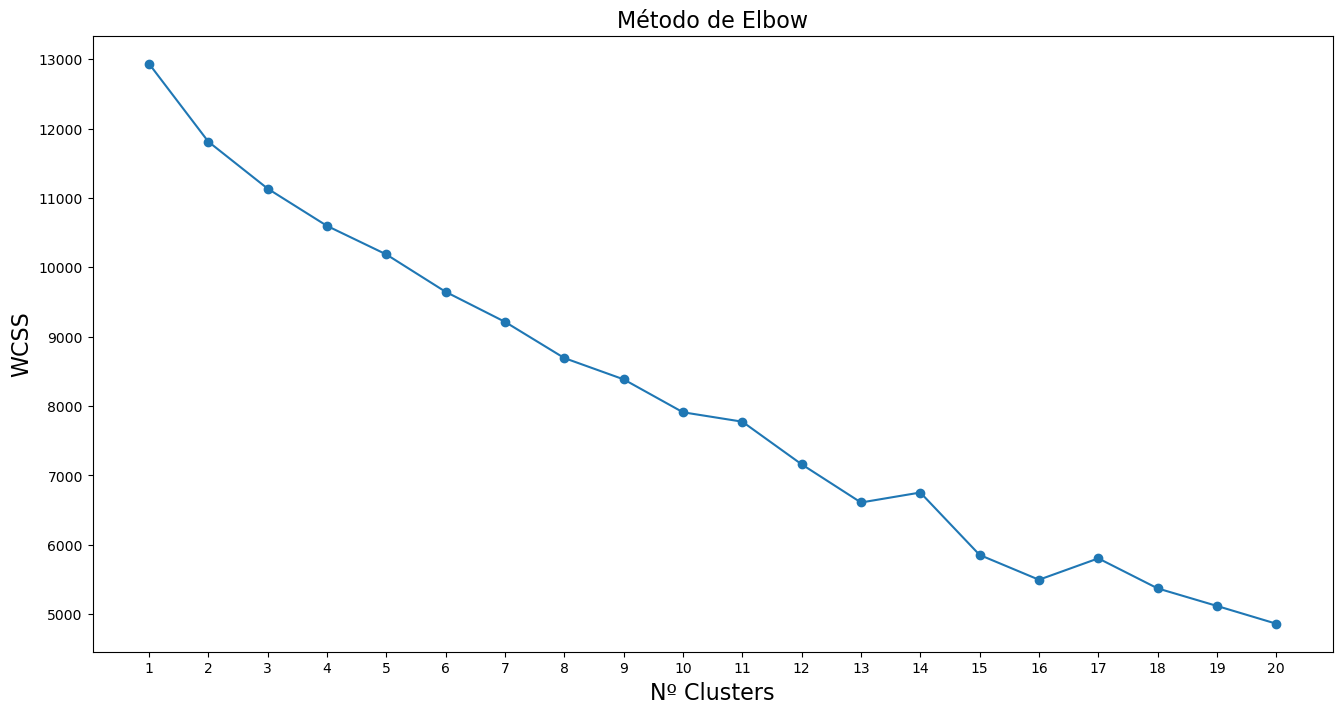

In [500]:
elbow = []
K = range(1,21) # ponto de parada pode ser parametrizado manualmente
for k in K:
    kmeanElbow = KMeans(n_clusters=k, init='random', random_state=100).fit(df_quanti_pad)
    elbow.append(kmeanElbow.inertia_)
    
plt.figure(figsize=(16,8))
plt.plot(K, elbow, marker='o')
plt.xlabel('Nº Clusters', fontsize=16)
plt.xticks(K) # ajustar range
plt.ylabel('WCSS', fontsize=16)
plt.title('Método de Elbow', fontsize=16)
plt.show()


Queda do WCSS de 1 para 2 clusters: 5991.91
Queda do WCSS de 2 para 3 clusters: 2051.20
Queda do WCSS de 3 para 4 clusters: 923.65
Queda do WCSS de 4 para 5 clusters: 550.54
Queda do WCSS de 5 para 6 clusters: 432.92
Queda do WCSS de 6 para 7 clusters: 508.43
Queda do WCSS de 7 para 8 clusters: 562.69
Queda do WCSS de 8 para 9 clusters: 591.47
Queda do WCSS de 9 para 10 clusters: 327.50
Queda do WCSS de 10 para 11 clusters: -2.75
Queda do WCSS de 11 para 12 clusters: 719.83
Queda do WCSS de 12 para 13 clusters: 321.36
Queda do WCSS de 13 para 14 clusters: 461.41
Queda do WCSS de 14 para 15 clusters: 224.24
Queda do WCSS de 15 para 16 clusters: 219.58
Queda do WCSS de 16 para 17 clusters: 75.10
Queda do WCSS de 17 para 18 clusters: 83.22
Queda do WCSS de 18 para 19 clusters: 653.75
Queda do WCSS de 19 para 20 clusters: 248.04
Queda do WCSS de 20 para 21 clusters: -79.77
Queda do WCSS de 21 para 22 clusters: 195.15
Queda do WCSS de 22 para 23 clusters: 257.70
Queda do WCSS de 23 para 24 

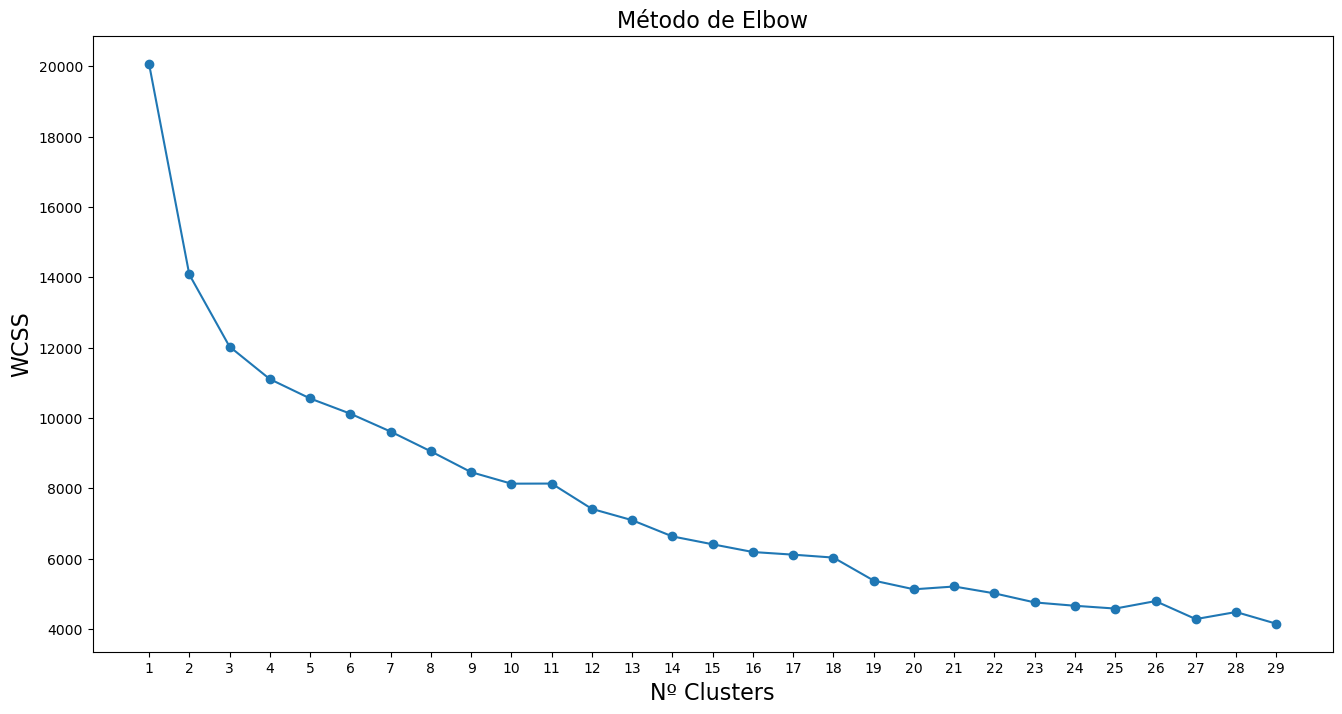

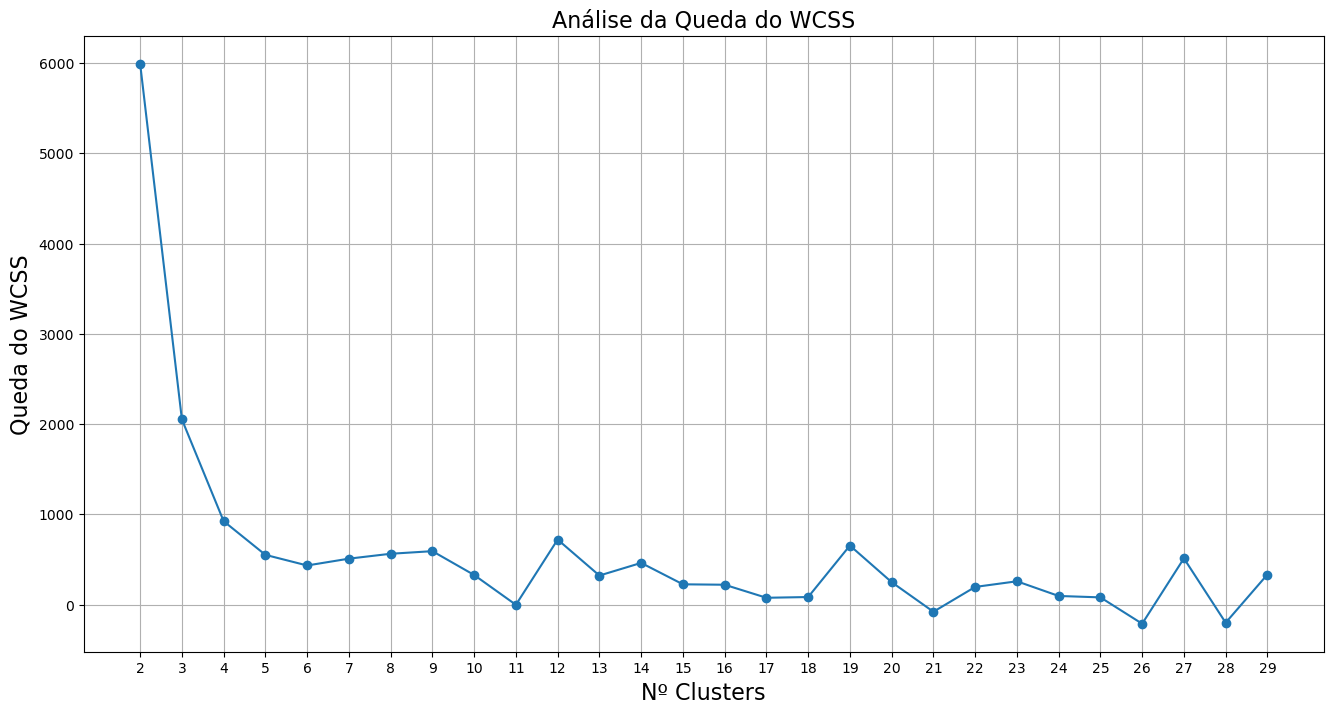

In [520]:
elbow = []
cauda_wcss = [] # Lista para armazenar a queda de WCSS

K = range(1,30)
for k in K:
    kmeanElbow = KMeans(n_clusters=k, init='random', random_state=100, n_init='auto').fit(df_quanti_pad)
    elbow.append(kmeanElbow.inertia_)
    
    # Calcular a queda do WCSS
    if k > 1:
        queda = elbow[k-2] - elbow[k-1]
        cauda_wcss.append(queda)
        print(f"Queda do WCSS de {k-1} para {k} clusters: {queda:.2f}")

# ---
# Plotagem do método de Elbow
plt.figure(figsize=(16,8))
plt.plot(K, elbow, marker='o')
plt.xlabel('Nº Clusters', fontsize=16)
plt.xticks(K)
plt.ylabel('WCSS', fontsize=16)
plt.title('Método de Elbow', fontsize=16)
plt.show()

# Opcional: Plotar a queda do WCSS
plt.figure(figsize=(16,8))
plt.plot(K[1:], cauda_wcss, marker='o')
plt.xlabel('Nº Clusters', fontsize=16)
plt.xticks(K[1:])
plt.ylabel('Queda do WCSS', fontsize=16)
plt.title('Análise da Queda do WCSS', fontsize=16)
plt.grid(True)
plt.show()

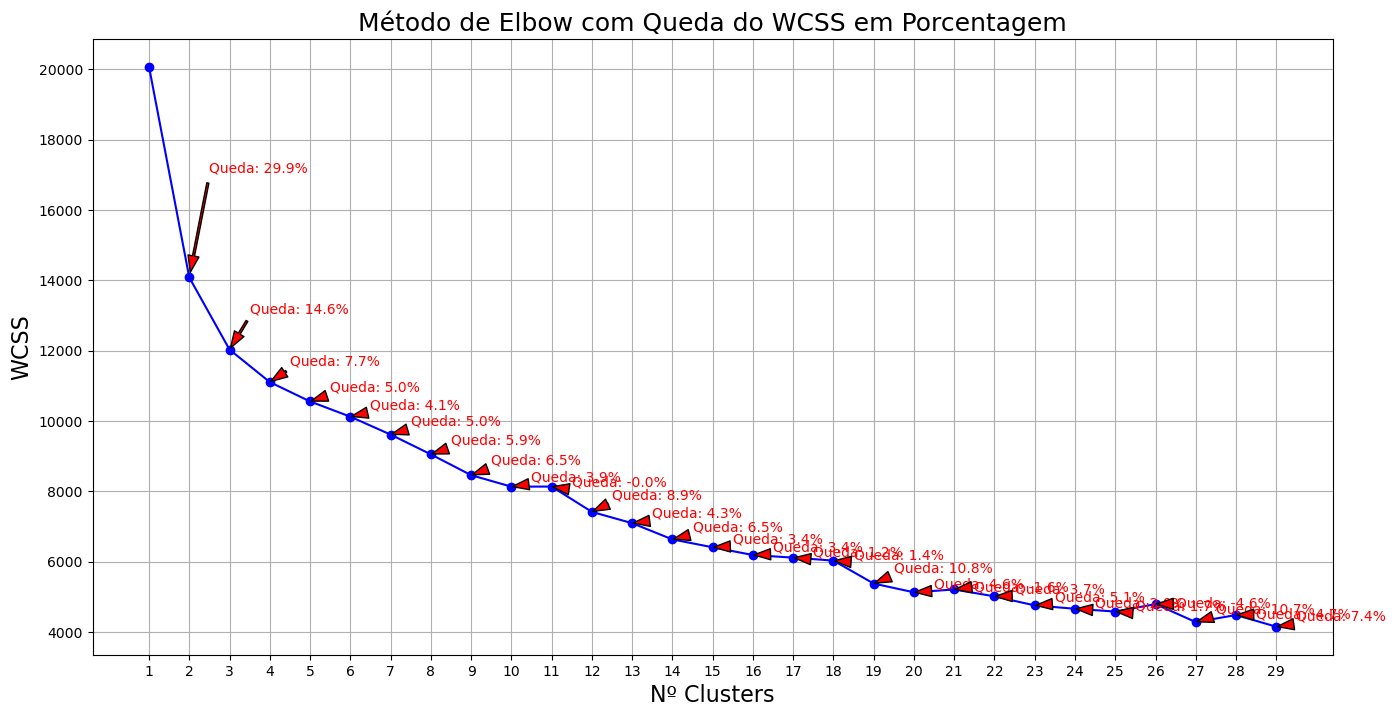

In [521]:
# ---
elbow = []
K = range(1, 30)

for k in K:
    kmeanElbow = KMeans(n_clusters=k, init='random', random_state=100, n_init='auto').fit(df_quanti_pad)
    elbow.append(kmeanElbow.inertia_)

# ---
# Plotagem do método de Elbow com anotações de queda em porcentagem
plt.figure(figsize=(16, 8))
plt.plot(K, elbow, marker='o', linestyle='-', color='b')
plt.xlabel('Nº Clusters', fontsize=16)
plt.xticks(K)
plt.ylabel('WCSS', fontsize=16)
plt.title('Método de Elbow com Queda do WCSS em Porcentagem', fontsize=18)
plt.grid(True)

# Adicionar as anotações de queda em porcentagem
for i in range(1, len(elbow)):
    # Calcular a queda absoluta
    queda_absoluta = elbow[i-1] - elbow[i]
    # Calcular a queda em porcentagem
    queda_porcentagem = (queda_absoluta / elbow[i-1]) * 100
    
    # Posição da anotação
    x_pos = K[i]
    y_pos = elbow[i] + (elbow[i-1] - elbow[i]) / 2
    
    # Texto da anotação
    texto_anotacao = f"Queda: {queda_porcentagem:.1f}%"
    
    # Adicionar a anotação com uma seta
    plt.annotate(
        texto_anotacao, 
        xy=(K[i], elbow[i]), 
        xytext=(x_pos + 0.5, y_pos),
        arrowprops=dict(facecolor='red', shrink=0.05, width=1.5, headwidth=8),
        fontsize=10,
        color='red'
    )

plt.show()

In [594]:
# %% Cluster K-means

# Vamos considerar 5 clusters, dadas as evidências anteriores!
kmeans_final = KMeans(n_clusters = 6, init = 'random', random_state=100).fit(df_quanti_pad)

# Gerando a variável para identificarmos os clusters gerados
kmeans_clusters = kmeans_final.labels_
df_quanti_preliminar['Cluster'] = kmeans_clusters
df_quanti_pad['Cluster'] = kmeans_clusters
df_quanti_preliminar['Cluster'] = df_quanti_preliminar['Cluster'].astype('category')
df_quanti_pad['Cluster'] = df_quanti_pad['Cluster'].astype('category')
df_quanti_pad.head()

nome_var_categoria_espec,vl_alimentacao,vl_assinaturas,vl_comb_aeronaves,vl_comb_autom,vl_comb_embarc,vl_comb_semespec,vl_cursos_eventos,vl_divulg_ativ,vl_hospedagem,vl_locfret_aeronave,...,vl_manut_escritorio,vl_pass_aerea_reembolso,vl_pass_aerea_rpa,vl_pass_aerea_sigepa,vl_pass_ter_mar_flu,vl_servseguranca,vl_taxi_ped_estac,vl_telefonia,vl_tokens,Cluster
0,-0.404414,-0.224378,-0.167271,0.437578,-0.085608,-0.054999,-0.108071,-0.902637,2.729416,0.327403,...,-0.793256,4.093747,-0.241755,-0.005697,-0.20204,-0.198506,-0.445254,-0.203310,-0.073528,1
1,-0.404414,-0.224378,-0.167271,0.157034,1.445638,-0.054999,-0.108071,-0.912605,0.000992,-0.144677,...,0.550069,-0.314815,-0.241755,-0.205136,-0.20204,-0.198506,-0.445254,-0.710156,-0.073528,1
2,-0.404414,-0.224378,-0.167271,0.904692,-0.085608,-0.054999,-0.108071,0.697118,-0.617373,-0.144677,...,-0.862895,2.664754,-0.241755,1.909938,-0.20204,-0.198506,-0.445254,0.324898,-0.073528,2
3,-0.404414,-0.224378,-0.167271,-0.350504,21.768297,-0.054999,-0.108071,1.982759,-0.617373,1.208620,...,-0.971579,-0.314815,-0.241755,-0.143891,-0.20204,-0.198506,-0.445254,-0.582349,-0.073528,0
4,1.424251,-0.224378,-0.167271,0.850098,-0.085608,-0.054999,-0.108071,0.072876,0.162768,-0.144677,...,0.185015,0.110199,2.328003,-0.329352,-0.20204,-0.198506,2.717531,-0.362724,0.270091,5


In [595]:
df_quanti_pad.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 22 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   vl_alimentacao           617 non-null    float64 
 1   vl_assinaturas           617 non-null    float64 
 2   vl_comb_aeronaves        617 non-null    float64 
 3   vl_comb_autom            617 non-null    float64 
 4   vl_comb_embarc           617 non-null    float64 
 5   vl_comb_semespec         617 non-null    float64 
 6   vl_cursos_eventos        617 non-null    float64 
 7   vl_divulg_ativ           617 non-null    float64 
 8   vl_hospedagem            617 non-null    float64 
 9   vl_locfret_aeronave      617 non-null    float64 
 10  vl_locfret_autom         617 non-null    float64 
 11  vl_locfret_embarc        617 non-null    float64 
 12  vl_manut_escritorio      617 non-null    float64 
 13  vl_pass_aerea_reembolso  617 non-null    float64 
 14  vl_pass_ae

In [596]:
# ANOVA
# Analisando se as duas variáveis são significativas para a clusterização 
import pingouin as pg

# 1) vl_alimentacao 
pg.anova(dv='vl_alimentacao', 
         between='Cluster', 
         data=df_quanti_pad,
         detailed=True).T



,0,1
Source,Cluster,Within
SS,42.967914,573.032086
DF,5,611
MS,8.593583,0.937859
F,9.162976,NaN
p-unc,0.0,NaN
np2,0.069753,NaN


ambos as variaveis p-valor é zero, menor que meu nivel de significacna. auxilia na formaçao de pelo menos 1 dos clusters.
é uma variavel singificativamente importnate em termos estatisticos para formaçao de pel menos 1 dos clusters. Esles sestao representando a clusterizaçao.
(e a var F)?


In [597]:
# 2) vl_assinaturas
pg.anova(dv='vl_assinaturas', 
         between='Cluster', 
         data=df_quanti_pad,
         detailed=True).T


,0,1
Source,Cluster,Within
SS,179.299385,436.700615
DF,5,611
MS,35.859877,0.714731
F,50.172553,NaN
p-unc,0.0,NaN
np2,0.29107,NaN


In [598]:
# 3) vl_comb_aeronaves
pg.anova(dv='vl_comb_aeronaves',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

,0,1
Source,Cluster,Within
SS,412.68583,203.31417
DF,5,611
MS,82.537166,0.332756
F,248.040796,NaN
p-unc,0.0,NaN
np2,0.669945,NaN


In [599]:
# 4) vl_comb_autom
pg.anova(dv='vl_comb_autom',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

,0,1
Source,Cluster,Within
SS,236.223279,379.776721
DF,5,611
MS,47.244656,0.621566
F,76.009095,NaN
p-unc,0.0,NaN
np2,0.383479,NaN


In [600]:
# 5) vl_comb_embarc
pg.anova(dv='vl_comb_embarc',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T


,0,1
Source,Cluster,Within
SS,132.456118,483.543882
DF,5,611
MS,26.491224,0.791398
F,33.473979,NaN
p-unc,0.0,NaN
np2,0.215026,NaN


In [601]:
# 6) vl_comb_semespec
pg.anova(dv='vl_comb_semespec',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

,0,1
Source,Cluster,Within
SS,54.422959,561.577041
DF,5,611
MS,10.884592,0.919111
F,11.842517,NaN
p-unc,0.0,NaN
np2,0.088349,NaN


In [602]:
# 7) vl_cursos_eventos
pg.anova(dv='vl_cursos_eventos',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 8) vl_divulg_ativ
pg.anova(dv='vl_divulg_ativ',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 9) vl_hospedagem
pg.anova(dv='vl_hospedagem',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 10) vl_locfret_aeronave
pg.anova(dv='vl_locfret_aeronave',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 11) vl_locfret_autom
pg.anova(dv='vl_locfret_autom',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 12) vl_locfret_embarc
pg.anova(dv='vl_locfret_embarc',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 13) vl_manut_escritorio
pg.anova(dv='vl_manut_escritorio',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 14) vl_pass_aerea_reembolso
pg.anova(dv='vl_pass_aerea_reembolso',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 15) vl_pass_aerea_rpa
pg.anova(dv='vl_pass_aerea_rpa',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 16) vl_pass_aerea_sigepa
pg.anova(dv='vl_pass_aerea_sigepa',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 17) vl_pass_ter_mar_flu
pg.anova(dv='vl_pass_ter_mar_flu',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 18) vl_servseguranca
pg.anova(dv='vl_servseguranca',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 19) vl_taxi_ped_estac
pg.anova(dv='vl_taxi_ped_estac',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 20) vl_telefonia
pg.anova(dv='vl_telefonia',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

# 21) vl_tokens
pg.anova(dv='vl_tokens',
         between='Cluster',
         data=df_quanti_pad,
         detailed=True).T

,0,1
Source,Cluster,Within
SS,122.8328,493.1672
DF,5,611
MS,24.56656,0.807148
F,30.436266,NaN
p-unc,0.0,NaN
np2,0.199404,NaN


In [603]:
type(colunas_quantitativas)

list

In [604]:
colunas_quantitativas

['vl_alimentacao',
 'vl_assinaturas',
 'vl_comb_aeronaves',
 'vl_comb_autom',
 'vl_comb_embarc',
 'vl_comb_semespec',
 'vl_cursos_eventos',
 'vl_divulg_ativ',
 'vl_hospedagem',
 'vl_locfret_aeronave',
 'vl_locfret_autom',
 'vl_locfret_embarc',
 'vl_manut_escritorio',
 'vl_pass_aerea_reembolso',
 'vl_pass_aerea_rpa',
 'vl_pass_aerea_sigepa',
 'vl_pass_ter_mar_flu',
 'vl_servseguranca',
 'vl_taxi_ped_estac',
 'vl_telefonia',
 'vl_tokens']

In [605]:
#1. Lista de variaveis da ANOVA
variaveis_anova = colunas_quantitativas.copy().remove('vl_serv_postais')


ValueError: list.remove(x): x not in list

In [ ]:
variaveis_anova

In [ ]:
# 2. Crie uma lista vazia para armazenar os resultados
resultados_anova = []

In [606]:
df_quanti_pad

nome_var_categoria_espec,vl_alimentacao,vl_assinaturas,vl_comb_aeronaves,vl_comb_autom,vl_comb_embarc,vl_comb_semespec,vl_cursos_eventos,vl_divulg_ativ,vl_hospedagem,vl_locfret_aeronave,...,vl_manut_escritorio,vl_pass_aerea_reembolso,vl_pass_aerea_rpa,vl_pass_aerea_sigepa,vl_pass_ter_mar_flu,vl_servseguranca,vl_taxi_ped_estac,vl_telefonia,vl_tokens,Cluster
0,-0.404414,-0.224378,-0.167271,0.437578,-0.085608,-0.054999,-0.108071,-0.902637,2.729416,0.327403,...,-0.793256,4.093747,-0.241755,-0.005697,-0.20204,-0.198506,-0.445254,-0.203310,-0.073528,1
1,-0.404414,-0.224378,-0.167271,0.157034,1.445638,-0.054999,-0.108071,-0.912605,0.000992,-0.144677,...,0.550069,-0.314815,-0.241755,-0.205136,-0.20204,-0.198506,-0.445254,-0.710156,-0.073528,1
2,-0.404414,-0.224378,-0.167271,0.904692,-0.085608,-0.054999,-0.108071,0.697118,-0.617373,-0.144677,...,-0.862895,2.664754,-0.241755,1.909938,-0.20204,-0.198506,-0.445254,0.324898,-0.073528,2
3,-0.404414,-0.224378,-0.167271,-0.350504,21.768297,-0.054999,-0.108071,1.982759,-0.617373,1.208620,...,-0.971579,-0.314815,-0.241755,-0.143891,-0.20204,-0.198506,-0.445254,-0.582349,-0.073528,0
4,1.424251,-0.224378,-0.167271,0.850098,-0.085608,-0.054999,-0.108071,0.072876,0.162768,-0.144677,...,0.185015,0.110199,2.328003,-0.329352,-0.20204,-0.198506,2.717531,-0.362724,0.270091,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
612,0.447528,-0.224378,3.504063,-0.065522,3.014243,-0.054999,-0.108071,0.693925,0.152443,-0.144677,...,0.077540,-0.314815,-0.241755,-0.406733,-0.20204,-0.198506,-0.445254,1.095851,-0.073528,0
613,0.895488,-0.224378,-0.167271,1.223858,-0.085608,-0.054999,-0.108071,-0.450065,0.026141,-0.144677,...,3.236958,-0.314815,-0.241755,-0.217230,-0.20204,0.481543,0.673778,0.356427,-0.073528,1
614,-0.404414,-0.224378,-0.167271,0.605868,-0.085608,-0.054999,-0.108071,2.145366,-0.471670,-0.144677,...,-0.951693,-0.314815,0.125297,-0.530689,-0.20204,-0.198506,-0.300686,-0.772602,-0.073528,2
615,-0.404414,-0.224378,-0.167271,-1.230194,-0.085608,-0.054999,-0.108071,-0.760997,-0.617373,12.249007,...,-0.897722,6.966672,14.623689,-0.709414,-0.20204,-0.198506,-0.445254,2.976779,-0.073528,3


In [607]:
variaveis_anova = [
    'vl_alimentacao',
    'vl_assinaturas',
    'vl_comb_aeronaves',
    'vl_comb_autom',
    'vl_comb_embarc',
    'vl_comb_semespec',
    'vl_cursos_eventos',
    'vl_divulg_ativ',
    'vl_hospedagem',
    'vl_locfret_aeronave',
    'vl_locfret_autom',
    'vl_locfret_embarc',
    'vl_manut_escritorio',
    'vl_pass_aerea_reembolso',
    'vl_pass_aerea_rpa',
    'vl_pass_aerea_sigepa',
    'vl_pass_ter_mar_flu',
    'vl_servseguranca',
    'vl_taxi_ped_estac',
    'vl_telefonia',
    'vl_tokens'
]

# 2. Crie uma lista vazia para armazenar os resultados
resultados_anova = []

# 3. Itere sobre a lista de variáveis e rode a ANOVA para cada uma
for var in variaveis_anova:
    # Execute a ANOVA
    anova_result = pg.anova(dv=var, between='Cluster', data=df_quanti_pad, detailed=True)
    
    # Selecione apenas a linha onde 'Source' é 'Cluster'
    cluster_row = anova_result.loc[anova_result['Source'] == 'Cluster']
    
    # Extraia os valores de 'F' e 'p-unc'
    f_value = cluster_row['F'].iloc[0]
    p_unc_value = cluster_row['p-unc'].iloc[0]
    
    # Crie um dicionário com os resultados e adicione o nome da variável
    resultado = {
        'Variavel': var,
        'F': f_value,
        'p-unc': p_unc_value
    }
    
    # Adicione o dicionário à lista de resultados
    resultados_anova.append(resultado)


# 4. Concatene a lista de dicionários em um único DataFrame

df_anova_final = pd.DataFrame(resultados_anova)
df_anova_final['p-unc'] = df_anova_final['p-unc'].round(2)

In [608]:
df_anova_final 

,Variavel,F,p-unc
0,vl_alimentacao,9.162976,0.00
1,vl_assinaturas,50.172553,0.00
2,vl_comb_aeronaves,248.040796,0.00
3,vl_comb_autom,76.009095,0.00
4,vl_comb_embarc,33.473979,0.00
5,vl_comb_semespec,11.842517,0.00
6,vl_cursos_eventos,1.048498,0.39
7,vl_divulg_ativ,135.442252,0.00
8,vl_hospedagem,13.367651,0.00
9,vl_locfret_aeronave,152.871523,0.00


### 3.2 ANÁLISE de Correspondencia Multipla - variaveis qualitativas
ACM 
Análise de correspondencia multipla nas variaveis categoricas, incluindo ao qual  obsevacao pertence.
Agoa fazemos análise correspondencia


Obs.:A Análise de Correspondência Múltipla (ACM) é uma técnica estatística usada para analisar relações entre variáveis categóricas, enquanto a Análise de Correspondência (ANACOR ou ACS) é utilizada para duas variáveis. 


Para manter  as variaveis numa analise de correspondencia multipla, elas precisam apresentar associaçao estisticamentee significativa com epelo menos uma outra variavel da analise.
Vamos fazer combinaçoes para teste chi 2 de associaçao.
Pode aplicar atalho.. em que elege uma variavel, que se julgue a priori como importante,  e realiza  calculo todas tabelas de contignecia e fa;ço os testes chi 2 em relaçao a ela.
Se todas passarem , todas vao para canalise de correspondecia multipla.
se ela nao apssar, faço teste com outras vari[aveis



In [609]:
df_quanti_preliminar.head()

nome_var_categoria_espec,txNomeParlamentar,sgUF,sgPartido,flag_reeleito,flag_lid,vl_alimentacao,vl_assinaturas,vl_comb_aeronaves,vl_comb_autom,vl_comb_embarc,...,vl_pass_aerea_reembolso,vl_pass_aerea_rpa,vl_pass_aerea_sigepa,vl_pass_ter_mar_flu,vl_serv_postais,vl_servseguranca,vl_taxi_ped_estac,vl_telefonia,vl_tokens,Cluster
0,AJ Albuquerque,CE,PP,Sim,0,0.00,0.0,0.0,61492.81,0.00,...,29291.60,0.00,81187.11,0.0,0.0,0.0,0.00,4532.09,0.0,1
1,Abilio Brunini,MT,PL,Nao,0,0.00,0.0,0.0,51148.78,780.80,...,0.00,0.00,68795.75,0.0,0.0,0.0,0.00,569.33,0.0,1
2,Acácio Favacho,AP,MDB,Sim,0,0.00,0.0,0.0,78715.85,0.00,...,19797.01,0.00,200208.03,0.0,0.0,0.0,0.00,8661.87,0.0,2
3,Adail Filho,AM,REPUBLICANOS,Nao,0,0.00,0.0,0.0,32435.25,11143.56,...,0.00,0.00,72600.96,0.0,0.0,0.0,0.00,1568.59,0.0,0
4,Adilson Barroso,SP,PL,Nao,0,6474.82,0.0,0.0,76702.90,0.00,...,2823.90,20040.21,61078.03,0.0,0.0,0.0,16908.15,3285.72,120.0,5


In [610]:
df_quanti_preliminar.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 617 entries, 0 to 616
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   txNomeParlamentar        617 non-null    object  
 1   sgUF                     617 non-null    object  
 2   sgPartido                617 non-null    object  
 3   flag_reeleito            617 non-null    object  
 4   flag_lid                 617 non-null    int32   
 5   vl_alimentacao           617 non-null    float64 
 6   vl_assinaturas           617 non-null    float64 
 7   vl_comb_aeronaves        617 non-null    float64 
 8   vl_comb_autom            617 non-null    float64 
 9   vl_comb_embarc           617 non-null    float64 
 10  vl_comb_semespec         617 non-null    float64 
 11  vl_cursos_eventos        617 non-null    float64 
 12  vl_divulg_ativ           617 non-null    float64 
 13  vl_hospedagem            617 non-null    float64 
 14  vl_locfret

In [611]:
df_quali = df_quanti_preliminar[['sgPartido', 'sgUF', 'flag_reeleito','flag_lid','Cluster']]

In [612]:
df_quali.head() 

nome_var_categoria_espec,sgPartido,sgUF,flag_reeleito,flag_lid,Cluster
0,PP,CE,Sim,0,1
1,PL,MT,Nao,0,1
2,MDB,AP,Sim,0,2
3,REPUBLICANOS,AM,Nao,0,0
4,PL,SP,Nao,0,5


In [631]:
#Estatísticas descritivas univariadas

# Tabelas de frequências por variável
print(df_quali.sgPartido.value_counts())
print(df_quali.sgUF.value_counts())
print(df_quali.flag_reeleito.value_counts())
print(df_quali.flag_lid.value_counts())
print(df_quali.Cluster.value_counts())

sgPartido
PL               106
PT                76
UNIÃO             72
PSD               61
PP                60
REPUBLICANOS      58
MDB               51
PDT               22
PODE              19
PSB               16
PSDB              15
PSOL              13
PCdoB              9
AVANTE             8
SOLIDARIEDADE      7
PRD                6
NOVO               5
CIDADANIA          5
PV                 4
REDE               2
S.PART.            1
PATRIOTA           1
Name: count, dtype: int64
sgUF
SP    84
MG    60
RJ    57
BA    42
PR    40
RS    34
MA    32
CE    29
PE    27
SC    21
PA    19
GO    19
PB    15
MT    13
SE    12
AC    11
TO    11
AM    10
ES    10
PI    10
RN     9
AL     9
RR     9
DF     9
AP     9
MS     8
RO     8
Name: count, dtype: int64
flag_reeleito
Nao    323
Sim    294
Name: count, dtype: int64
flag_lid
0    617
Name: count, dtype: int64
Cluster
1    294
2    135
4    126
5     42
0     11
3      9
Name: count, dtype: int64


In [632]:
# Teste de qui-quadrado para pares de variáveis
# A variável de referência agora é 'Cluster

# 1. Teste 'Cluster' vs 'sgPartido'
tabela1 = chi2_contingency(pd.crosstab(df_quali["Cluster"],
                                       df_quali["sgPartido"]))
print(f"p-valor da estatística (Cluster x sgPartido): {round(tabela1[1], 4)}")

# 2. Teste 'Cluster' vs 'sgUF'
tabela2 = chi2_contingency(pd.crosstab(df_quali["Cluster"],
                                       df_quali["sgUF"]))
print(f"p-valor da estatística (Cluster x sgUF): {round(tabela2[1], 4)}")

# 3. Teste 'Cluster' vs 'flag_reeleito'
tabela3 = chi2_contingency(pd.crosstab(df_quali["Cluster"],
                                       df_quali["flag_reeleito"]))
print(f"p-valor da estatística (Cluster x flag_reeleito): {round(tabela3[1], 4)}")

# 4. Teste 'Cluster' vs 'flag_lid'
tabela4 = chi2_contingency(pd.crosstab(df_quali["Cluster"],
                                       df_quali["flag_lid"]))
print(f"p-valor da estatística (Cluster x flag_lid): {round(tabela4[1], 4)}")

p-valor da estatística (Cluster x sgPartido): 0.0414
p-valor da estatística (Cluster x sgUF): 0.0
p-valor da estatística (Cluster x flag_reeleito): 0.0
p-valor da estatística (Cluster x flag_lid): 1.0


In [633]:
# Elaborando a análise de correspondência múltipla
mca = prince.MCA(n_components=2).fit(df_quali)


In [634]:
#Analisando os resultados

# Análise dos autovalores
tabela_autovalores = mca.eigenvalues_summary
print(tabela_autovalores)

# Inércia total da análise
print(mca.total_inertia_)

# Plotar apenas dimensões com inércia parcial superior à inércia total média
quant_dim = mca.J_ - mca.K_
print(mca.total_inertia_/quant_dim)


          eigenvalue % of variance % of variance (cumulative)
component                                                    
0              0.351         3.31%                      3.31%
1              0.309         2.91%                      6.23%
10.60000000000008
0.2000000000000015


In [635]:
#Obtendo as coordenadas-padrão das categorias das variáveis

coord_padrao = mca.column_coordinates(df_quali)/np.sqrt(mca.eigenvalues_)
print(coord_padrao)

                                 0             1
sgPartido__AVANTE         3.522952  2.857012e+00
sgPartido__CIDADANIA      0.193403 -1.655972e+00
sgPartido__MDB           -1.501320  3.481364e-01
sgPartido__NOVO           1.234853 -3.555008e+00
sgPartido__PATRIOTA      -3.325874 -2.228041e+00
sgPartido__PCdoB          0.291464 -1.176189e-01
sgPartido__PDT           -0.571646 -1.794671e-01
sgPartido__PL            -0.076537 -7.580587e-01
sgPartido__PODE          -0.674013 -1.613587e+00
sgPartido__PP            -0.199018 -4.203961e-01
sgPartido__PRD            1.768482  3.179627e+00
sgPartido__PSB            1.133089 -1.310709e+00
sgPartido__PSD           -0.420439  1.025723e+00
sgPartido__PSDB           2.636520 -2.916737e-01
sgPartido__PSOL           1.127542 -2.981851e+00
sgPartido__PT             1.488482 -3.580082e-01
sgPartido__PV             1.283804  2.360592e+00
sgPartido__REDE           0.221388 -1.525995e+00
sgPartido__REPUBLICANOS  -0.308441  1.443049e+00
sgPartido__S.PART.  

In [636]:
## Plotando o mapa perceptual (coordenadas-padrão)

# Primeiro passo: gerar um DataFrame detalhado

chart = coord_padrao.reset_index()
var_chart = pd.Series(chart['index'].str.split('_', expand=True).iloc[:,0])

nome_categ=[]
for col in df_quali:
    nome_categ.append(df_quali[col].sort_values(ascending=True).unique())
    categorias = pd.DataFrame(nome_categ).stack().reset_index()

chart_df_mca = pd.DataFrame({'categoria': chart['index'],
                             'obs_x': chart[0],
                             'obs_y': chart[1],
                             'obs_z': chart[2],
                             'variavel': var_chart,
                             'categoria_id': categorias[0]})

# Segundo passo: gerar o gráfico de pontos

fig = px.scatter_3d(chart_df_mca, 
                    x='obs_x', 
                    y='obs_y', 
                    z='obs_z',
                    color='variavel',
                    text=chart_df_mca.categoria_id)
fig.show()


KeyError: 2

In [616]:
# Teste de qui-quadrado para pares de variáveis
# A variável de referência agora é 'sgPartido'

# 1. Teste 'sgPartido' vs 'Cluster'
tabela1 = chi2_contingency(pd.crosstab(df_quali["sgPartido"],
                                       df_quali["Cluster"]))
print(f"p-valor da estatística (sgPartido x Cluster): {round(tabela1[1], 4)}")

# 2. Teste 'sgPartido' vs 'sgUF'
tabela2 = chi2_contingency(pd.crosstab(df_quali["sgPartido"],
                                       df_quali["sgUF"]))
print(f"p-valor da estatística (sgPartido x sgUF): {round(tabela2[1], 4)}")

# 3. Teste 'sgPartido' vs 'flag_reeleito'
tabela3 = chi2_contingency(pd.crosstab(df_quali["sgPartido"],
                                       df_quali["flag_reeleito"]))
print(f"p-valor da estatística (sgPartido x flag_reeleito): {round(tabela3[1], 4)}")

# 4. Teste 'sgPartido' vs 'flag_lid'
tabela4 = chi2_contingency(pd.crosstab(df_quali["sgPartido"],
                                       df_quali["flag_lid"]))
print(f"p-valor da estatística (sgPartido x flag_lid): {round(tabela4[1], 4)}")

p-valor da estatística (sgPartido x Cluster): 0.0414
p-valor da estatística (sgPartido x sgUF): 0.0
p-valor da estatística (sgPartido x flag_reeleito): 0.8339
p-valor da estatística (sgPartido x flag_lid): 1.0


# ---------------------------------------------------------------------------
# Daqui pra baixo: Em construçao
# Desconsiderar todos os códigos abaixo.

# ----------------------------
<div class="alert alert-block alert-info">
    ###   AVALIAÇAO DE ASSIDUIDADE DE PARLAMENTARES
</div>


## 3. Inclusao de dados de extras de CNPJ (TBD)

